# Pareto Frontier Analysis for Diversified QUBO Portfolio Optimization

This notebook explores the Pareto frontier by varying the risk aversion parameter in diversified (restricted) QUBO-based portfolio optimization on the wide dataset (680 assets).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time
import logging
import os
import warnings
from datetime import datetime, timedelta
from functools import partial
from pathlib import Path
from optimization_engines import (
    equal_weights_baseline,
    genetic_algorithm_qubo,
    scipy_slsqp_qubo,
    riskfolio_qubo,
    dwave_cqm_qubo,
    portfolio_stats
)
from analysis_utils import (
    write_pickle_dict,
    read_pickle_dict,
    plot_pareto_frontier,
    compare_pareto_frontiers,
    plot_weight_evolution,
    extract_pareto_frontier
)

SEED = 12
np.random.seed(SEED)
msg_level = logging.INFO
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
# Create a logger
logger = logging.getLogger("pareto_logger")
logger.setLevel(msg_level)

## Data Paths

In [3]:
benchmark_path = '../../data/benchmark_gspc.pkl'
source_path = '../../data/stocks_adjclose.pkl'
source_path_extended = '../../data/etfs_close.pkl'
results_base_path = '../../results/pareto_optimization/'

# Create results directory if it doesn't exist
os.makedirs(results_base_path, exist_ok=True)
print(f"Results will be saved to: {results_base_path}")

Results will be saved to: ../../results/pareto_optimization/


## Data Loading

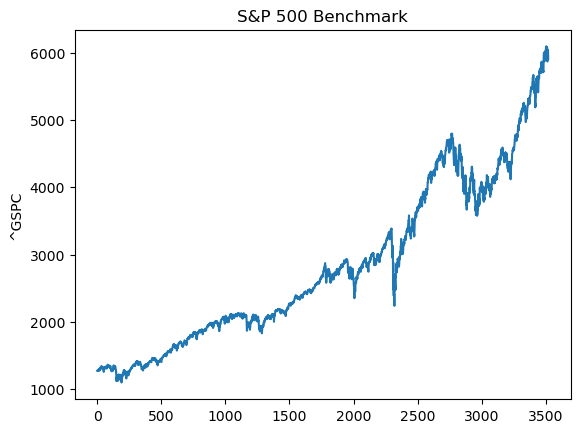

Ticker,ds,^GSPC
0,2011-01-03,1271.869995
1,2011-01-04,1270.199951
2,2011-01-05,1276.560059
3,2011-01-06,1273.849976
4,2011-01-07,1271.500000


In [4]:
benchmark = pd.read_pickle(benchmark_path)
sns.lineplot(benchmark['^GSPC'])
plt.title('S&P 500 Benchmark')
plt.show()
benchmark.head()

In [5]:
source_extended = pd.read_pickle(source_path_extended)
print(f"Extended data shape: {source_extended.shape}")
source_extended.head()

Extended data shape: (3521, 242)


Ticker,ds,AADR,ACWI,ACWX,AFG,AGG,AMLP,BIL,BIV,BND,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
0,2011-01-03,26.494179,35.018154,30.182961,14.173727,71.489235,26.573900,76.281036,50.488926,53.083935,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
1,2011-01-04,26.450108,34.981026,30.019852,14.104879,71.509521,26.491484,76.281036,50.562424,53.090553,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2,2011-01-05,26.291458,34.981026,29.992662,14.066156,71.164383,26.458506,76.281036,50.188774,52.858776,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
3,2011-01-06,26.291458,34.758274,29.727602,14.264087,71.177925,26.458506,76.281036,50.378658,52.905167,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
4,2011-01-07,26.150438,34.632030,29.578085,14.195246,71.408035,26.491484,76.264374,50.678814,53.103794,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


In [6]:
source = pd.read_pickle(source_path)
print(f"Source data shape: {source.shape}")
has_any_nan = source.isnull().values.any()
print(f"Any NaN in source: {has_any_nan}")

Source data shape: (3522, 439)
Any NaN in source: False


In [7]:
source_wide = pd.merge(source, source_extended, on='ds', how='left').set_index('ds').dropna()
print(f"Wide dataset shape: {source_wide.shape}")
has_any_nan = source_wide.isnull().values.any()
print(f"Any NaN in source_wide: {has_any_nan}")
source_wide.head()

Wide dataset shape: (3521, 680)
Any NaN in source_wide: False


Ticker,A,AAPL,ABT,ACGL,ACN,ADBE,ADI,ADM,ADP,ADSK,...,XLP,XLU,XLV,XLY,XME,XOP,XPH,XRT,XSD,XTNT
ds,,,,,,,,,,,,,,,,,,,,,
2011-01-03,26.781836,9.917951,16.942663,9.349445,37.585785,31.290001,27.436106,20.712511,29.848969,39.270000,...,19.910189,19.169912,24.896574,31.685013,57.138588,168.841461,17.785585,19.920353,25.601683,1074.0
2011-01-04,26.532440,9.969709,17.102097,9.291334,37.338249,31.510000,27.125227,20.698887,29.741137,38.529999,...,19.855919,19.261232,24.974888,31.509201,56.714920,167.352570,17.651617,19.548199,25.860556,1032.0
2011-01-05,26.474880,10.051261,17.102097,9.305071,37.346004,32.220001,27.183071,20.794275,30.216925,41.240002,...,19.862703,19.139469,25.029711,31.768719,57.097866,167.922791,17.774096,19.531855,26.151806,1050.0
2011-01-06,26.526041,10.043136,17.066668,9.179339,37.485237,32.270000,27.334898,21.591436,30.451658,41.259998,...,19.794865,19.157736,25.131519,31.576189,56.389015,167.099167,17.873608,19.253756,26.558626,1026.0
2011-01-07,26.615564,10.115060,17.137522,9.109608,37.547104,32.040001,27.175838,21.768579,30.521458,40.759998,...,19.693110,19.224695,25.115862,31.559439,56.112007,167.701004,17.892746,19.196499,26.697304,1050.0


## Parameters

In [8]:
parameters = {
    "n_periods": 10,  # Run 10 different time ranges
    "population_size": 100,
    "num_generations": 100,
    "mutation_rate": 0.1,
    "elitism": 0.1,
    "budget": 1_000_000,
    "days_to_avg": 30,  # 30-day averaging period
    "days_to_opt": 30,   # 30-day optimization/testing period
    # Risk levels for Pareto frontier exploration - lambda from 0 to 1 with steps of 0.1
    "risk_levels": [i/10 for i in range(11)]  # [0.0, 0.1, 0.2, ..., 1.0]
}

print(f"Optimization Parameters:")
for key, value in parameters.items():
    print(f"  {key}: {value}")

Optimization Parameters:
  n_periods: 10
  population_size: 100
  num_generations: 100
  mutation_rate: 0.1
  elitism: 0.1
  budget: 1000000
  days_to_avg: 30
  days_to_opt: 30
  risk_levels: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]


## Pareto Optimization Functions

In [9]:
def pareto_sweep(data, optimization_function, risk_levels, **opt_kwargs):
    """
    Perform Pareto frontier sweep by optimizing across multiple risk levels.
    
    Args:
        data: Stock price DataFrame
        optimization_function: Optimization function to use
        risk_levels: List of risk aversion parameters to explore
        **opt_kwargs: Additional arguments for optimization function
        
    Returns:
        results_dict: Dictionary mapping risk_level -> optimization results
    """
    results = {}
    
    for risk_level in risk_levels:
        print(f"\nOptimizing with risk_level = {risk_level:.3f}")
        start_time = time.time()
        
        try:
            # Optimize for this risk level
            weights = optimization_function(data, risk_level=risk_level, **opt_kwargs)
            
            # Calculate portfolio statistics
            port_return, port_vol = portfolio_stats(weights, data)
            
            # Store results
            results[risk_level] = {
                'weights': weights,
                'portfolio_return': port_return,
                'portfolio_risk': port_vol,
                'portfolio_variance': port_vol ** 2,
                'sharpe_ratio': port_return / port_vol if port_vol > 0 else 0,
                'execution_time': time.time() - start_time,
                'risk_level': risk_level
            }
            
            print(f"  Return: {port_return:.6f}, Risk: {port_vol:.6f}, "
                  f"Sharpe: {results[risk_level]['sharpe_ratio']:.4f}, "
                  f"Time: {results[risk_level]['execution_time']:.2f}s")
            
        except Exception as e:
            print(f"  ERROR: {str(e)}")
            results[risk_level] = None
    
    return results


def run_pareto_optimization_period(period, solver_name, solver_key, optimization_function, 
                                   data, benchmark, results_dict, parameters, 
                                   results_base_path, **opt_kwargs):
    """
    Run Pareto optimization for a single period and single solver.
    
    Args:
        period: Period index (0-9)
        solver_name: Display name of the solver (e.g., 'Genetic Algorithm', 'SciPy SLSQP')
        solver_key: Short key for file naming (e.g., 'ga', 'slsqp', 'riskfolio')
        optimization_function: The optimization function to use
        data: Full stock price DataFrame
        benchmark: Benchmark DataFrame
        results_dict: Dictionary to store results (will be modified in place)
        parameters: Dictionary of optimization parameters
        results_base_path: Base path for saving results
        **opt_kwargs: Additional arguments for optimization function
    """
    print(f"\n{'='*80}")
    print(f"PERIOD {period} - {solver_name} (Wide Dataset)")
    print(f"{'='*80}")
    
    results_path = results_base_path + f'pareto_wide_{solver_key}_period_{period}.pkl'
    
    if not os.path.exists(results_path):
        # Get period data
        df_avg, df_opt, df_b_avg, df_b_opt = get_period_data(
            data, benchmark, period,
            days_to_avg=parameters['days_to_avg'],
            days_to_opt=parameters['days_to_opt']
        )
        print(f"Averaging period: {df_avg.index[0]} to {df_avg.index[-1]}")
        print(f"Optimization period: {df_opt.index[0]} to {df_opt.index[-1]}")
        
        # Run Pareto sweep on averaging data with diversified QUBO
        results = pareto_sweep(
            df_avg,
            optimization_function,
            parameters['risk_levels'],
            **opt_kwargs
        )
        write_pickle_dict(results, results_path)
    else:
        print(f"Loading existing results for period {period}...")
        results = read_pickle_dict(results_path)
    
    results_dict[period] = results
    
    # Plot efficient frontier for this period
    plot_pareto_frontier(results, title=f"Efficient Frontier - {solver_name} Period {period} (Wide Dataset)")

In [10]:
def get_period_data(data, benchmark, period, days_to_avg=30, days_to_opt=30, seed=SEED):
    """
    Get data for a specific period using the same approach as other optimization notebooks.
    
    Args:
        data: Full stock price DataFrame
        benchmark: Benchmark DataFrame  
        period: Period index (0-9 for 10 periods)
        days_to_avg: Number of days to use for averaging (30)
        days_to_opt: Number of days to use for optimization/testing (30)
        seed: Random seed
        
    Returns:
        df_avg: Data for 30-day averaging period
        df_opt: Data for 30-day optimization period
        df_b_avg: Benchmark for averaging period
        df_b_opt: Benchmark for optimization period
    """
    df2 = data.reset_index()
    benchmark2 = benchmark.reset_index()
    
    # Sample 100 different starting dates deterministically
    np.random.seed(seed)
    max_samples = 100
    valid_range = range(days_to_avg, len(df2) - days_to_avg - days_to_opt)
    sample_indices = np.random.choice(valid_range, size=min(max_samples, len(valid_range)), replace=False)
    
    # Get the specific period
    if period >= len(sample_indices):
        raise ValueError(f"Period {period} exceeds available samples ({len(sample_indices)})")
    
    idx = sample_indices[period]
    
    # Averaging period (30 days before idx)
    df_avg = df2.iloc[idx - days_to_avg:idx, :].set_index('ds')
    df_b_avg = benchmark2.iloc[idx - days_to_avg:idx, :].set_index('ds').drop(['index'], axis=1, errors='ignore')
    
    # Optimization period (30 days after idx)
    df_opt = df2.iloc[idx:idx + days_to_opt, :].set_index('ds')
    df_b_opt = benchmark2.iloc[idx:idx + days_to_opt, :].set_index('ds').drop(['index'], axis=1, errors='ignore')
    
    return df_avg, df_opt, df_b_avg, df_b_opt

## Wide Dataset Pareto Frontier (680 Assets) - All Periods

In [11]:
# Initialize storage for all periods
all_periods_results_wide = {
    'genetic_algorithm': {},
    'scipy_slsqp': {},
    'riskfolio': {}
}

print(f"\nRunning Pareto optimization for Wide Dataset across {parameters['n_periods']} time periods...")
print("=" * 80)


Running Pareto optimization for Wide Dataset across 10 time periods...


### Genetic Algorithm - Wide Dataset (All Periods)


PERIOD 0 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 0...


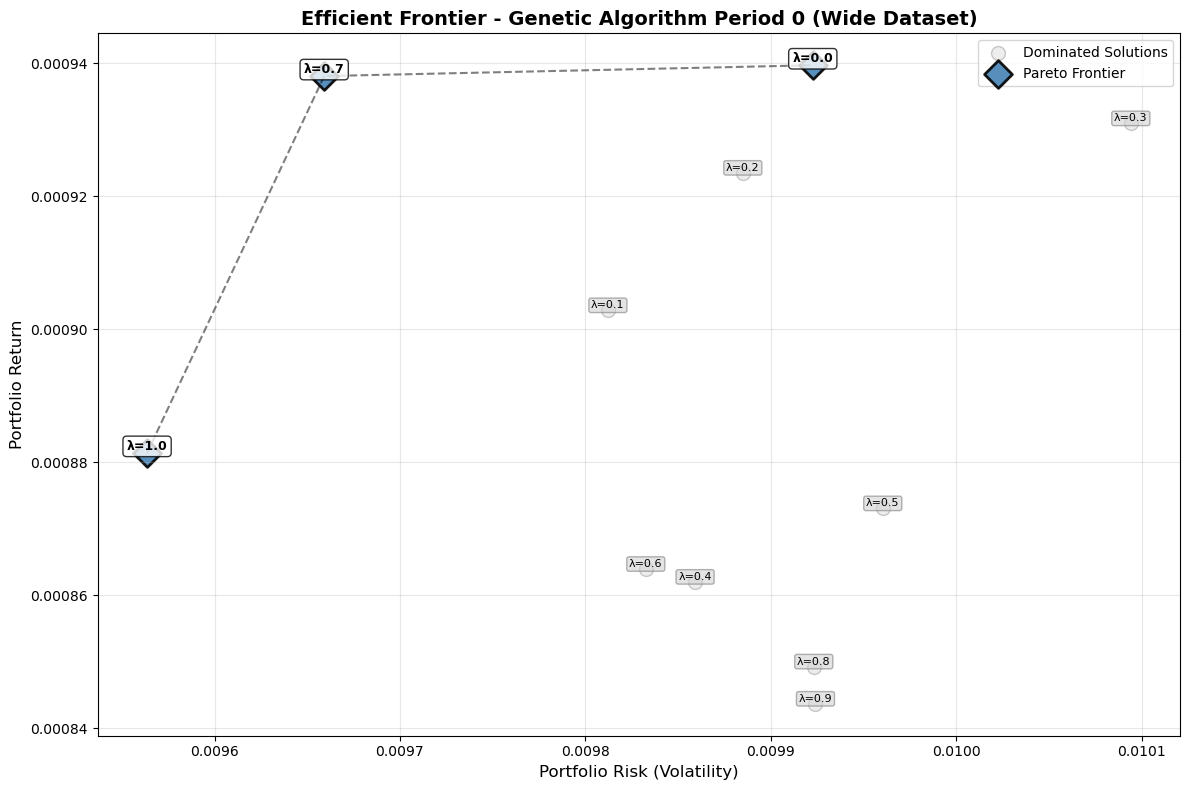


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 3
Efficiency: 27.3%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.000881     0.009564     0.0922      
0.700        0.000938     0.009659     0.0971      
0.000        0.000940     0.009923     0.0947      

PERIOD 1 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 1...


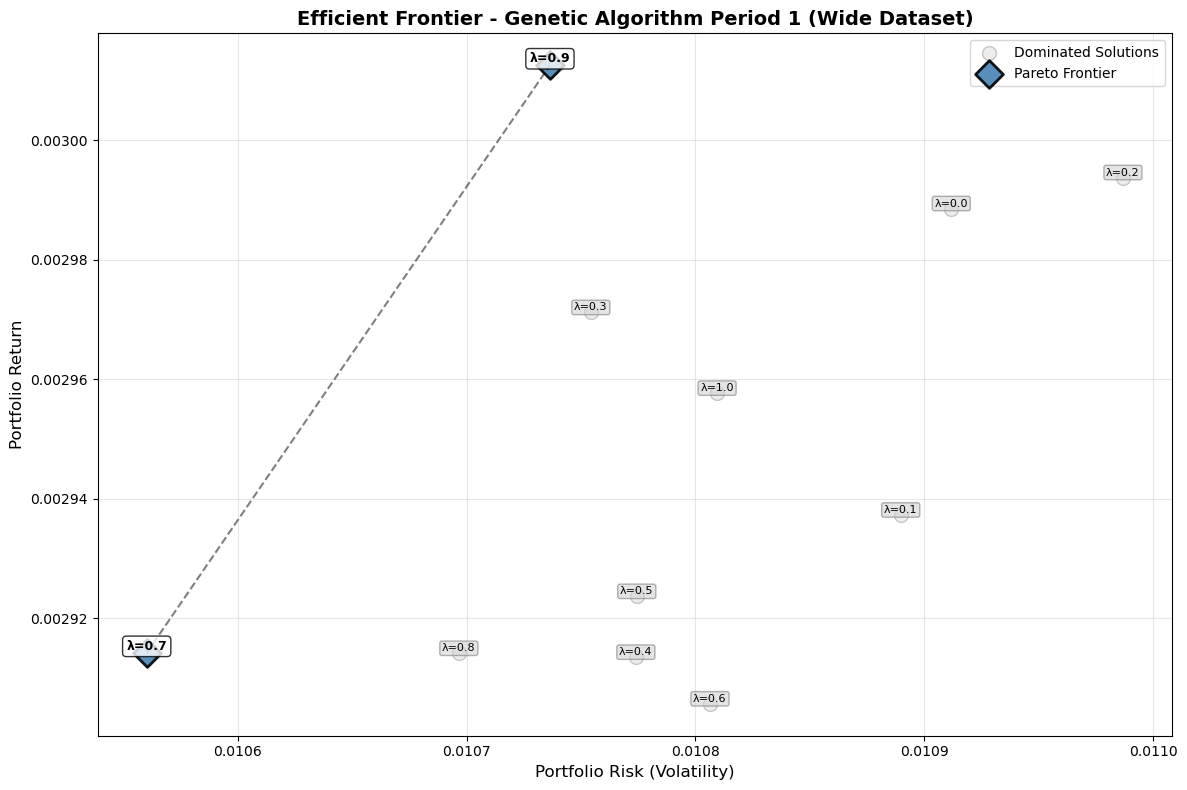


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 2
Efficiency: 18.2%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.700        0.002914     0.010560     0.2760      
0.900        0.003013     0.010736     0.2806      

PERIOD 2 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 2...


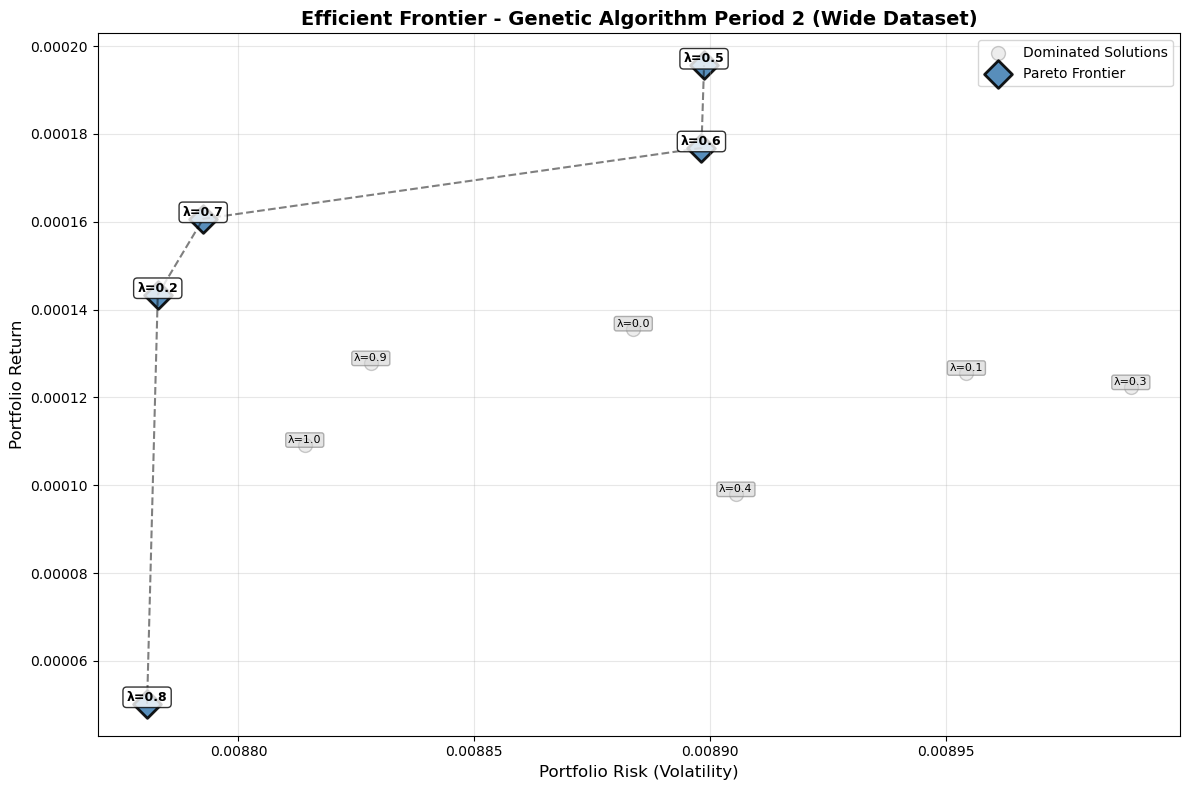


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 5
Efficiency: 45.5%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.800        0.000050     0.008781     0.0057      
0.200        0.000143     0.008783     0.0163      
0.700        0.000161     0.008793     0.0183      
0.600        0.000177     0.008898     0.0199      
0.500        0.000196     0.008899     0.0220      

PERIOD 3 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 3...


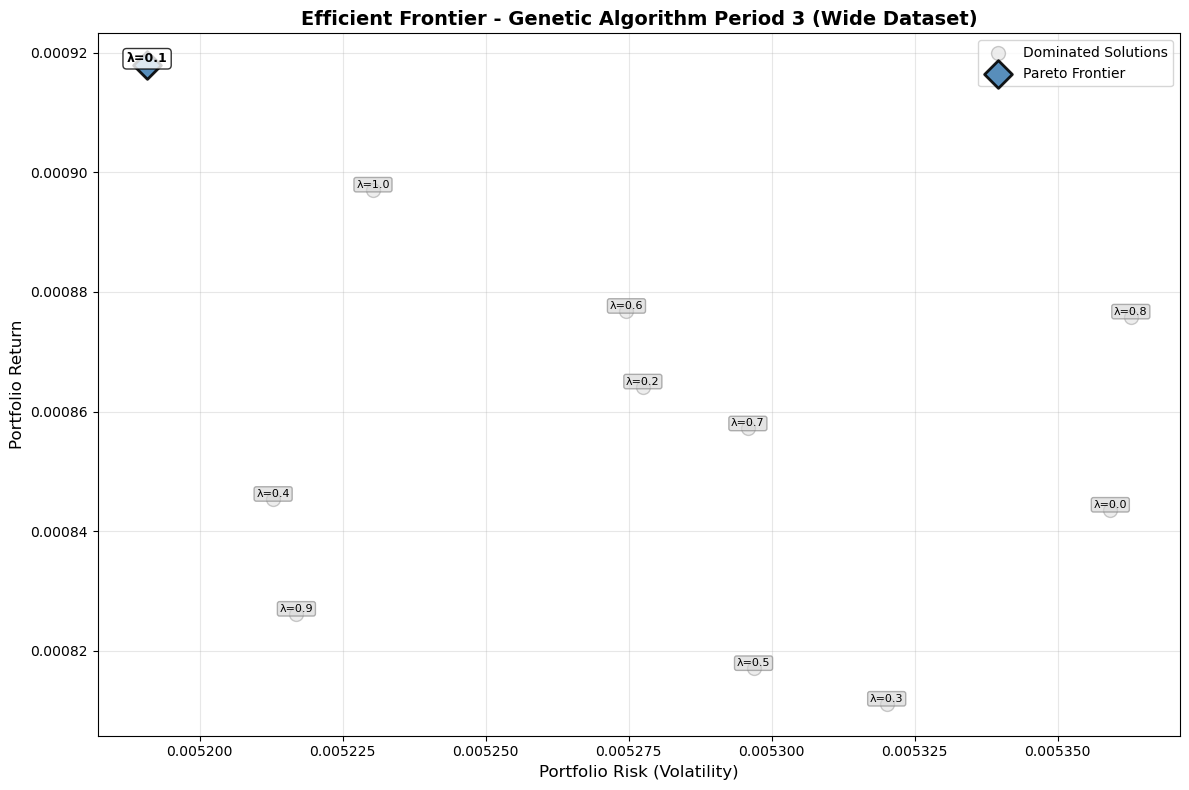


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 1
Efficiency: 9.1%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.100        0.000918     0.005191     0.1768      

PERIOD 4 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 4...


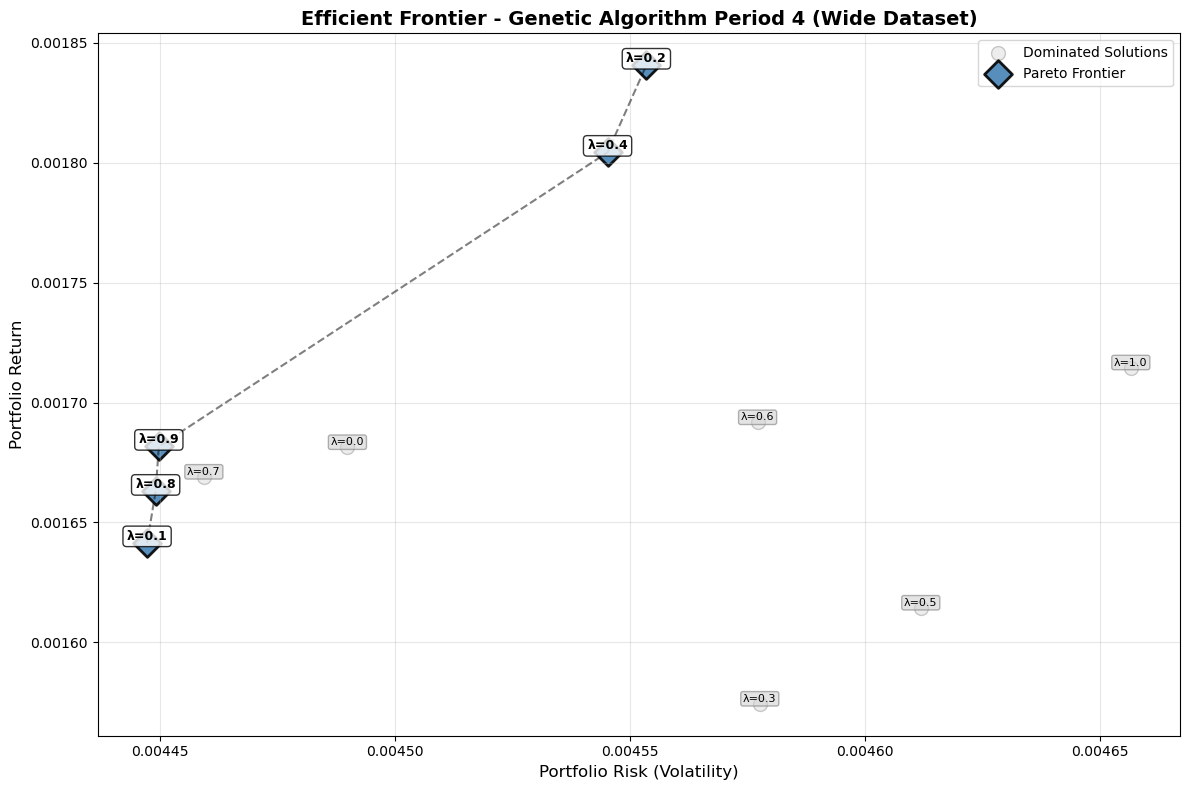


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 5
Efficiency: 45.5%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.100        0.001641     0.004447     0.3691      
0.800        0.001663     0.004449     0.3738      
0.900        0.001682     0.004450     0.3779      
0.400        0.001804     0.004545     0.3970      
0.200        0.001841     0.004553     0.4042      

PERIOD 5 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 5...


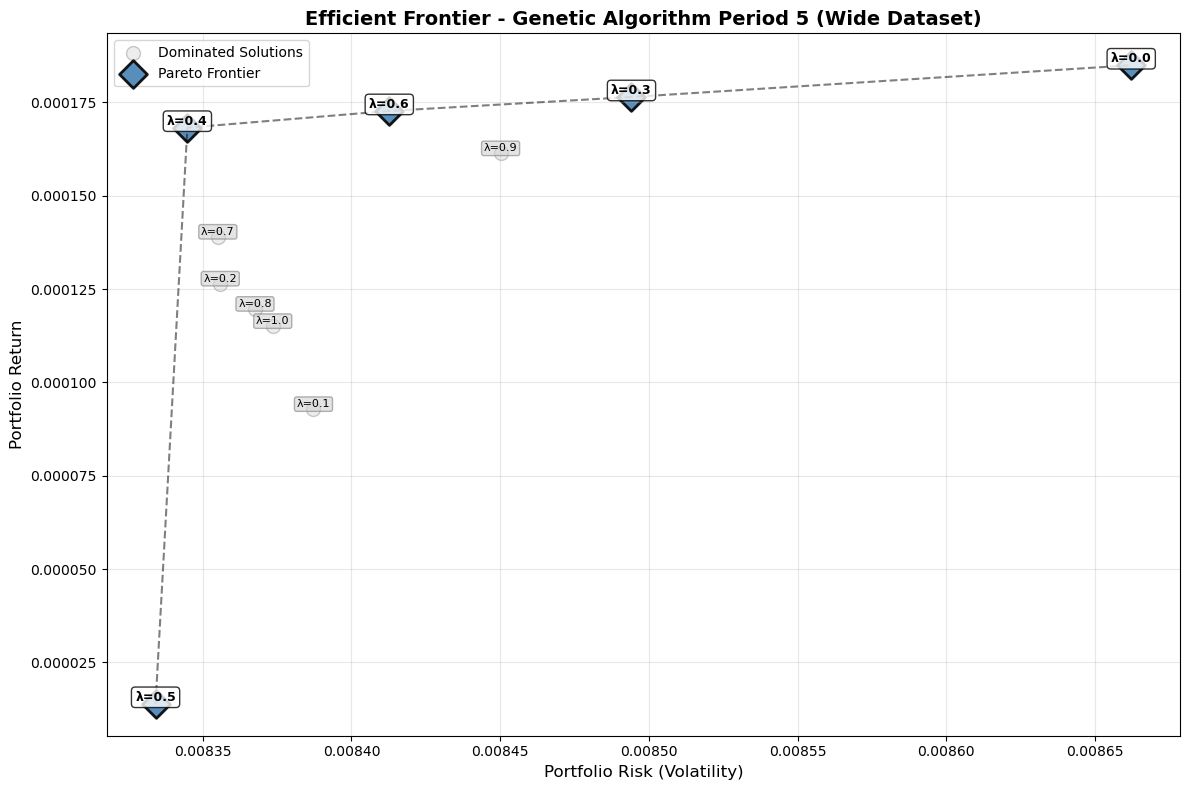


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 5
Efficiency: 45.5%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.500        0.000014     0.008334     0.0017      
0.400        0.000168     0.008345     0.0202      
0.600        0.000173     0.008413     0.0205      
0.300        0.000176     0.008494     0.0208      
0.000        0.000185     0.008662     0.0214      

PERIOD 6 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 6...


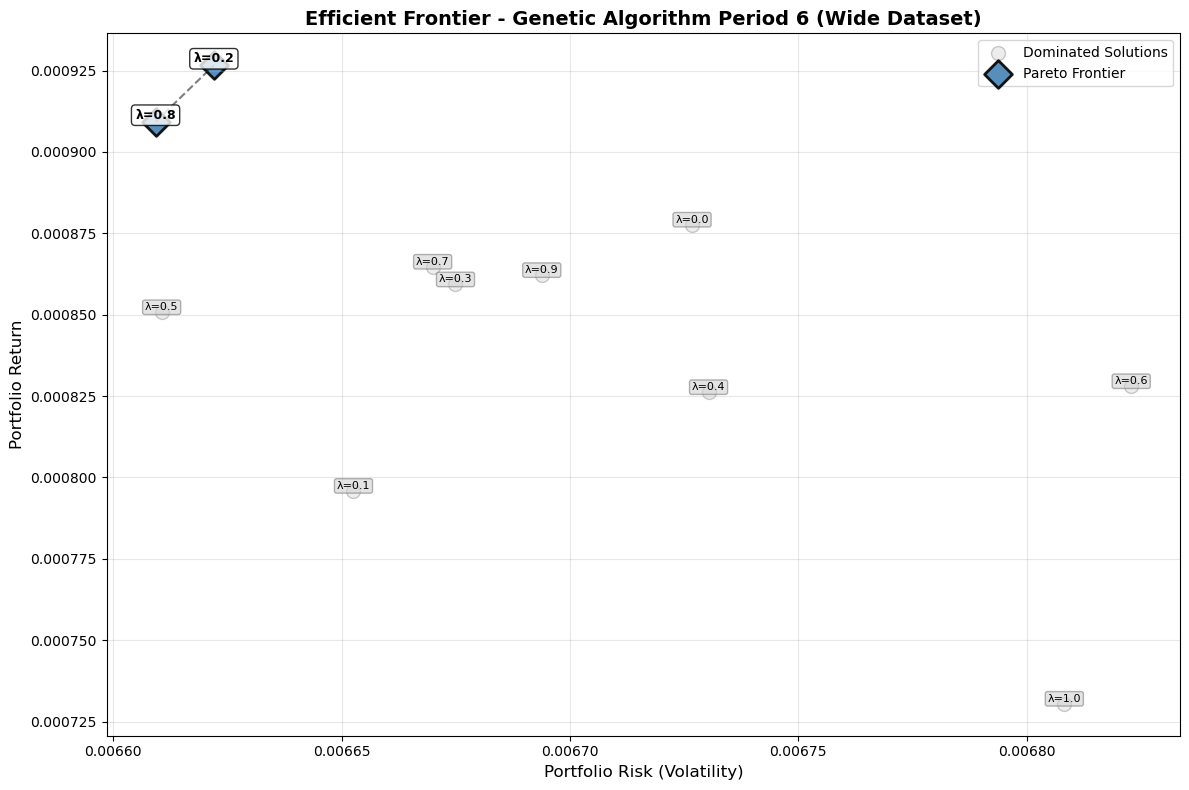


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 2
Efficiency: 18.2%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.800        0.000909     0.006609     0.1376      
0.200        0.000927     0.006622     0.1399      

PERIOD 7 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 7...


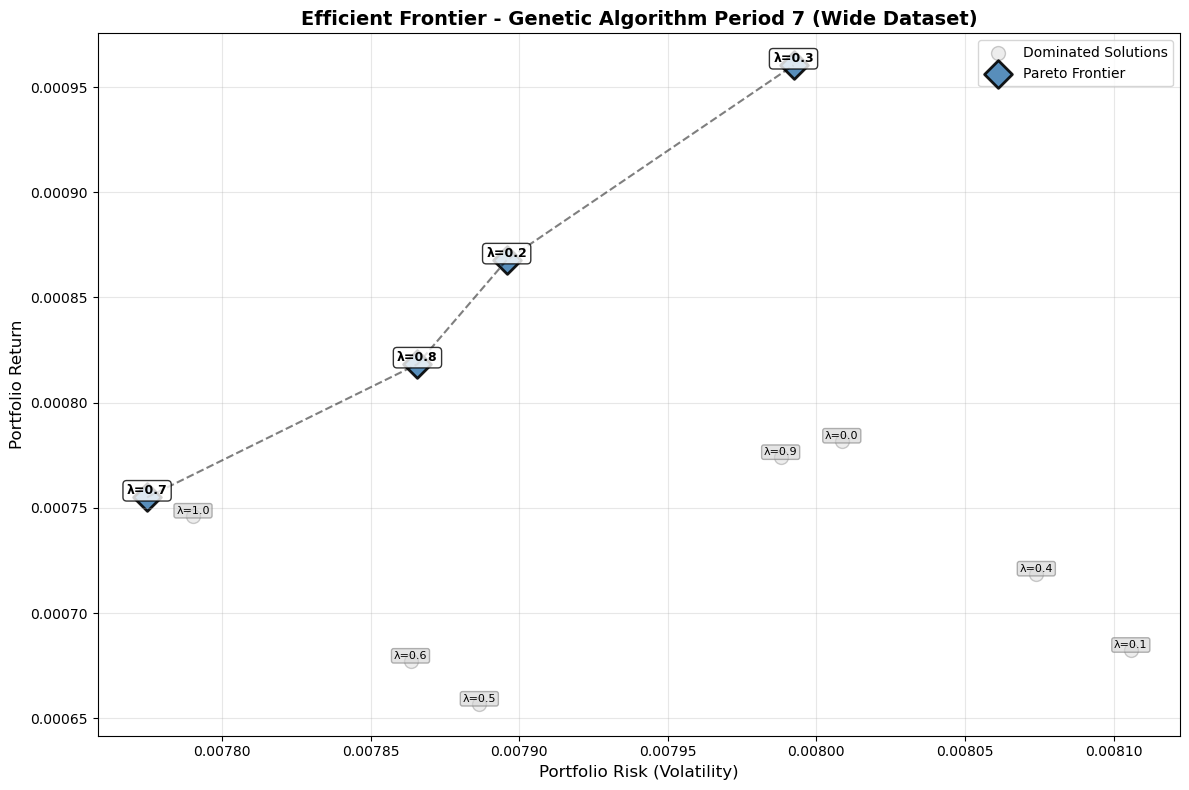


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 4
Efficiency: 36.4%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.700        0.000755     0.007775     0.0971      
0.800        0.000818     0.007866     0.1040      
0.200        0.000868     0.007896     0.1099      
0.300        0.000960     0.007992     0.1202      

PERIOD 8 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 8...


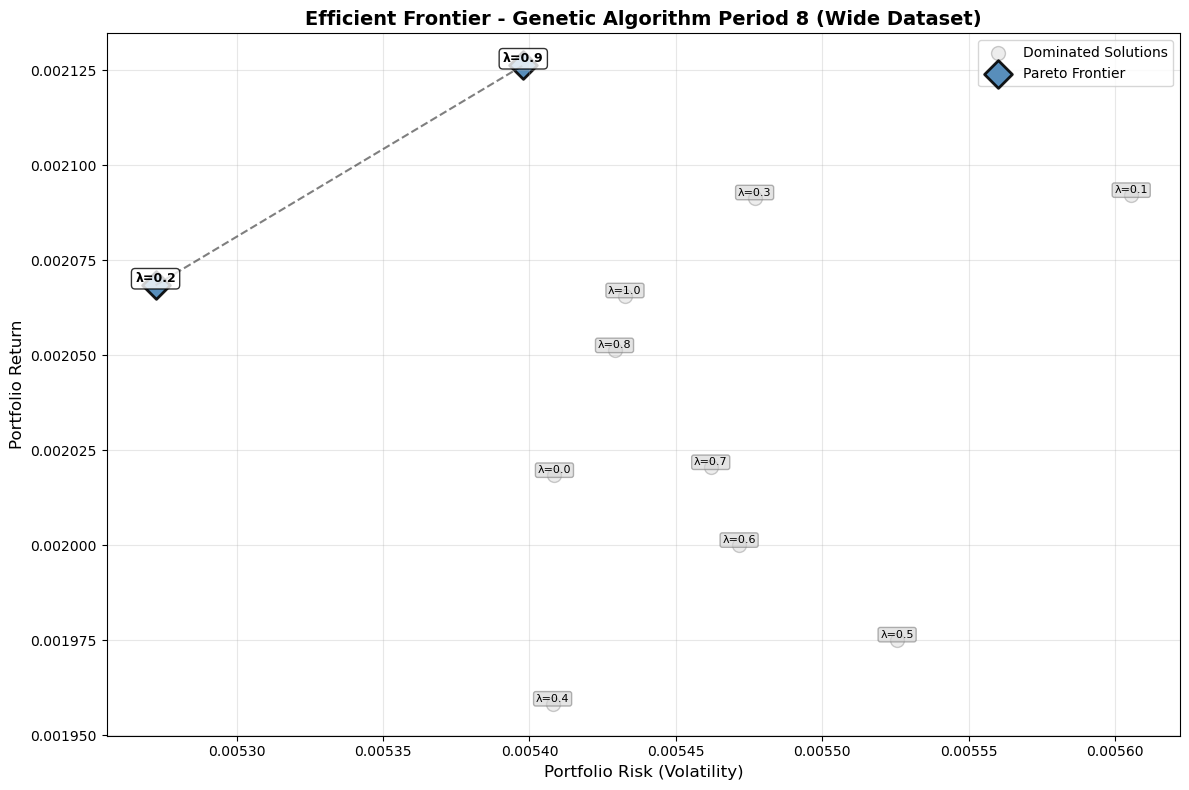


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 2
Efficiency: 18.2%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.200        0.002068     0.005272     0.3923      
0.900        0.002126     0.005398     0.3939      

PERIOD 9 - Genetic Algorithm (Wide Dataset)
Loading existing results for period 9...


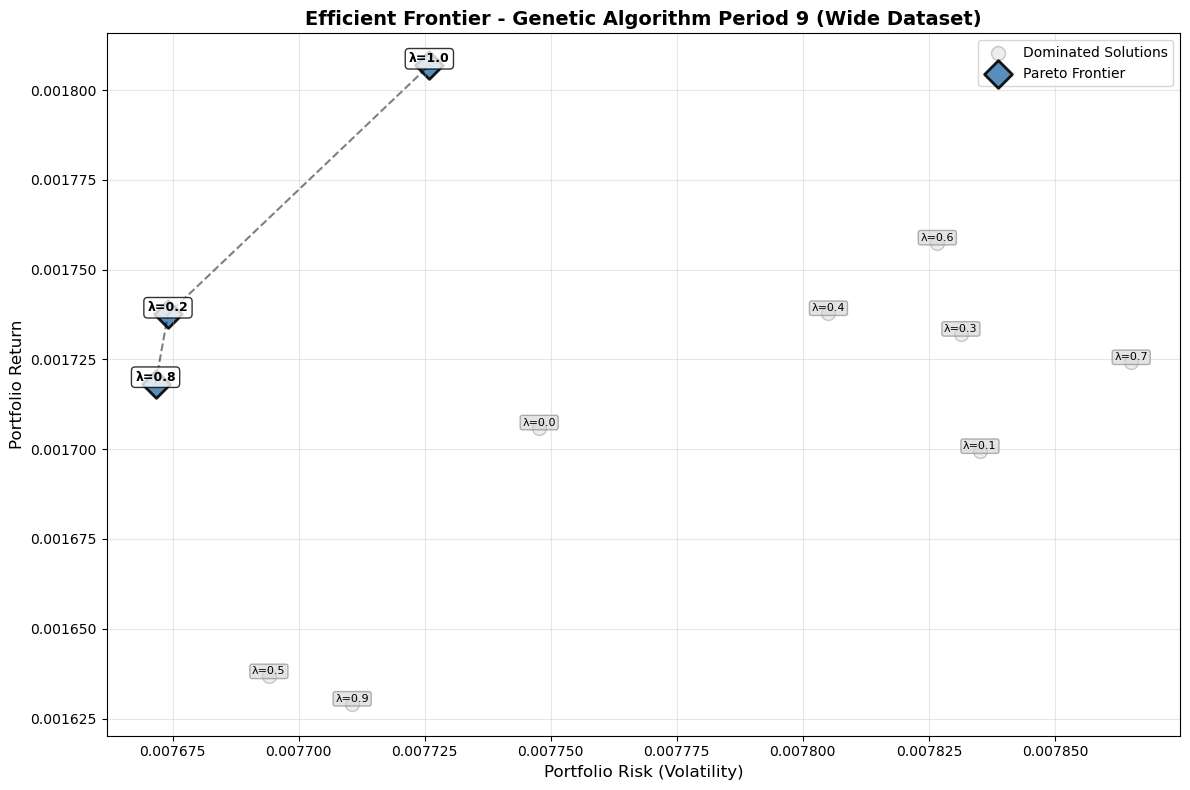


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 3
Efficiency: 27.3%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.800        0.001718     0.007672     0.2240      
0.200        0.001738     0.007674     0.2264      
1.000        0.001807     0.007726     0.2339      

Genetic Algorithm - Wide Dataset Complete


In [12]:
for period in range(parameters['n_periods']):
    run_pareto_optimization_period(
        period=period,
        solver_name='Genetic Algorithm',
        solver_key='ga',
        optimization_function=genetic_algorithm_qubo,
        data=source_wide,
        benchmark=benchmark,
        results_dict=all_periods_results_wide['genetic_algorithm'],
        parameters=parameters,
        results_base_path=results_base_path,
        population_size=parameters['population_size'],
        num_generations=parameters['num_generations'],
        mutation_rate=parameters['mutation_rate'],
        elitism=parameters['elitism']
    )

print(f"\n{'='*80}")
print("Genetic Algorithm - Wide Dataset Complete")
print(f"{'='*80}")

### SciPy SLSQP - Wide Dataset (All Periods)


PERIOD 0 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 0...


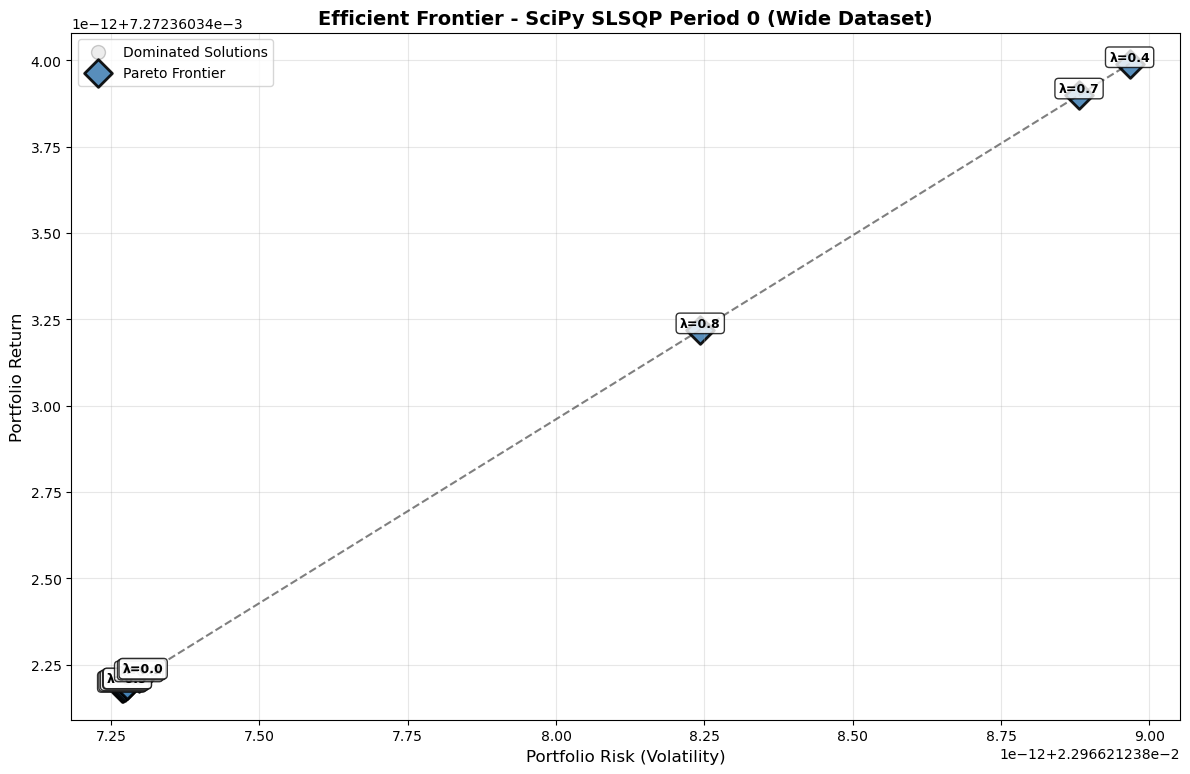


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.200        0.007272     0.022966     0.3167      
0.600        0.007272     0.022966     0.3167      
0.300        0.007272     0.022966     0.3167      
1.000        0.007272     0.022966     0.3167      
0.900        0.007272     0.022966     0.3167      
0.500        0.007272     0.022966     0.3167      
0.100        0.007272     0.022966     0.3167      
0.000        0.007272     0.022966     0.3167      
0.800        0.007272     0.022966     0.3167      
0.700        0.007272     0.022966     0.3167      
0.400        0.007272     0.022966     0.3167      

PERIOD 1 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 1...


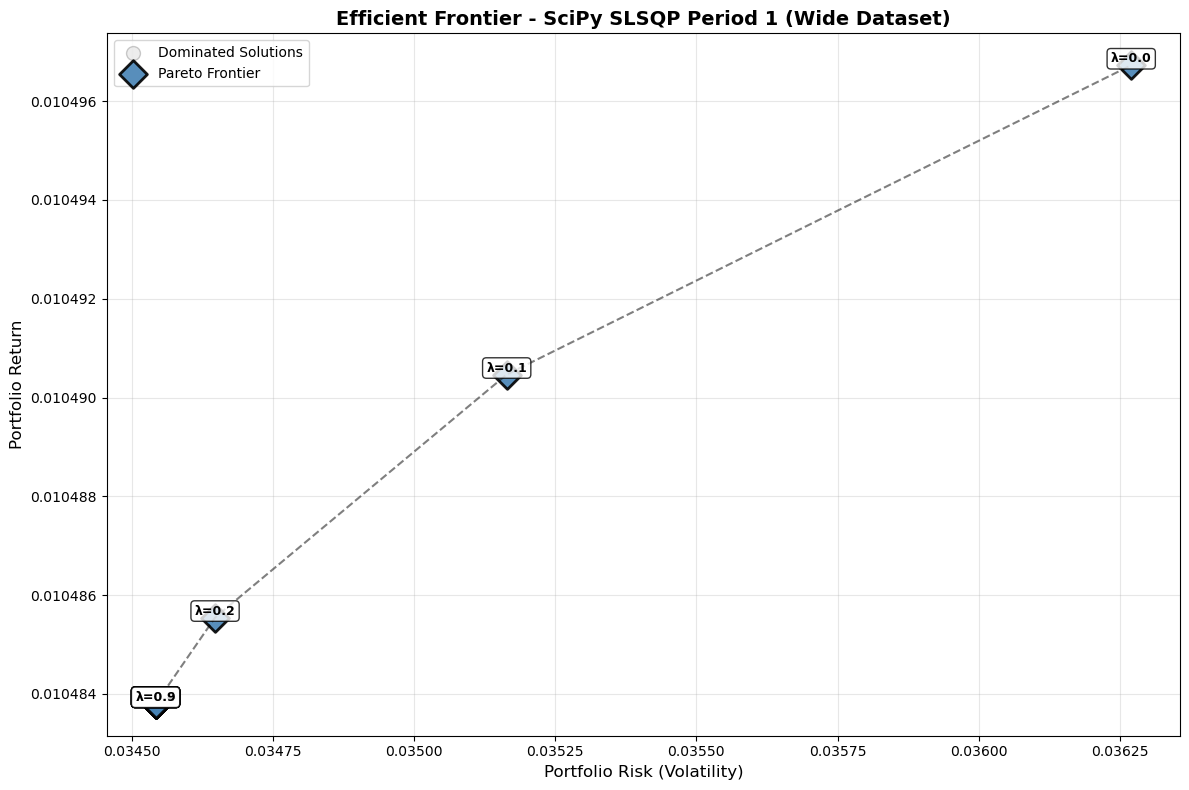


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.700        0.010484     0.034542     0.3035      
1.000        0.010484     0.034542     0.3035      
0.300        0.010484     0.034542     0.3035      
0.800        0.010484     0.034542     0.3035      
0.600        0.010484     0.034542     0.3035      
0.500        0.010484     0.034542     0.3035      
0.400        0.010484     0.034542     0.3035      
0.900        0.010484     0.034542     0.3035      
0.200        0.010486     0.034648     0.3026      
0.100        0.010490     0.035164     0.2983      
0.000        0.010497     0.036270     0.2894      

PERIOD 2 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 2...


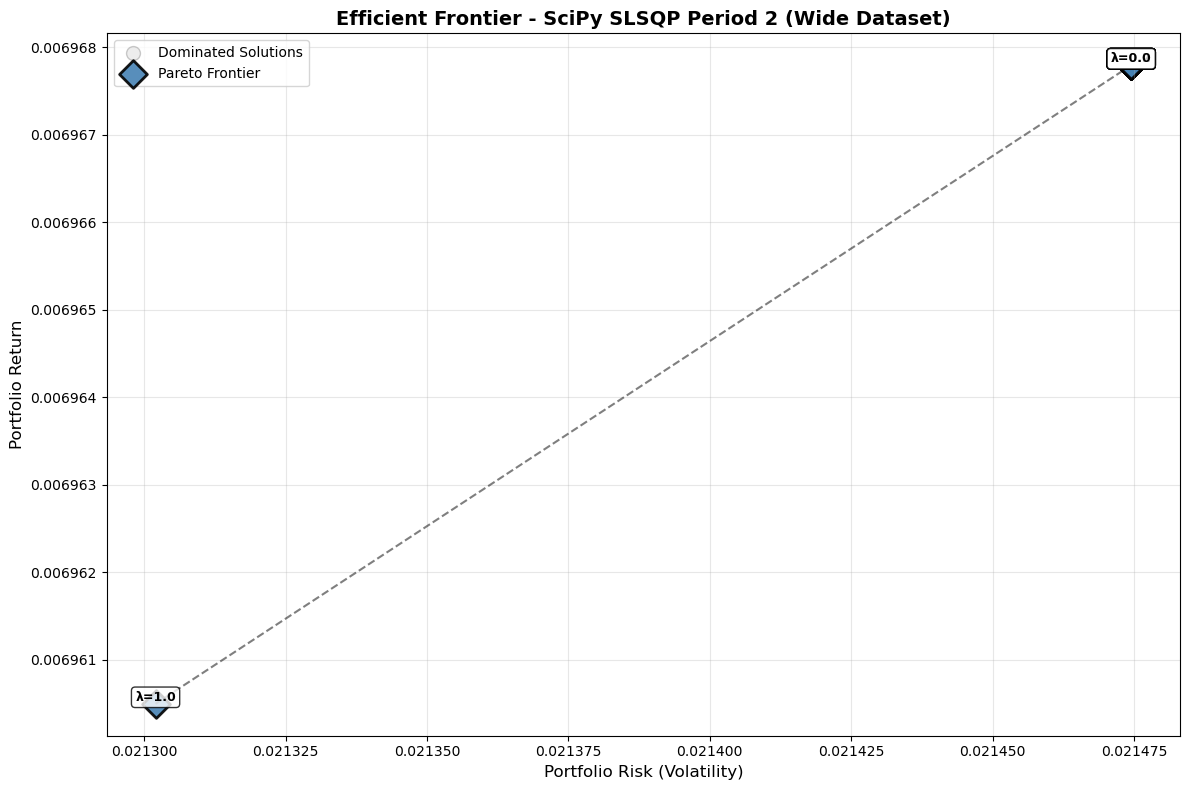


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.006960     0.021302     0.3268      
0.900        0.006968     0.021475     0.3245      
0.800        0.006968     0.021475     0.3245      
0.600        0.006968     0.021475     0.3245      
0.500        0.006968     0.021475     0.3245      
0.700        0.006968     0.021475     0.3245      
0.400        0.006968     0.021475     0.3245      
0.300        0.006968     0.021475     0.3245      
0.100        0.006968     0.021475     0.3245      
0.200        0.006968     0.021475     0.3245      
0.000        0.006968     0.021475     0.3245      

PERIOD 3 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 3...


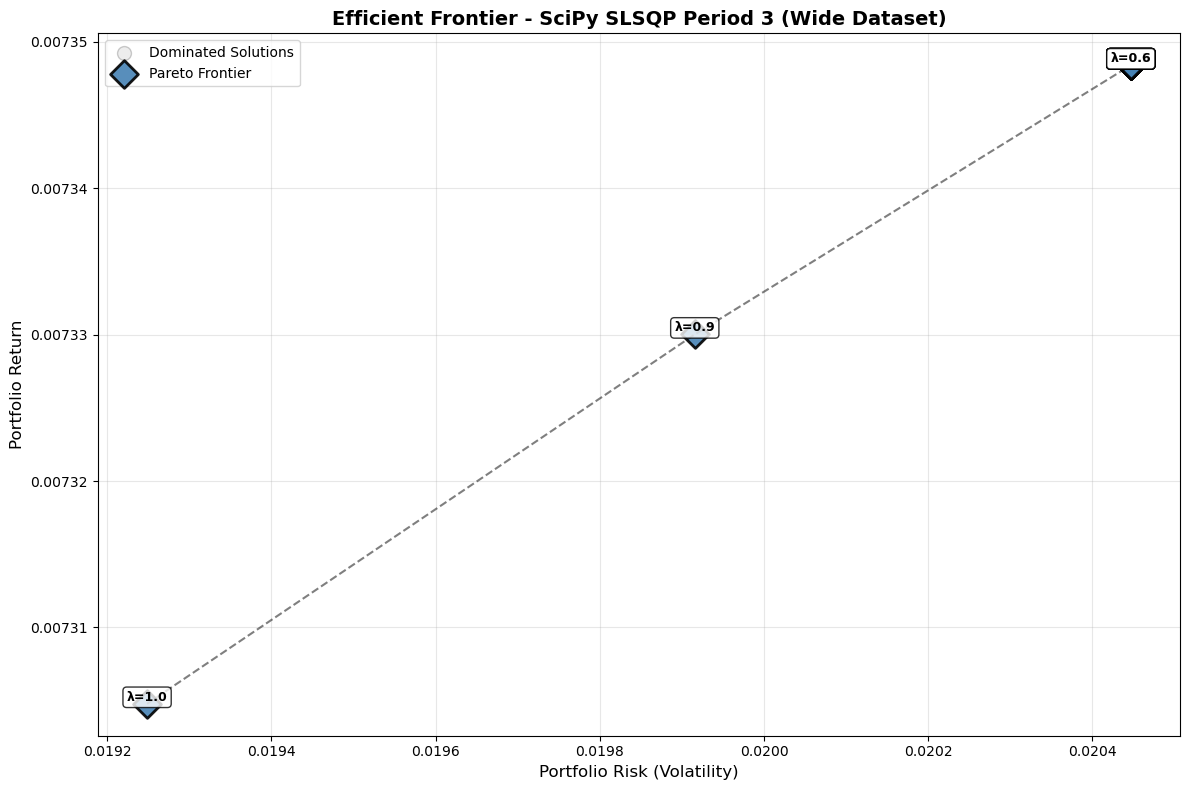


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.007305     0.019249     0.3795      
0.900        0.007330     0.019916     0.3681      
0.400        0.007348     0.020447     0.3594      
0.800        0.007348     0.020447     0.3594      
0.300        0.007348     0.020447     0.3594      
0.000        0.007348     0.020447     0.3594      
0.700        0.007348     0.020447     0.3594      
0.200        0.007348     0.020447     0.3594      
0.100        0.007348     0.020447     0.3594      
0.500        0.007348     0.020447     0.3594      
0.600        0.007348     0.020447     0.3594      

PERIOD 4 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 4...


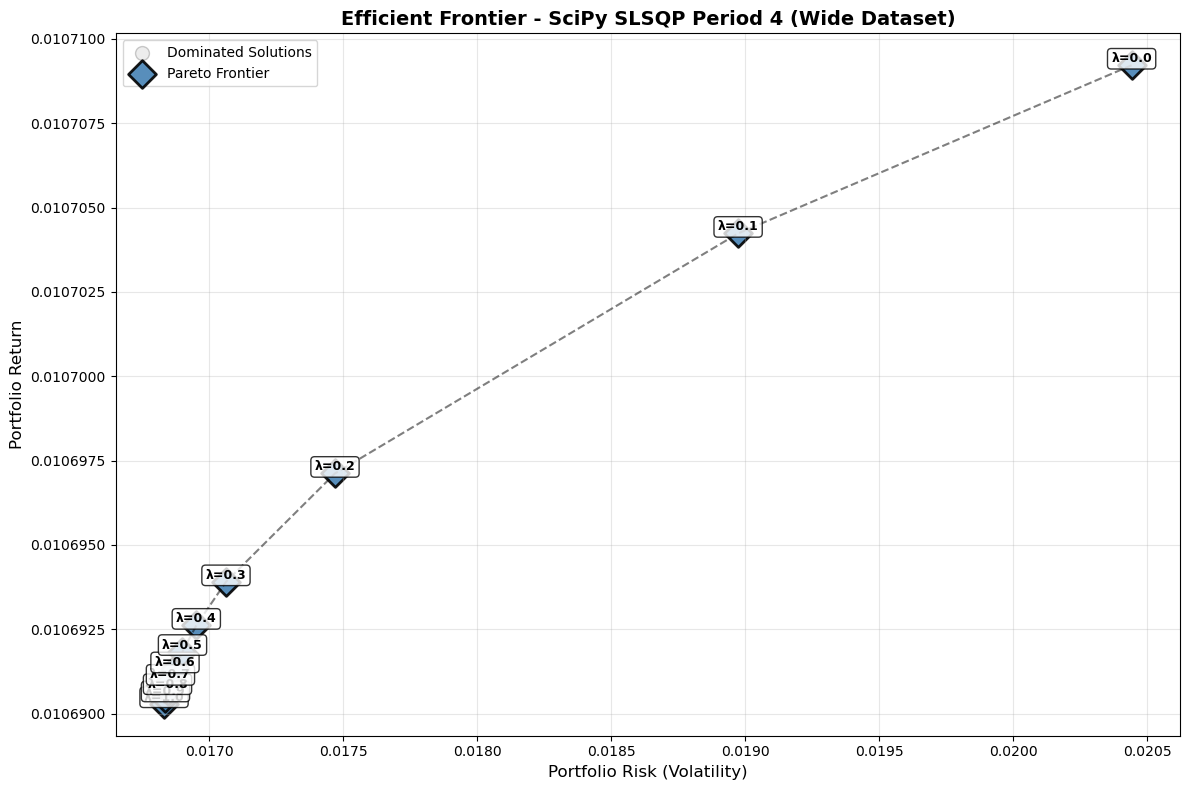


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.010690     0.016832     0.6351      
0.900        0.010690     0.016837     0.6349      
0.800        0.010691     0.016845     0.6346      
0.700        0.010691     0.016856     0.6343      
0.600        0.010691     0.016873     0.6336      
0.500        0.010692     0.016901     0.6326      
0.400        0.010693     0.016952     0.6307      
0.300        0.010694     0.017063     0.6267      
0.200        0.010697     0.017470     0.6123      
0.100        0.010704     0.018974     0.5642      
0.000        0.010709     0.020442     0.5239      

PERIOD 5 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 5...


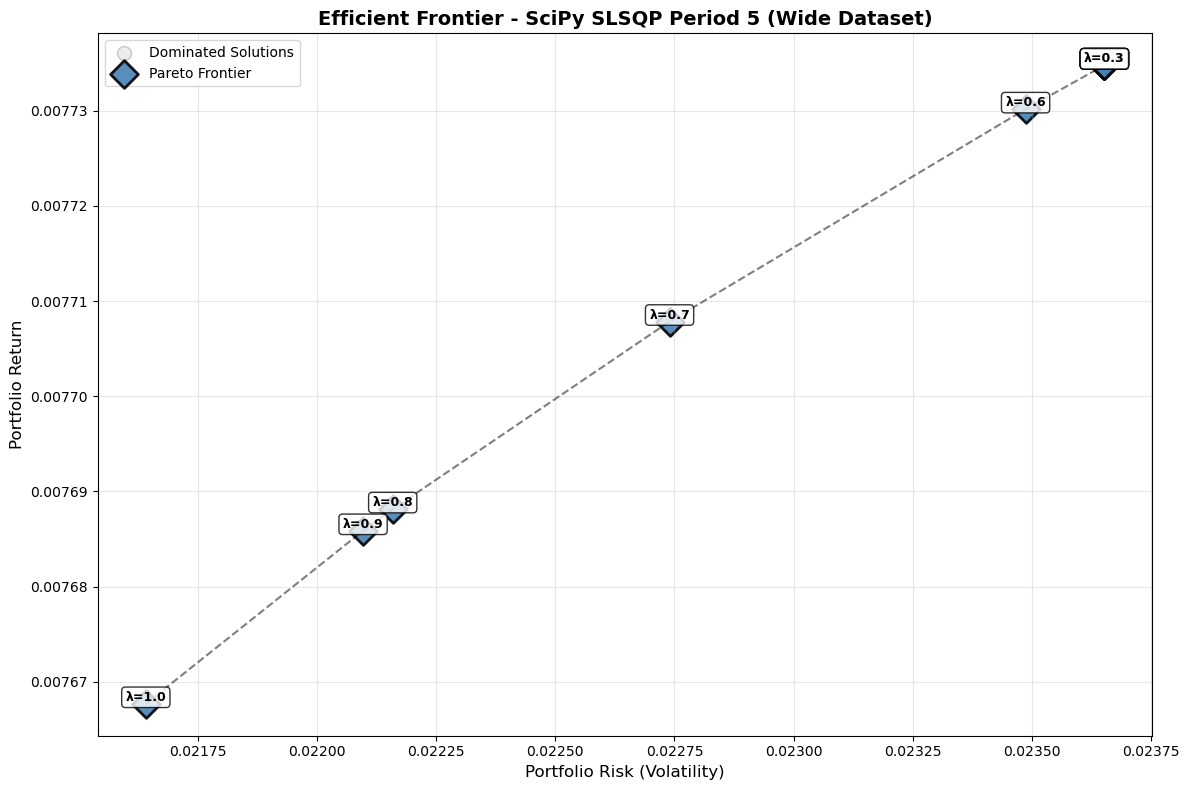


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.007668     0.021641     0.3543      
0.900        0.007686     0.022097     0.3478      
0.800        0.007688     0.022159     0.3470      
0.700        0.007708     0.022740     0.3390      
0.600        0.007730     0.023487     0.3291      
0.000        0.007735     0.023652     0.3270      
0.200        0.007735     0.023652     0.3270      
0.500        0.007735     0.023652     0.3270      
0.400        0.007735     0.023652     0.3270      
0.100        0.007735     0.023652     0.3270      
0.300        0.007735     0.023652     0.3270      

PERIOD 6 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 6...


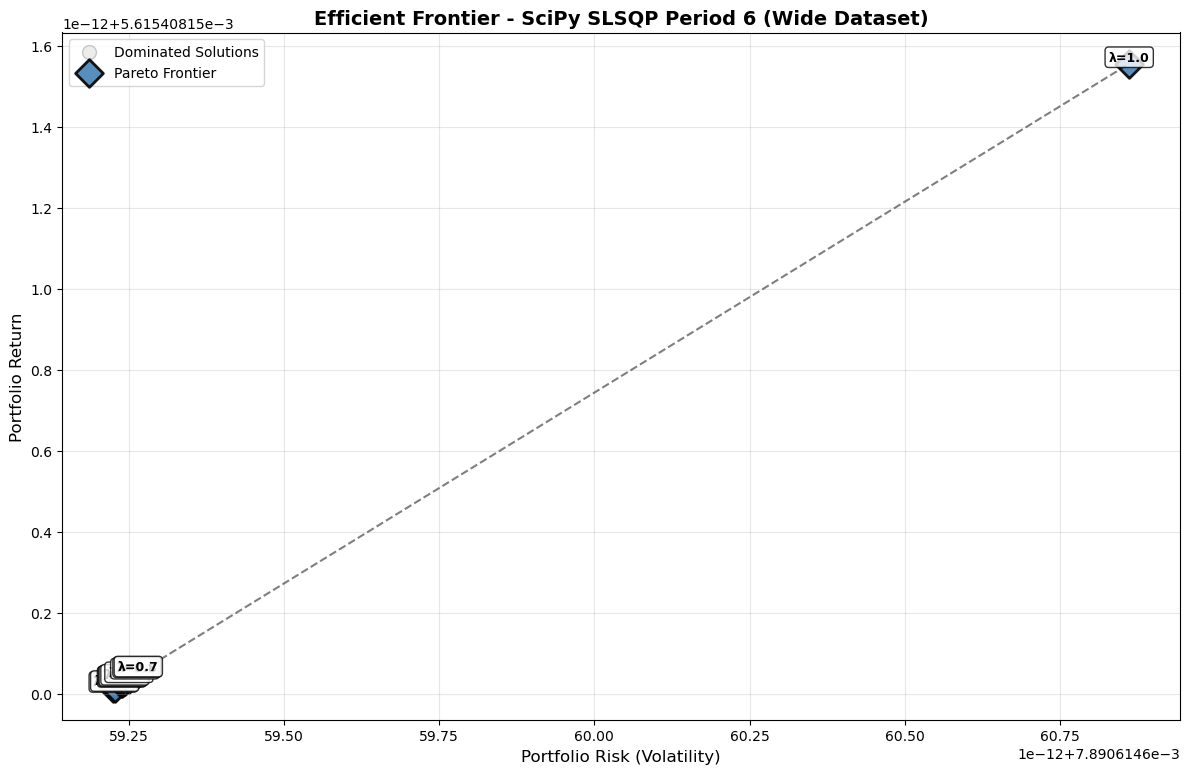


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.600        0.005615     0.007891     0.7117      
0.500        0.005615     0.007891     0.7117      
0.900        0.005615     0.007891     0.7117      
0.300        0.005615     0.007891     0.7117      
0.400        0.005615     0.007891     0.7117      
0.200        0.005615     0.007891     0.7117      
0.000        0.005615     0.007891     0.7117      
0.100        0.005615     0.007891     0.7117      
0.800        0.005615     0.007891     0.7117      
0.700        0.005615     0.007891     0.7117      
1.000        0.005615     0.007891     0.7117      

PERIOD 7 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 7...


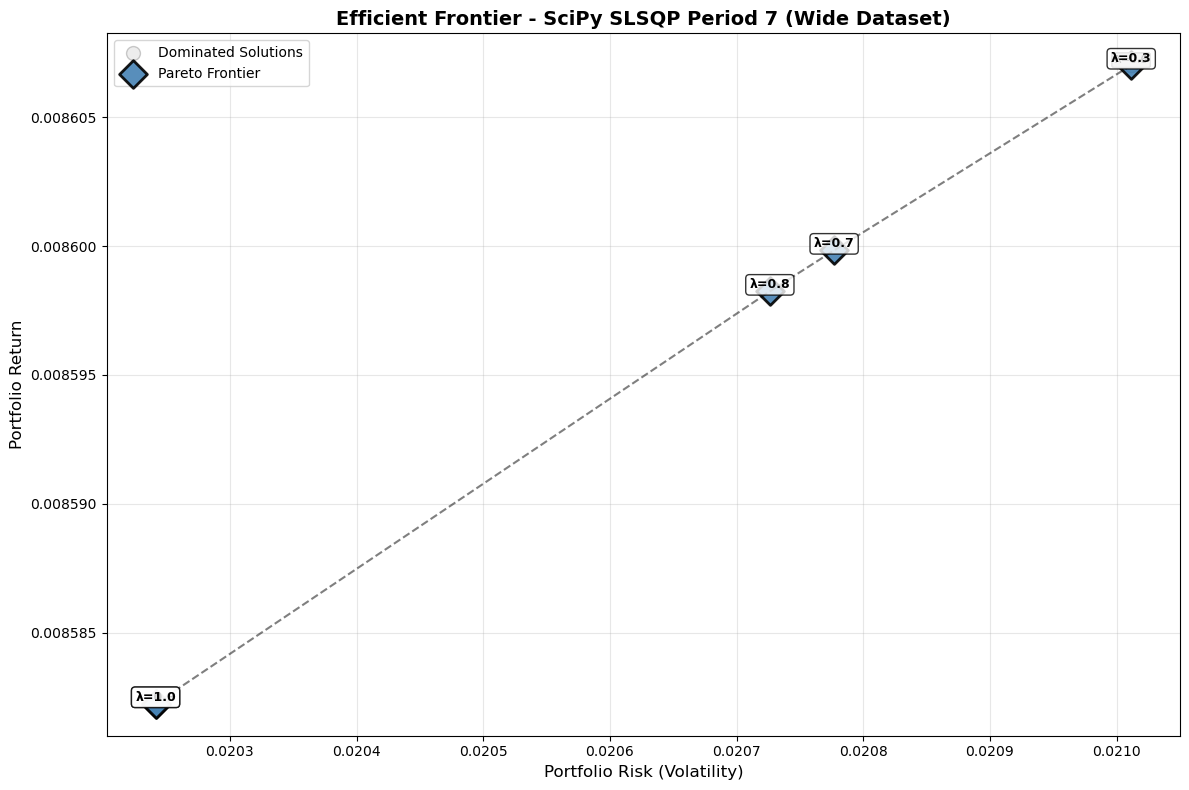


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 5
Efficiency: 45.5%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.900        0.008582     0.020241     0.4240      
1.000        0.008582     0.020241     0.4240      
0.800        0.008598     0.020726     0.4148      
0.700        0.008600     0.020777     0.4139      
0.300        0.008607     0.021012     0.4096      

PERIOD 8 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 8...


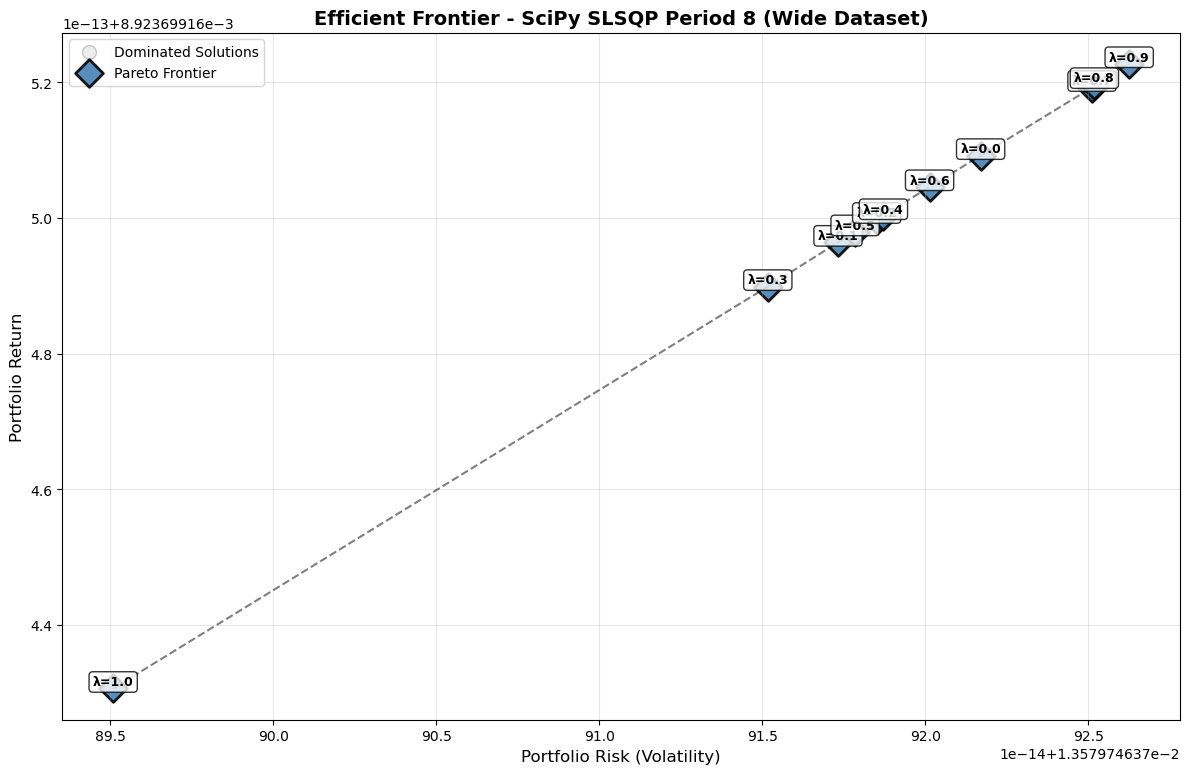


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.008924     0.013580     0.6571      
0.300        0.008924     0.013580     0.6571      
0.100        0.008924     0.013580     0.6571      
0.500        0.008924     0.013580     0.6571      
0.200        0.008924     0.013580     0.6571      
0.400        0.008924     0.013580     0.6571      
0.600        0.008924     0.013580     0.6571      
0.000        0.008924     0.013580     0.6571      
0.700        0.008924     0.013580     0.6571      
0.800        0.008924     0.013580     0.6571      
0.900        0.008924     0.013580     0.6571      

PERIOD 9 - SciPy SLSQP (Wide Dataset)
Loading existing results for period 9...


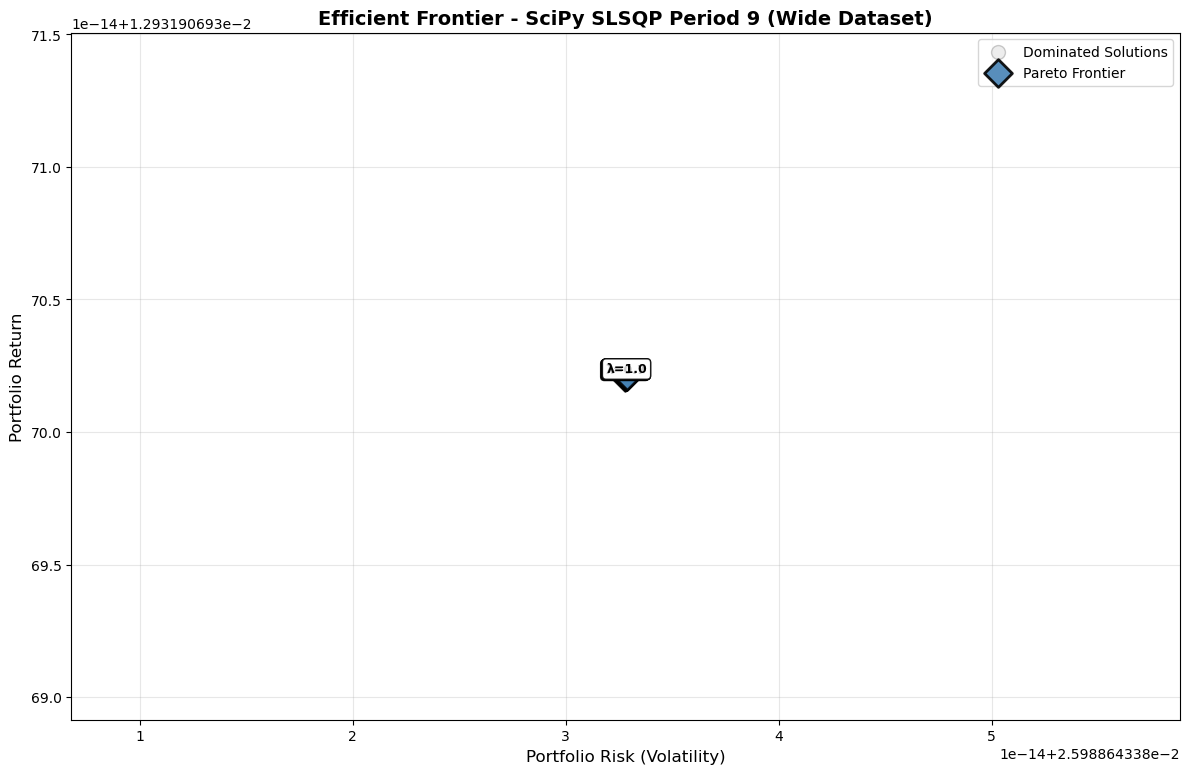


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 8
Efficiency: 72.7%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.100        0.012932     0.025989     0.4976      
0.000        0.012932     0.025989     0.4976      
0.800        0.012932     0.025989     0.4976      
0.300        0.012932     0.025989     0.4976      
0.900        0.012932     0.025989     0.4976      
0.200        0.012932     0.025989     0.4976      
0.700        0.012932     0.025989     0.4976      
1.000        0.012932     0.025989     0.4976      

SciPy SLSQP - Wide Dataset Complete


In [13]:
for period in range(parameters['n_periods']):
    run_pareto_optimization_period(
        period=period,
        solver_name='SciPy SLSQP',
        solver_key='slsqp',
        optimization_function=scipy_slsqp_qubo,
        data=source_wide,
        benchmark=benchmark,
        results_dict=all_periods_results_wide['scipy_slsqp'],
        parameters=parameters,
        results_base_path=results_base_path
    )

print(f"\n{'='*80}")
print("SciPy SLSQP - Wide Dataset Complete")
print(f"{'='*80}")

### Riskfolio - Wide Dataset (All Periods)


PERIOD 0 - Riskfolio (Wide Dataset)
Loading existing results for period 0...


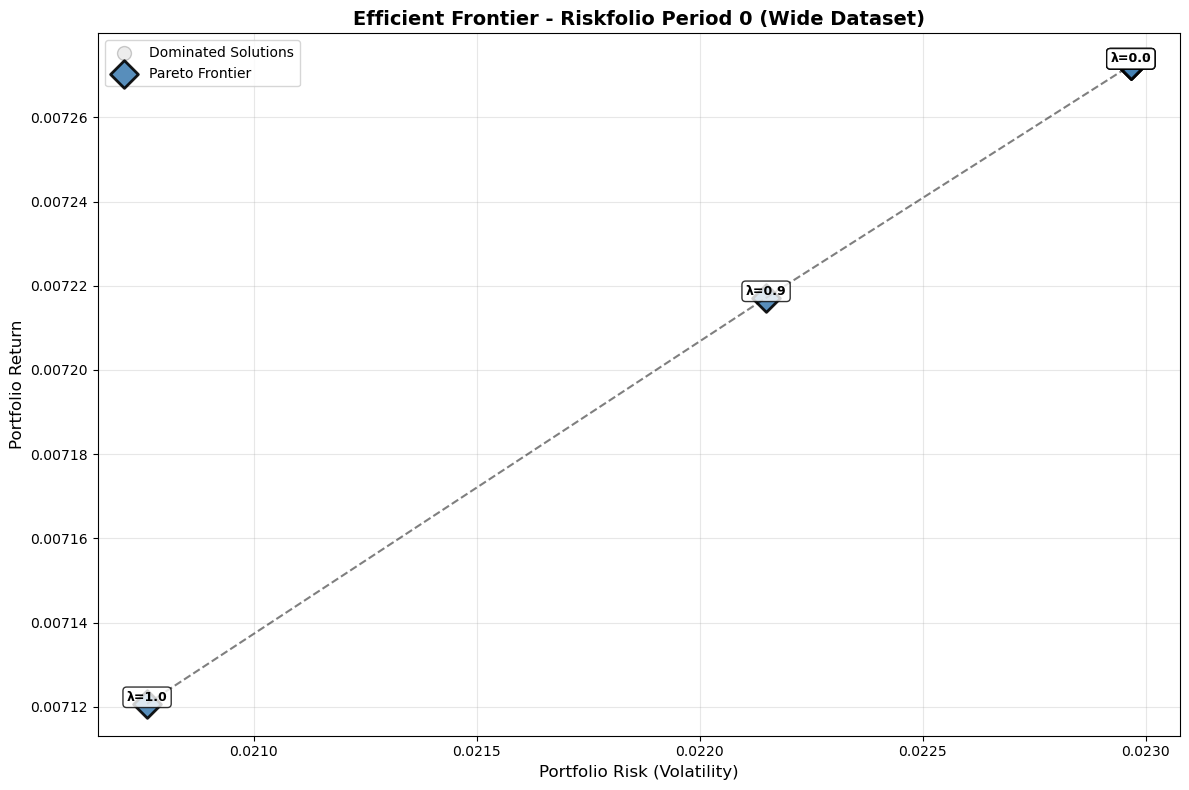


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 6
Efficiency: 54.5%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.007121     0.020761     0.3430      
0.900        0.007217     0.022149     0.3259      
0.700        0.007272     0.022966     0.3167      
0.200        0.007272     0.022966     0.3167      
0.300        0.007272     0.022966     0.3167      
0.000        0.007272     0.022966     0.3167      

PERIOD 1 - Riskfolio (Wide Dataset)
Loading existing results for period 1...


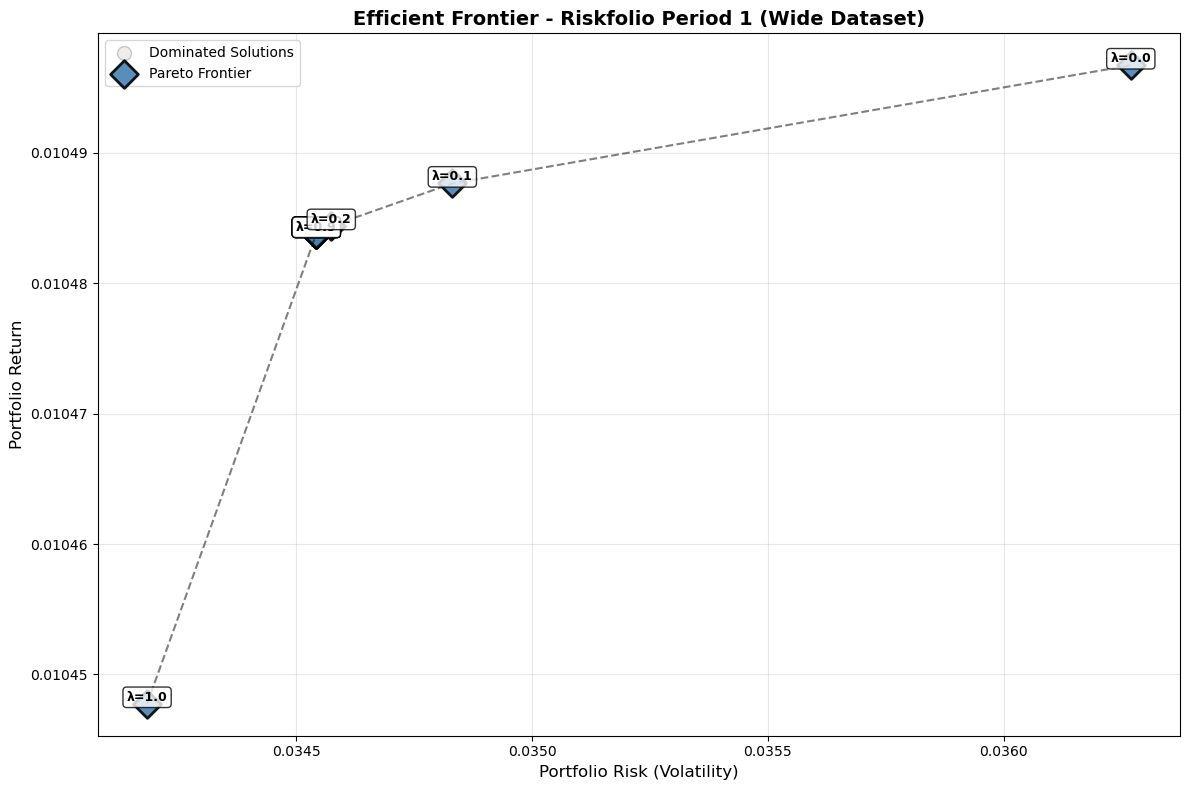


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 10
Efficiency: 90.9%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.010448     0.034184     0.3056      
0.600        0.010484     0.034542     0.3035      
0.700        0.010484     0.034542     0.3035      
0.500        0.010484     0.034542     0.3035      
0.800        0.010484     0.034542     0.3035      
0.400        0.010484     0.034542     0.3035      
0.900        0.010484     0.034542     0.3035      
0.200        0.010484     0.034574     0.3032      
0.100        0.010488     0.034831     0.3011      
0.000        0.010497     0.036270     0.2894      

PERIOD 2 - Riskfolio (Wide Dataset)
Loading existing results for period 2...


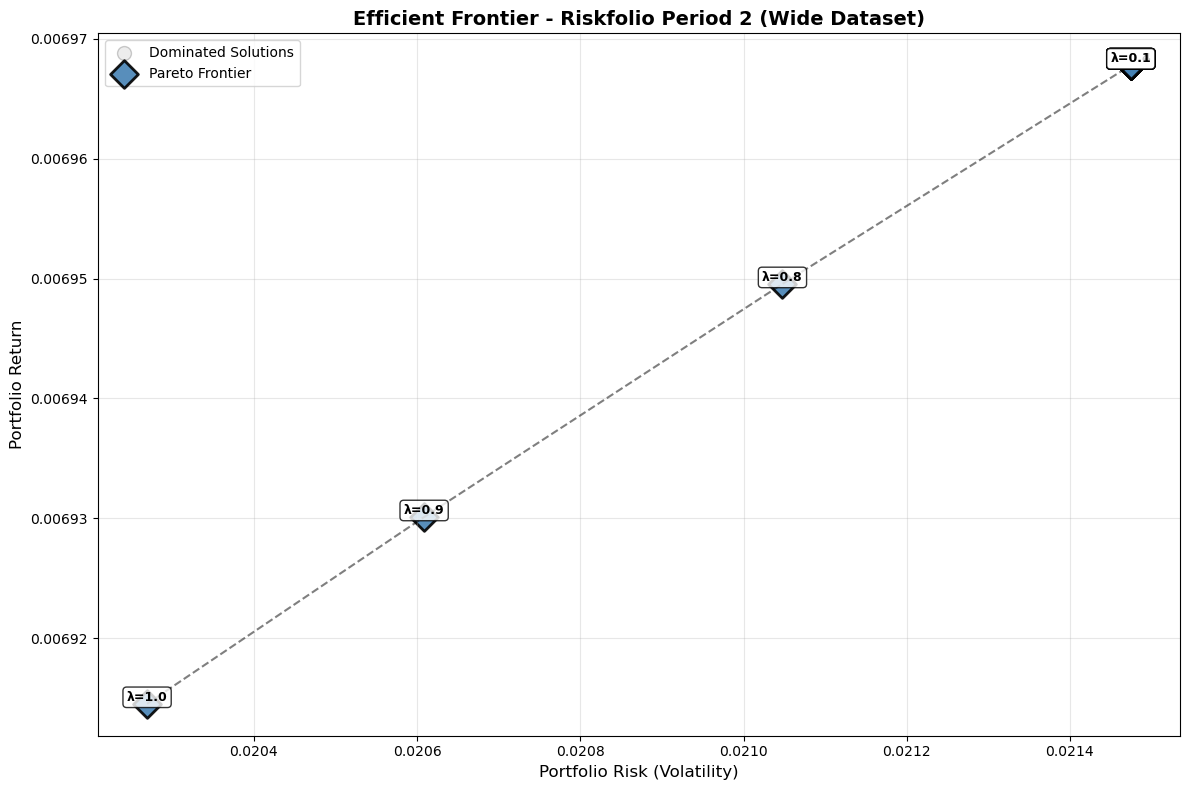


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.006915     0.020269     0.3411      
0.900        0.006930     0.020609     0.3363      
0.800        0.006950     0.021048     0.3302      
0.500        0.006968     0.021475     0.3245      
0.600        0.006968     0.021475     0.3245      
0.300        0.006968     0.021475     0.3245      
0.200        0.006968     0.021475     0.3245      
0.000        0.006968     0.021475     0.3245      
0.700        0.006968     0.021475     0.3245      
0.400        0.006968     0.021475     0.3245      
0.100        0.006968     0.021475     0.3245      

PERIOD 3 - Riskfolio (Wide Dataset)
Loading existing results for period 3...


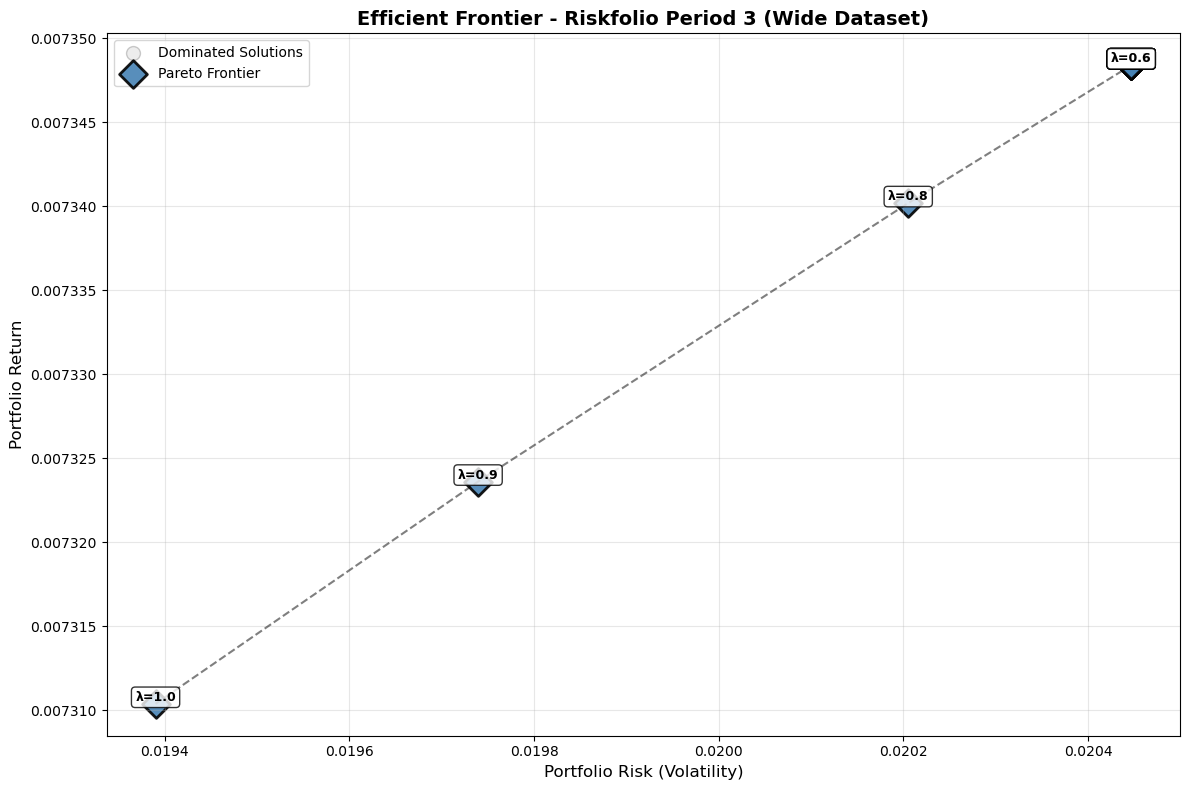


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 10
Efficiency: 90.9%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.007310     0.019390     0.3770      
0.900        0.007324     0.019739     0.3710      
0.800        0.007340     0.020205     0.3633      
0.700        0.007348     0.020447     0.3594      
0.000        0.007348     0.020447     0.3594      
0.300        0.007348     0.020447     0.3594      
0.200        0.007348     0.020447     0.3594      
0.400        0.007348     0.020447     0.3594      
0.500        0.007348     0.020447     0.3594      
0.600        0.007348     0.020447     0.3594      

PERIOD 4 - Riskfolio (Wide Dataset)
Loading existing results for period 4...


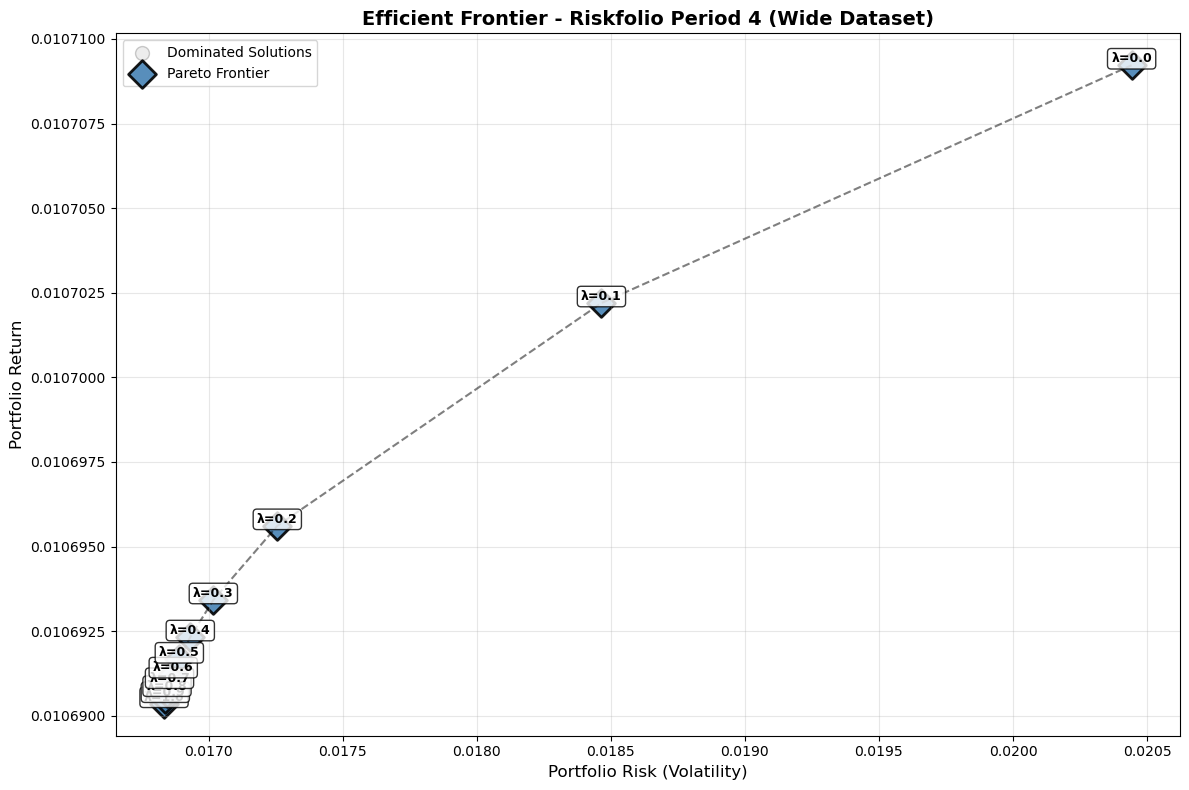


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.010690     0.016834     0.6350      
0.900        0.010691     0.016839     0.6349      
0.800        0.010691     0.016845     0.6346      
0.700        0.010691     0.016854     0.6343      
0.600        0.010691     0.016868     0.6338      
0.500        0.010692     0.016891     0.6330      
0.400        0.010692     0.016932     0.6315      
0.300        0.010693     0.017018     0.6284      
0.200        0.010696     0.017257     0.6198      
0.100        0.010702     0.018465     0.5796      
0.000        0.010709     0.020442     0.5239      

PERIOD 5 - Riskfolio (Wide Dataset)
Loading existing results for period 5...


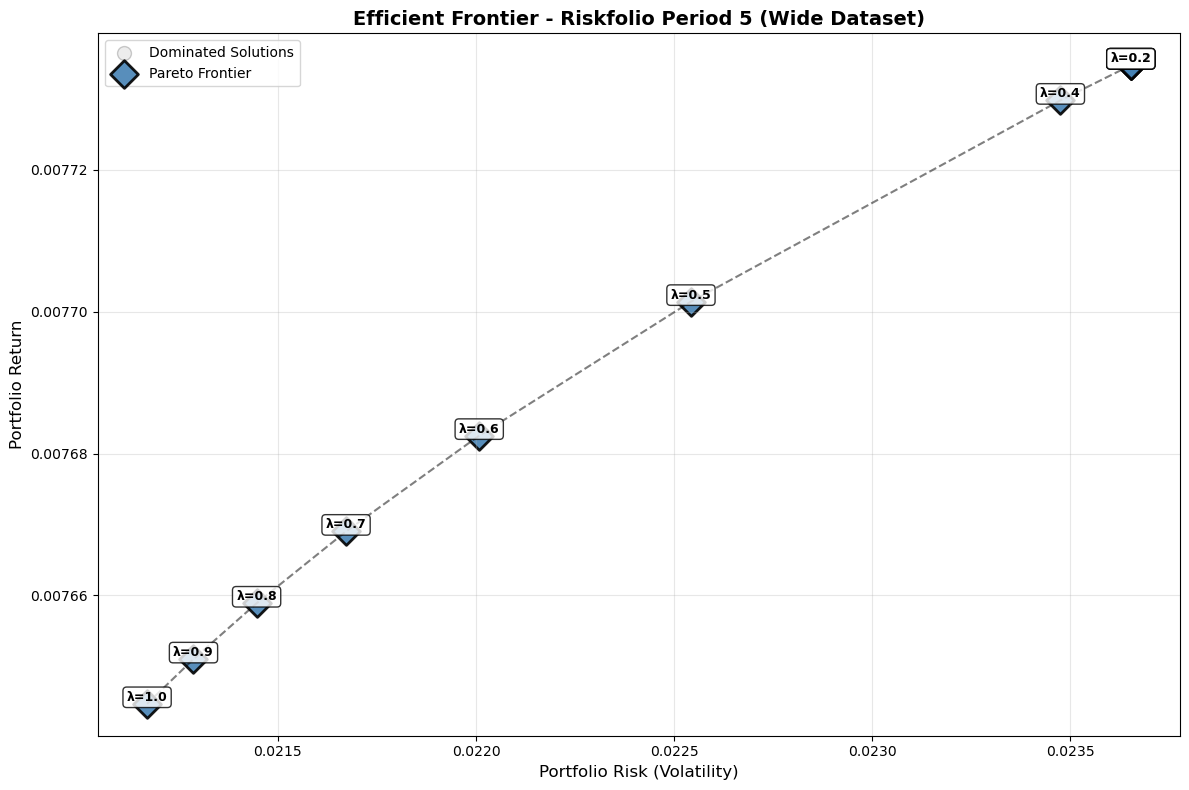


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
1.000        0.007645     0.021170     0.3611      
0.900        0.007651     0.021287     0.3594      
0.800        0.007659     0.021446     0.3571      
0.700        0.007669     0.021672     0.3539      
0.600        0.007683     0.022008     0.3491      
0.500        0.007701     0.022542     0.3416      
0.400        0.007730     0.023474     0.3293      
0.300        0.007735     0.023652     0.3270      
0.000        0.007735     0.023652     0.3270      
0.100        0.007735     0.023652     0.3270      
0.200        0.007735     0.023652     0.3270      

PERIOD 6 - Riskfolio (Wide Dataset)
Loading existing results for period 6...


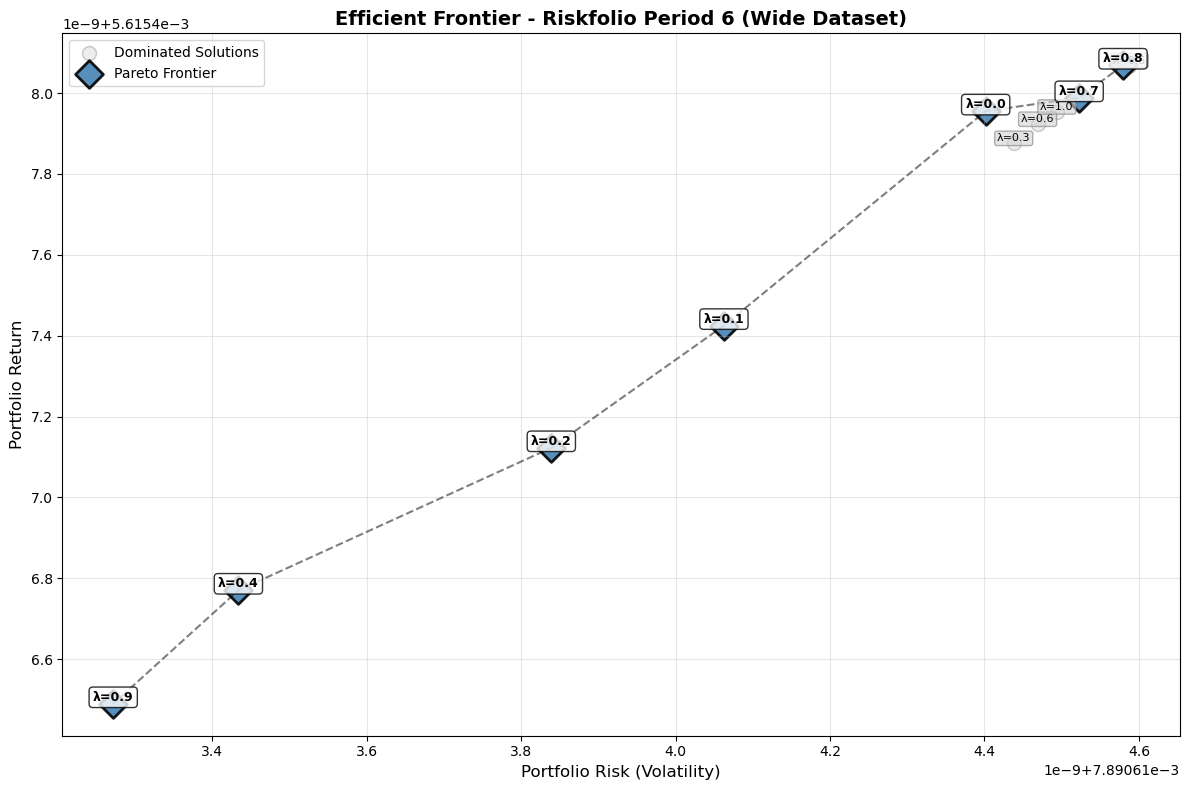


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 7
Efficiency: 63.6%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.900        0.005615     0.007891     0.7117      
0.400        0.005615     0.007891     0.7117      
0.200        0.005615     0.007891     0.7117      
0.100        0.005615     0.007891     0.7117      
0.000        0.005615     0.007891     0.7117      
0.700        0.005615     0.007891     0.7117      
0.800        0.005615     0.007891     0.7117      

PERIOD 7 - Riskfolio (Wide Dataset)
Loading existing results for period 7...


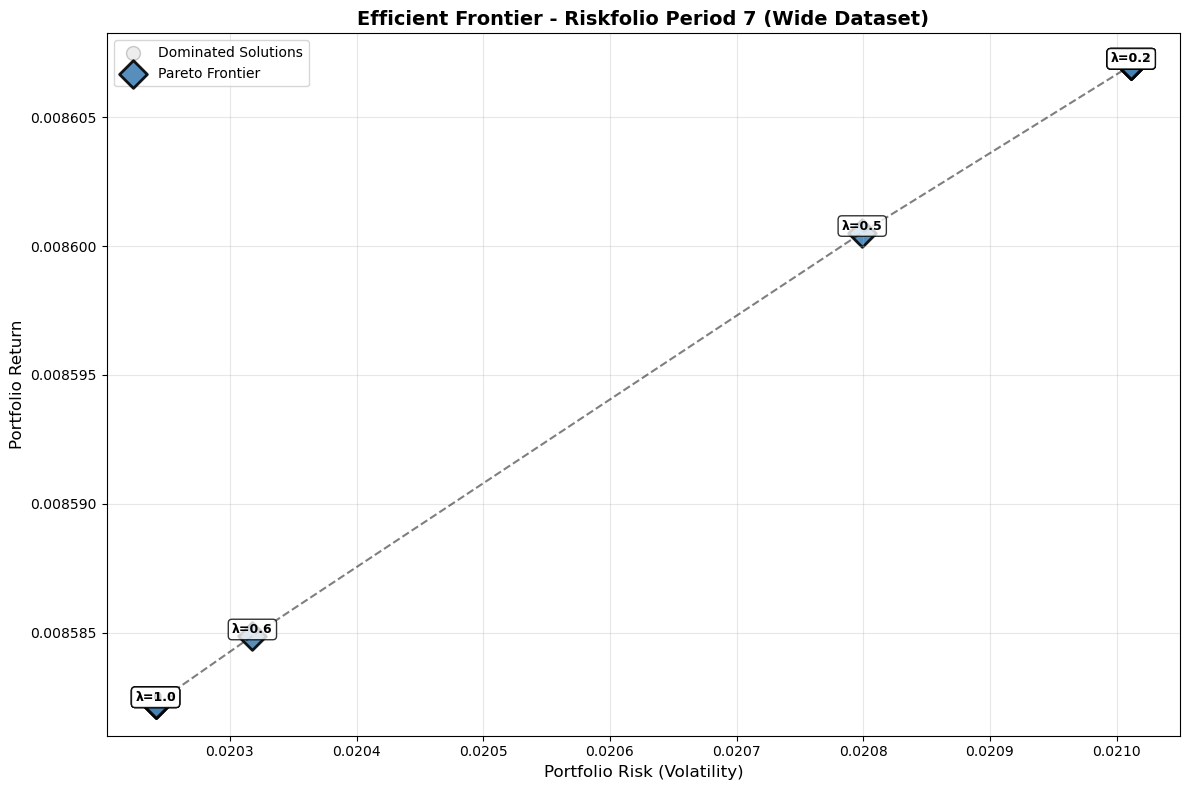


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 11
Efficiency: 100.0%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.700        0.008582     0.020241     0.4240      
0.900        0.008582     0.020241     0.4240      
0.800        0.008582     0.020241     0.4240      
1.000        0.008582     0.020241     0.4240      
0.600        0.008585     0.020318     0.4225      
0.500        0.008601     0.020799     0.4135      
0.100        0.008607     0.021012     0.4096      
0.400        0.008607     0.021012     0.4096      
0.000        0.008607     0.021012     0.4096      
0.300        0.008607     0.021012     0.4096      
0.200        0.008607     0.021012     0.4096      

PERIOD 8 - Riskfolio (Wide Dataset)
Loading existing results for period 8...


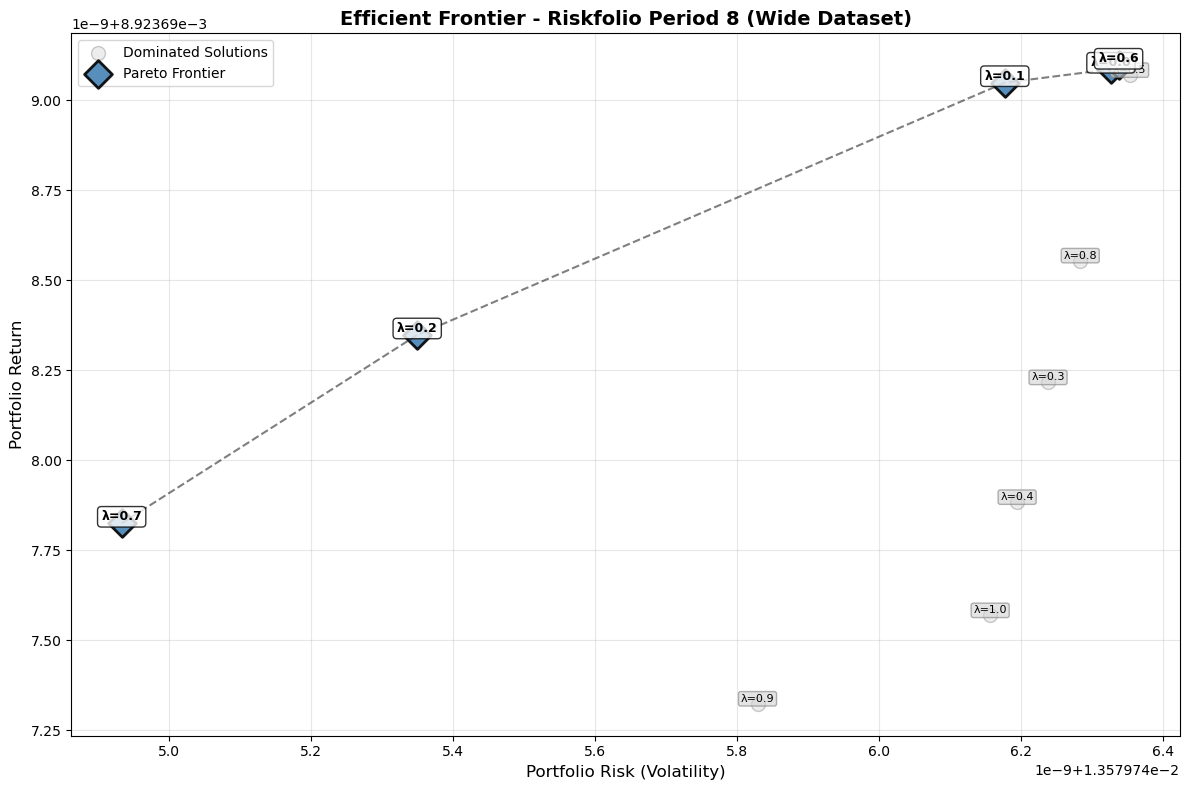


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 5
Efficiency: 45.5%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.700        0.008924     0.013580     0.6571      
0.200        0.008924     0.013580     0.6571      
0.100        0.008924     0.013580     0.6571      
0.000        0.008924     0.013580     0.6571      
0.600        0.008924     0.013580     0.6571      

PERIOD 9 - Riskfolio (Wide Dataset)
Loading existing results for period 9...


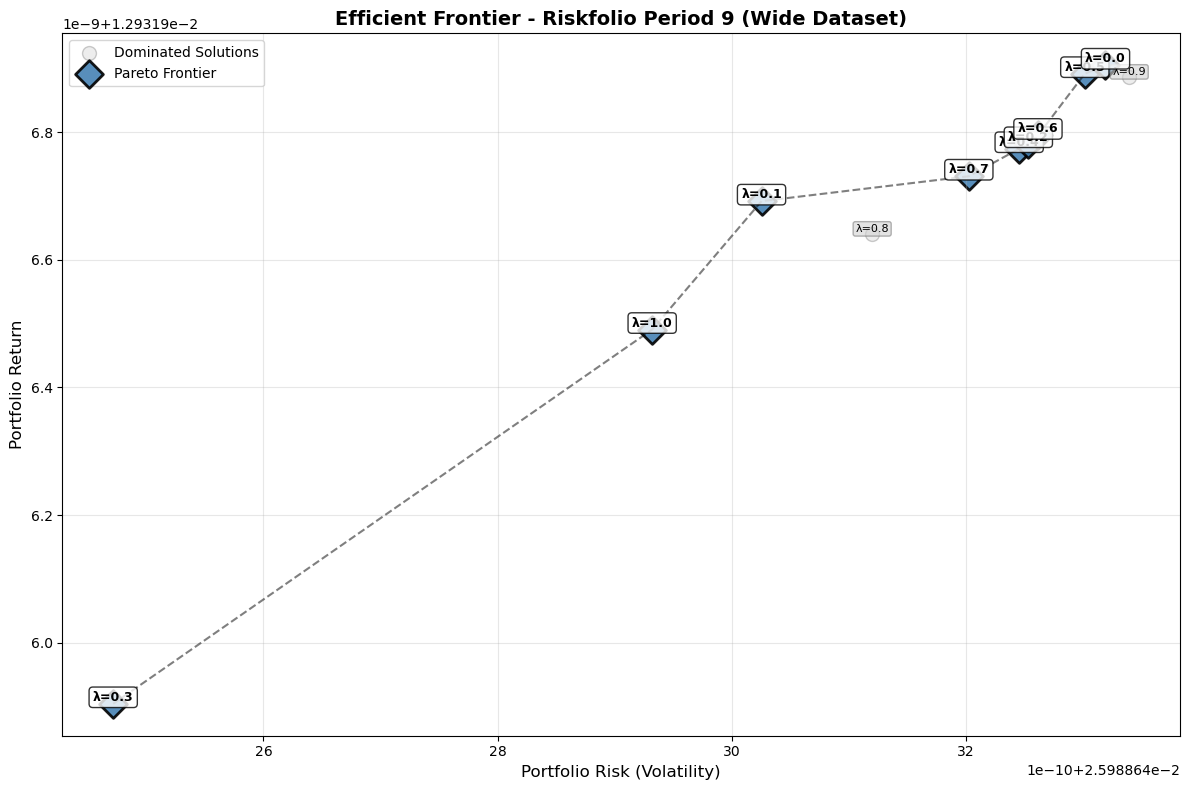


Pareto Frontier Summary:
Total solutions evaluated: 11
Pareto-optimal solutions: 9
Efficiency: 81.8%

Pareto Solutions:
Risk Level   Return       Risk         Sharpe      
------------------------------------------------------------
0.300        0.012932     0.025989     0.4976      
1.000        0.012932     0.025989     0.4976      
0.100        0.012932     0.025989     0.4976      
0.700        0.012932     0.025989     0.4976      
0.400        0.012932     0.025989     0.4976      
0.200        0.012932     0.025989     0.4976      
0.600        0.012932     0.025989     0.4976      
0.500        0.012932     0.025989     0.4976      
0.000        0.012932     0.025989     0.4976      

Riskfolio - Wide Dataset Complete


In [14]:
for period in range(parameters['n_periods']):
    run_pareto_optimization_period(
        period=period,
        solver_name='Riskfolio',
        solver_key='riskfolio',
        optimization_function=riskfolio_qubo,
        data=source_wide,
        benchmark=benchmark,
        results_dict=all_periods_results_wide['riskfolio'],
        parameters=parameters,
        results_base_path=results_base_path
    )

print(f"\n{'='*80}")
print("Riskfolio - Wide Dataset Complete")
print(f"{'='*80}")

### D-Wave CQM - Load Period 0 Results

In [15]:
# Load D-Wave CQM results for period 0 from quantum_portfolio_optimization
all_periods_results_wide['dwave_cqm'] = {}

# Check if D-Wave results exist for period 0
dwave_results_period_0 = {}
for i in range(11):  # Lambda values 0.0 to 1.0
    lambda_str = f"{i:02d}"
    dwave_file = results_base_path + f'pareto_wide_dwave_cqm_lambda_{lambda_str}_period_0.pkl'
    
    if os.path.exists(dwave_file):
        print(f"Loading D-Wave results for lambda {i/10:.1f}...")
        result = read_pickle_dict(dwave_file)
        risk_level = i / 10
        dwave_results_period_0[risk_level] = result
    else:
        print(f"D-Wave results not found for lambda {i/10:.1f}")

if dwave_results_period_0:
    all_periods_results_wide['dwave_cqm'][0] = dwave_results_period_0
    print(f"\n{'='*80}")
    print(f"D-Wave CQM - Period 0 Loaded ({len(dwave_results_period_0)} risk levels)")
    print(f"{'='*80}")
else:
    print("\nNo D-Wave CQM results found for period 0.")
    print("Run quantum_portfolio_optimization notebook first to generate D-Wave results.")

Loading D-Wave results for lambda 0.0...
Loading D-Wave results for lambda 0.1...
Loading D-Wave results for lambda 0.2...
Loading D-Wave results for lambda 0.3...
Loading D-Wave results for lambda 0.4...
Loading D-Wave results for lambda 0.5...
Loading D-Wave results for lambda 0.6...
Loading D-Wave results for lambda 0.7...
Loading D-Wave results for lambda 0.8...
Loading D-Wave results for lambda 0.9...
Loading D-Wave results for lambda 1.0...

D-Wave CQM - Period 0 Loaded (11 risk levels)


### Aggregate Results - Wide Dataset

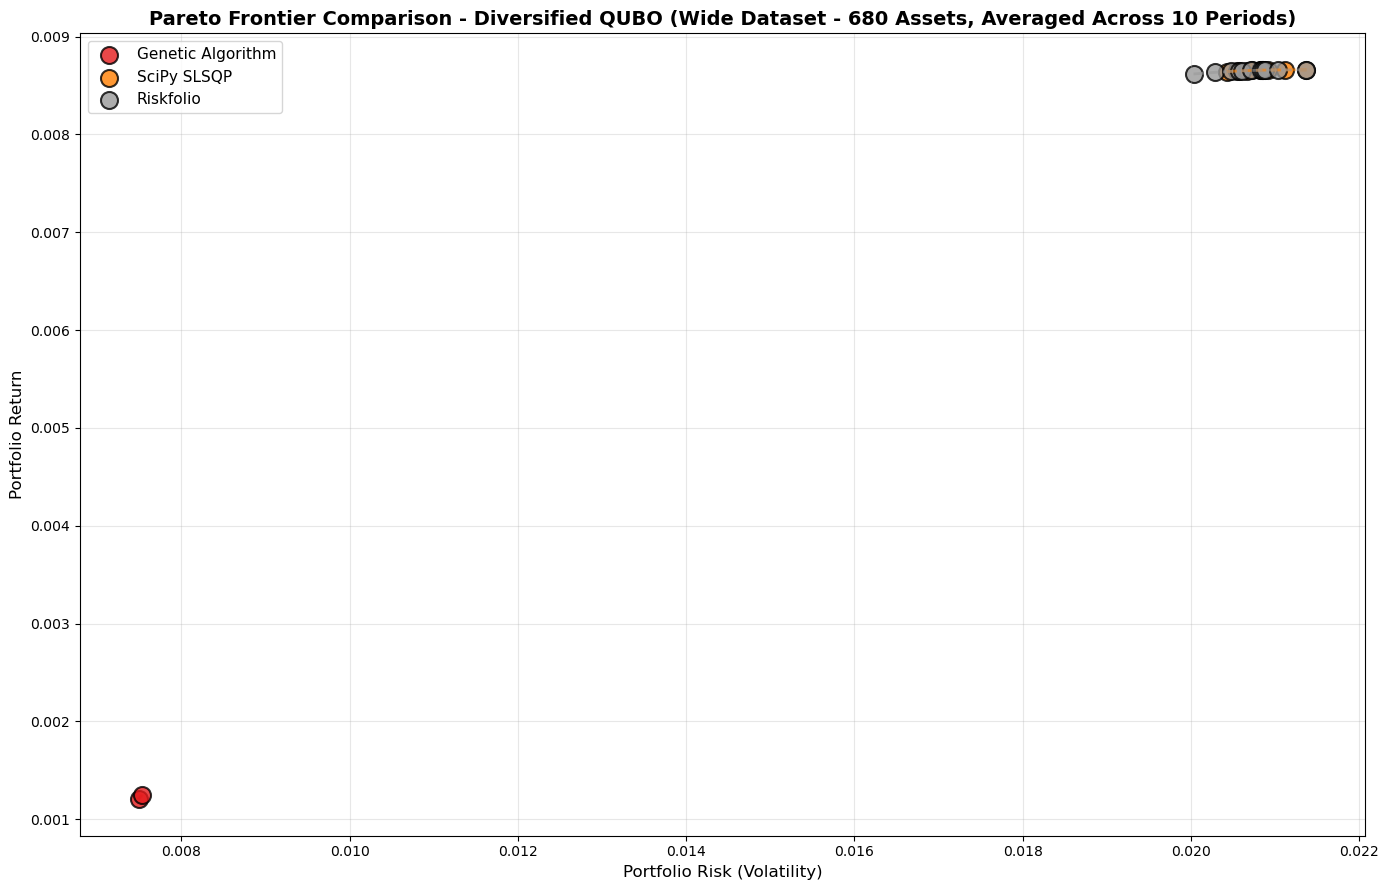


AGGREGATED RESULTS - DIVERSIFIED QUBO (Wide Dataset - 680 Assets)

Genetic Algorithm:
  Valid risk levels: 11/11
  Average execution time: 132.12s

SciPy SLSQP:
  Valid risk levels: 11/11
  Average execution time: 785.35s

Riskfolio:
  Valid risk levels: 11/11
  Average execution time: 2.20s


In [16]:
# Aggregate results across all periods function
def aggregate_results(all_periods_dict):
    """Aggregate results across all periods for a given solver"""
    aggregated = {}
    
    # Get all risk levels from first period
    first_period = list(all_periods_dict.values())[0]
    risk_levels = list(first_period.keys())
    
    for risk_level in risk_levels:
        returns = []
        risks = []
        sharpes = []
        exec_times = []
        
        for period_results in all_periods_dict.values():
            if risk_level in period_results and period_results[risk_level] is not None:
                returns.append(period_results[risk_level]['portfolio_return'])
                risks.append(period_results[risk_level]['portfolio_risk'])
                sharpes.append(period_results[risk_level]['sharpe_ratio'])
                exec_times.append(period_results[risk_level]['execution_time'])
        
        if returns:  # Only create entry if we have data
            aggregated[risk_level] = {
                'portfolio_return': np.mean(returns),
                'portfolio_risk': np.mean(risks),
                'sharpe_ratio': np.mean(sharpes),
                'execution_time': np.mean(exec_times),
                'risk_level': risk_level,
                'return_std': np.std(returns),
                'risk_std': np.std(risks),
                'sharpe_std': np.std(sharpes),
                'n_periods': len(returns)
            }
    
    return aggregated

# Aggregate results for each solver
aggregated_ga_wide = aggregate_results(all_periods_results_wide['genetic_algorithm'])
aggregated_slsqp_wide = aggregate_results(all_periods_results_wide['scipy_slsqp'])
aggregated_riskfolio_wide = aggregate_results(all_periods_results_wide['riskfolio'])

# Plot aggregated Pareto frontiers
frontiers_wide = {
    'Genetic Algorithm': aggregated_ga_wide,
    'SciPy SLSQP': aggregated_slsqp_wide,
    'Riskfolio': aggregated_riskfolio_wide
}

compare_pareto_frontiers(frontiers_wide, title="Pareto Frontier Comparison - Diversified QUBO (Wide Dataset - 680 Assets, Averaged Across 10 Periods)")

# Print summary statistics
print("\n" + "=" * 80)
print("AGGREGATED RESULTS - DIVERSIFIED QUBO (Wide Dataset - 680 Assets)")
print("=" * 80)
for method, results in [('Genetic Algorithm', aggregated_ga_wide), 
                        ('SciPy SLSQP', aggregated_slsqp_wide),
                        ('Riskfolio', aggregated_riskfolio_wide)]:
    print(f"\n{method}:")
    if results:
        print(f"  Valid risk levels: {len(results)}/{len(parameters['risk_levels'])}")
        print(f"  Average execution time: {np.mean([r['execution_time'] for r in results.values()]):.2f}s")
    else:
        print("  No valid results")
print("=" * 80)

In [17]:
# Plot weight evolution for aggregated SLSQP results
pareto_slsqp_wide = extract_pareto_frontier(aggregated_slsqp_wide)
if pareto_slsqp_wide:
    print(f"Pareto-optimal solutions (SLSQP - Wide): {len(pareto_slsqp_wide)}")
else:
    print("No Pareto-optimal solutions found for SLSQP (Wide Dataset)")

Pareto-optimal solutions (SLSQP - Wide): 11


## Summary and Insights

In [18]:
print("=" * 80)
print("PARETO FRONTIER ANALYSIS SUMMARY - DIVERSIFIED QUBO")
print("=" * 80)

print(f"\nAnalysis Configuration:")
print(f"  Optimization Type: Diversified (Restricted) QUBO")
print(f"  Number of periods: {parameters['n_periods']}")
print(f"  Days for averaging: {parameters['days_to_avg']}")
print(f"  Days for optimization/testing: {parameters['days_to_opt']}")
print(f"  Budget constraint: ${parameters['budget']:,.0f}")
print(f"  Risk levels tested: {parameters['risk_levels']}")

print("\nWide Dataset (680 Assets - Stocks + ETFs):")
for method, results in frontiers_wide.items():
    pareto = extract_pareto_frontier(results)
    print(f"  {method}: {len(pareto)} Pareto-optimal solutions (averaged across periods)")


PARETO FRONTIER ANALYSIS SUMMARY - DIVERSIFIED QUBO

Analysis Configuration:
  Optimization Type: Diversified (Restricted) QUBO
  Number of periods: 10
  Days for averaging: 30
  Days for optimization/testing: 30
  Budget constraint: $1,000,000
  Risk levels tested: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

Wide Dataset (680 Assets - Stocks + ETFs):
  Genetic Algorithm: 2 Pareto-optimal solutions (averaged across periods)
  SciPy SLSQP: 11 Pareto-optimal solutions (averaged across periods)
  Riskfolio: 11 Pareto-optimal solutions (averaged across periods)


## Comprehensive Solver Comparison Across All Periods


SOLVER PERFORMANCE COMPARISON - ALL PERIODS
           Solver  Avg Return  Avg Risk  Avg Sharpe  Avg Exec Time (s)  Avg Pareto Points  Total Solutions  Std Return  Std Risk  Std Sharpe
Genetic Algorithm    0.001203  0.007556    0.174988         132.116223                3.2              110    0.000843  0.001950    0.125913
      Scipy Slsqp    0.008655  0.020832    0.453381         785.354608               10.1              110    0.002061  0.006818    0.148335
        Riskfolio    0.008649  0.020696    0.455375           2.201127                9.1              110    0.002064  0.006789    0.147331
        Dwave Cqm    0.000407  0.002938    0.065483        6398.934063                4.0               11    0.001045  0.002805    0.085591


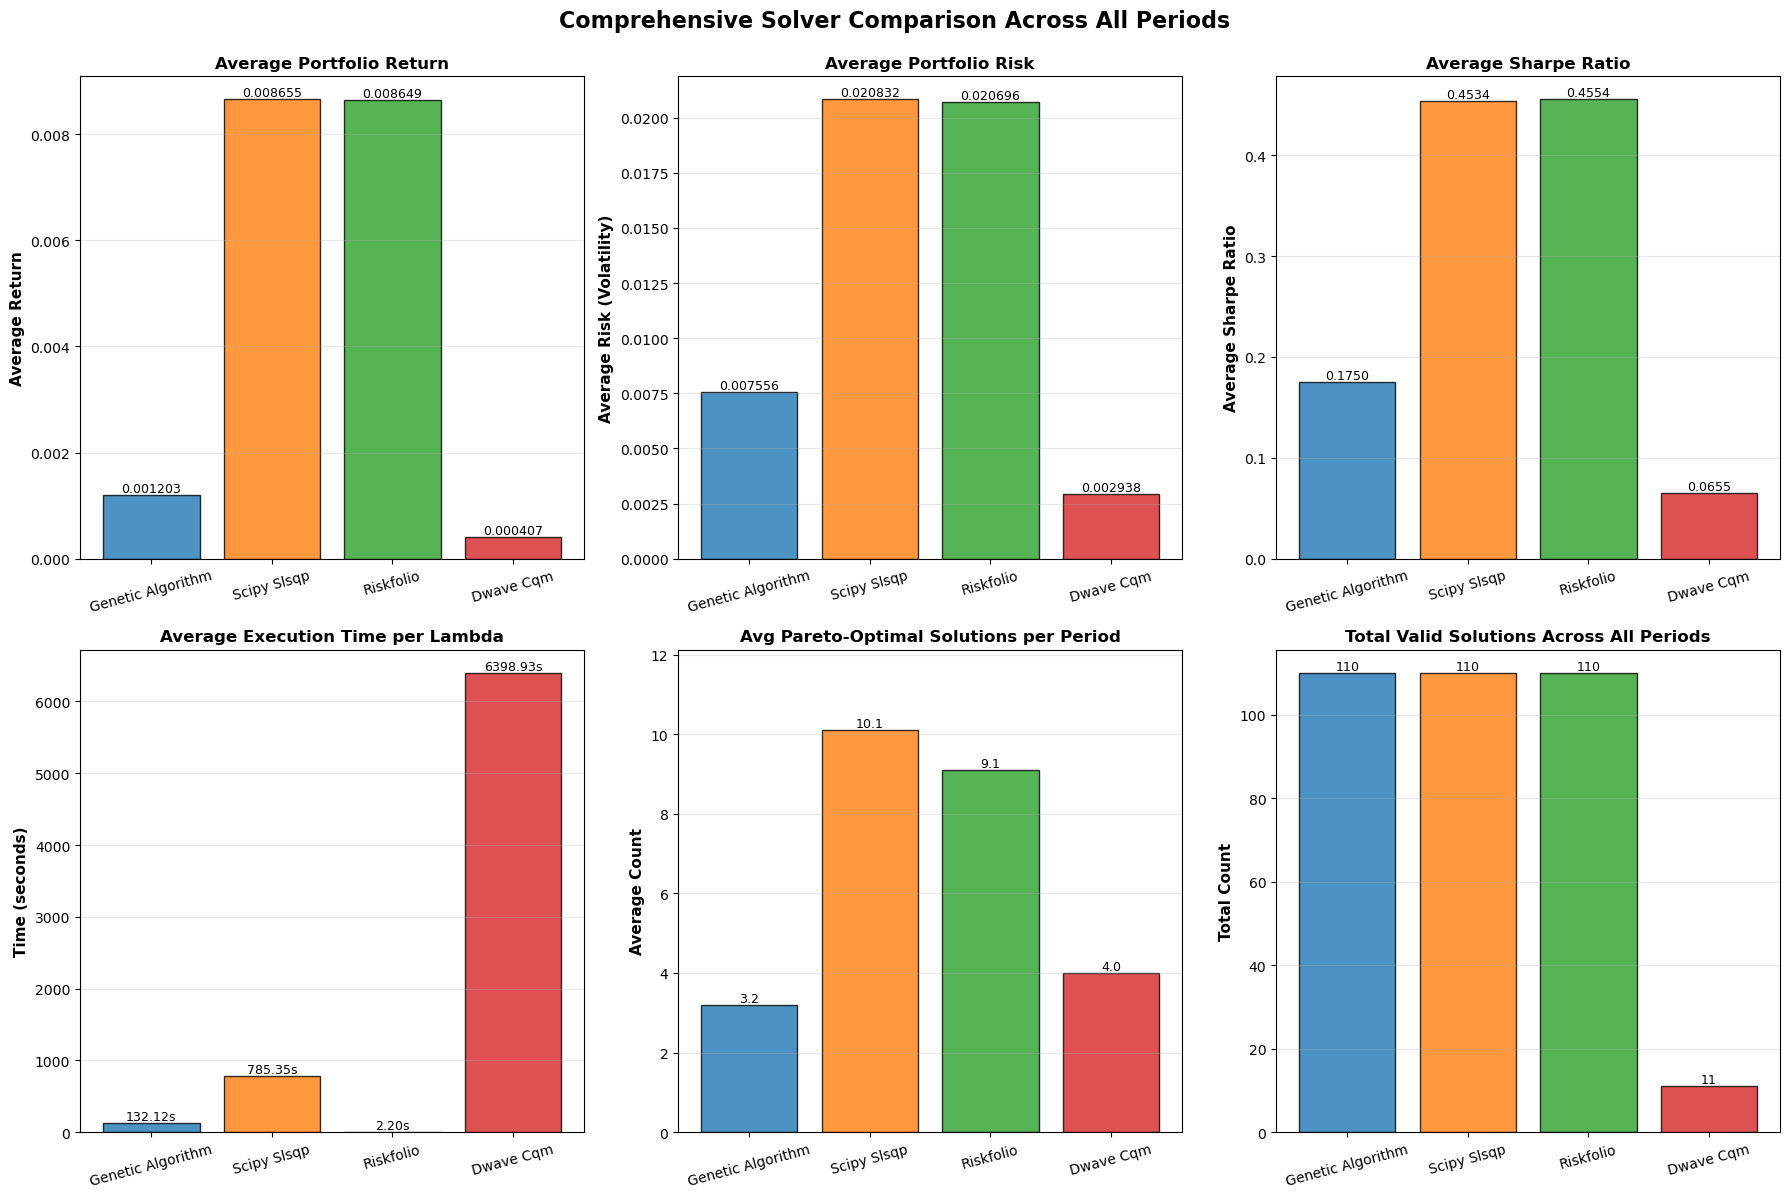


SOLVER CONSISTENCY ANALYSIS
Solver               Std Return      Std Risk        Std Sharpe     
--------------------------------------------------------------------------------
Genetic Algorithm    0.000843        0.001950        0.125913       
Scipy Slsqp          0.002061        0.006818        0.148335       
Riskfolio            0.002064        0.006789        0.147331       
Dwave Cqm            0.001045        0.002805        0.085591       
Lower standard deviation indicates more consistent performance across periods.


In [19]:
# Comprehensive comparison of all solvers across all periods
def compute_solver_statistics(all_periods_results):
    """
    Compute comprehensive statistics for each solver across all periods.
    
    Returns:
        DataFrame with statistics for each solver
    """
    stats = []
    
    for solver_name, periods_dict in all_periods_results.items():
        all_returns = []
        all_risks = []
        all_sharpes = []
        all_exec_times = []
        pareto_counts = []
        
        for period_idx, period_results in periods_dict.items():
            # Extract Pareto frontier for this period
            pareto = extract_pareto_frontier(period_results)
            pareto_counts.append(len(pareto))
            
            # Collect metrics from all valid results
            for risk_level, result in period_results.items():
                if result is not None and 'portfolio_return' in result:
                    all_returns.append(result['portfolio_return'])
                    all_risks.append(result['portfolio_risk'])
                    all_sharpes.append(result['sharpe_ratio'])
                    all_exec_times.append(result['execution_time'])
        
        stats.append({
            'Solver': solver_name.replace('_', ' ').title(),
            'Avg Return': np.mean(all_returns) if all_returns else 0,
            'Avg Risk': np.mean(all_risks) if all_risks else 0,
            'Avg Sharpe': np.mean(all_sharpes) if all_sharpes else 0,
            'Avg Exec Time (s)': np.mean(all_exec_times) if all_exec_times else 0,
            'Avg Pareto Points': np.mean(pareto_counts) if pareto_counts else 0,
            'Total Solutions': len(all_returns),
            'Std Return': np.std(all_returns) if all_returns else 0,
            'Std Risk': np.std(all_risks) if all_risks else 0,
            'Std Sharpe': np.std(all_sharpes) if all_sharpes else 0
        })
    
    return pd.DataFrame(stats)

# Compute statistics
solver_stats = compute_solver_statistics(all_periods_results_wide)

print("\n" + "="*80)
print("SOLVER PERFORMANCE COMPARISON - ALL PERIODS")
print("="*80)
print(solver_stats.to_string(index=False))
print("="*80)

# Create comprehensive bar plot comparison
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Comprehensive Solver Comparison Across All Periods', fontsize=16, fontweight='bold', y=0.995)

solvers = solver_stats['Solver'].values
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

# 1. Average Return
ax1 = axes[0, 0]
bars1 = ax1.bar(solvers, solver_stats['Avg Return'], color=colors, alpha=0.8, edgecolor='black')
ax1.set_ylabel('Average Return', fontsize=11, fontweight='bold')
ax1.set_title('Average Portfolio Return', fontsize=12, fontweight='bold')
ax1.tick_params(axis='x', rotation=15)
ax1.grid(True, alpha=0.3, axis='y')
for bar in bars1:
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.6f}', ha='center', va='bottom', fontsize=9)

# 2. Average Risk
ax2 = axes[0, 1]
bars2 = ax2.bar(solvers, solver_stats['Avg Risk'], color=colors, alpha=0.8, edgecolor='black')
ax2.set_ylabel('Average Risk (Volatility)', fontsize=11, fontweight='bold')
ax2.set_title('Average Portfolio Risk', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)
ax2.grid(True, alpha=0.3, axis='y')
for bar in bars2:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.6f}', ha='center', va='bottom', fontsize=9)

# 3. Average Sharpe Ratio
ax3 = axes[0, 2]
bars3 = ax3.bar(solvers, solver_stats['Avg Sharpe'], color=colors, alpha=0.8, edgecolor='black')
ax3.set_ylabel('Average Sharpe Ratio', fontsize=11, fontweight='bold')
ax3.set_title('Average Sharpe Ratio', fontsize=12, fontweight='bold')
ax3.tick_params(axis='x', rotation=15)
ax3.grid(True, alpha=0.3, axis='y')
for bar in bars3:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=9)

# 4. Average Execution Time
ax4 = axes[1, 0]
bars4 = ax4.bar(solvers, solver_stats['Avg Exec Time (s)'], color=colors, alpha=0.8, edgecolor='black')
ax4.set_ylabel('Time (seconds)', fontsize=11, fontweight='bold')
ax4.set_title('Average Execution Time per Lambda', fontsize=12, fontweight='bold')
ax4.tick_params(axis='x', rotation=15)
ax4.grid(True, alpha=0.3, axis='y')
for bar in bars4:
    height = bar.get_height()
    ax4.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.2f}s', ha='center', va='bottom', fontsize=9)

# 5. Average Pareto Points per Period
ax5 = axes[1, 1]
bars5 = ax5.bar(solvers, solver_stats['Avg Pareto Points'], color=colors, alpha=0.8, edgecolor='black')
ax5.set_ylabel('Average Count', fontsize=11, fontweight='bold')
ax5.set_title('Avg Pareto-Optimal Solutions per Period', fontsize=12, fontweight='bold')
ax5.tick_params(axis='x', rotation=15)
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_ylim([0, max(solver_stats['Avg Pareto Points']) * 1.2])
for bar in bars5:
    height = bar.get_height()
    ax5.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.1f}', ha='center', va='bottom', fontsize=9)

# 6. Total Solutions Found
ax6 = axes[1, 2]
bars6 = ax6.bar(solvers, solver_stats['Total Solutions'], color=colors, alpha=0.8, edgecolor='black')
ax6.set_ylabel('Total Count', fontsize=11, fontweight='bold')
ax6.set_title('Total Valid Solutions Across All Periods', fontsize=12, fontweight='bold')
ax6.tick_params(axis='x', rotation=15)
ax6.grid(True, alpha=0.3, axis='y')
for bar in bars6:
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(height)}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Additional analysis: Consistency across periods
print("\n" + "="*80)
print("SOLVER CONSISTENCY ANALYSIS")
print("="*80)
print(f"{'Solver':<20} {'Std Return':<15} {'Std Risk':<15} {'Std Sharpe':<15}")
print("-"*80)
for _, row in solver_stats.iterrows():
    print(f"{row['Solver']:<20} {row['Std Return']:<15.6f} {row['Std Risk']:<15.6f} {row['Std Sharpe']:<15.6f}")
print("="*80)
print("Lower standard deviation indicates more consistent performance across periods.")


### Normalized Sharpe Ratio Comparison Per Period

### Unnormalized Efficient Frontiers Per Period

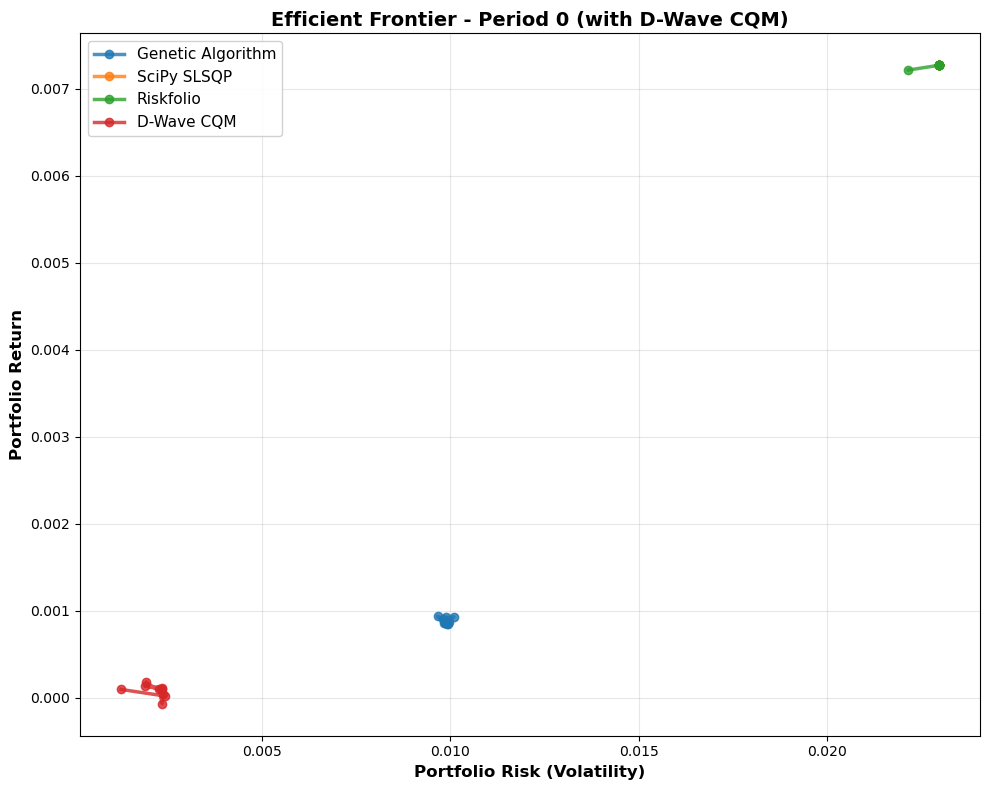

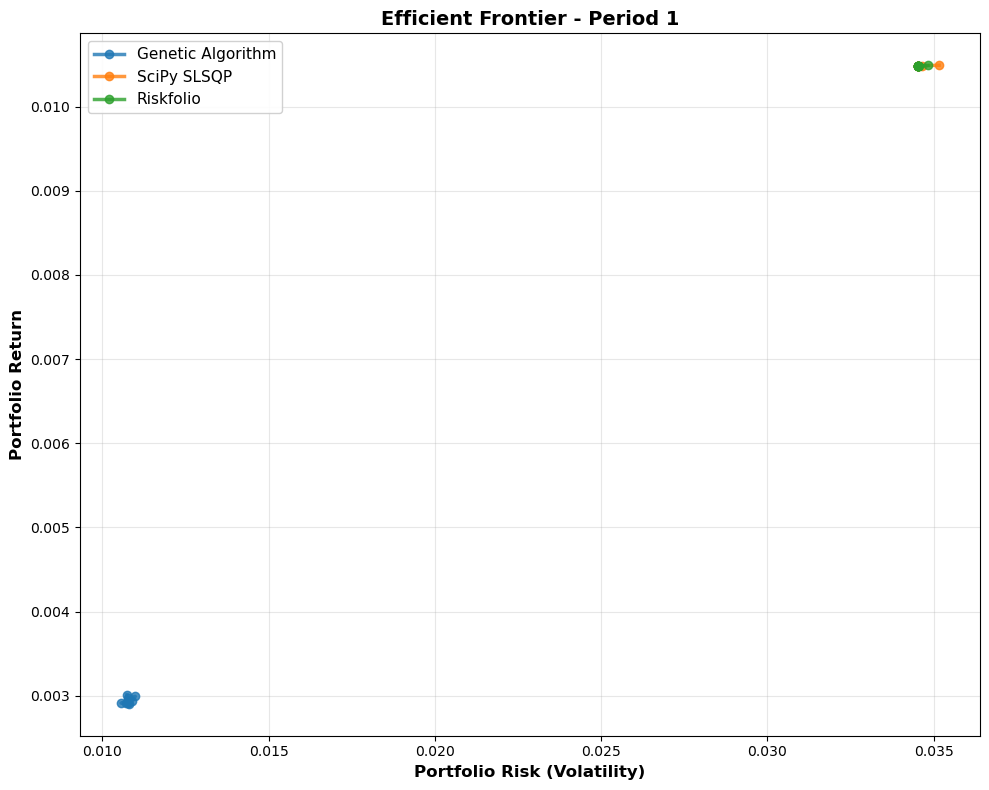

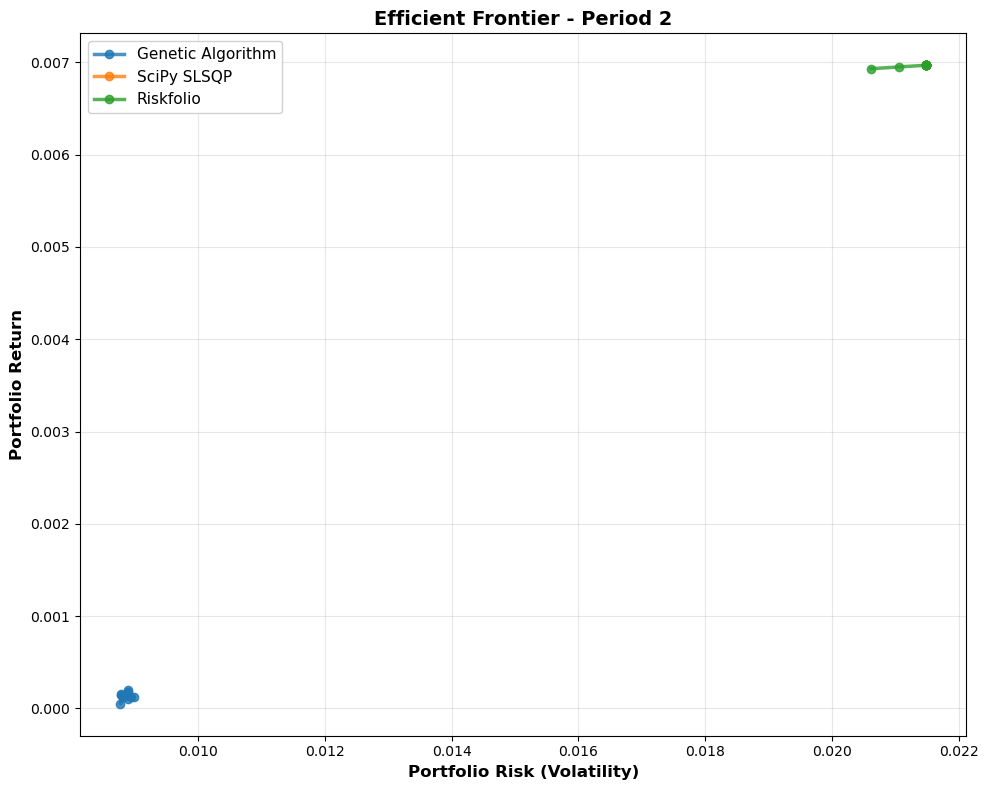

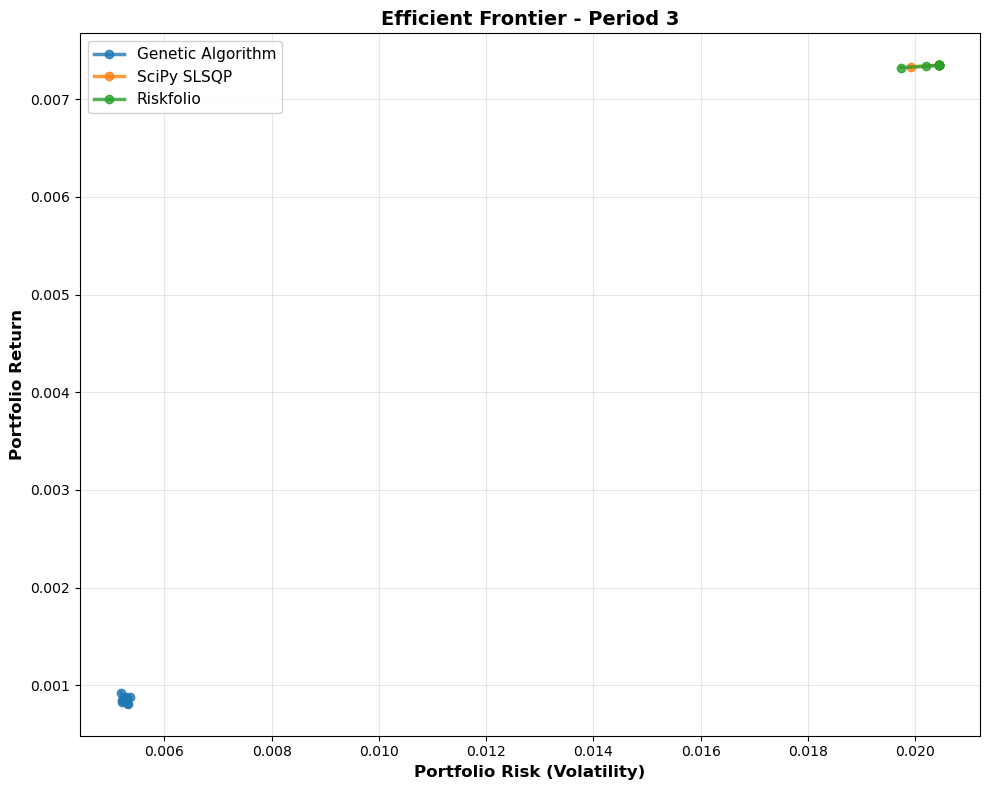

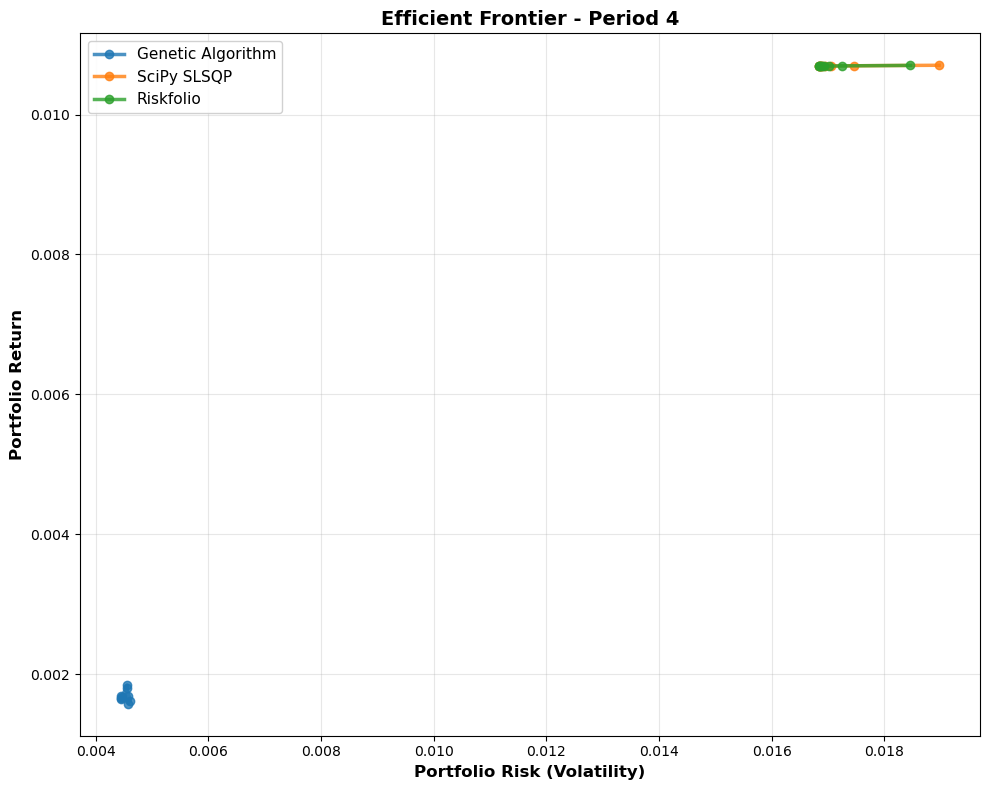

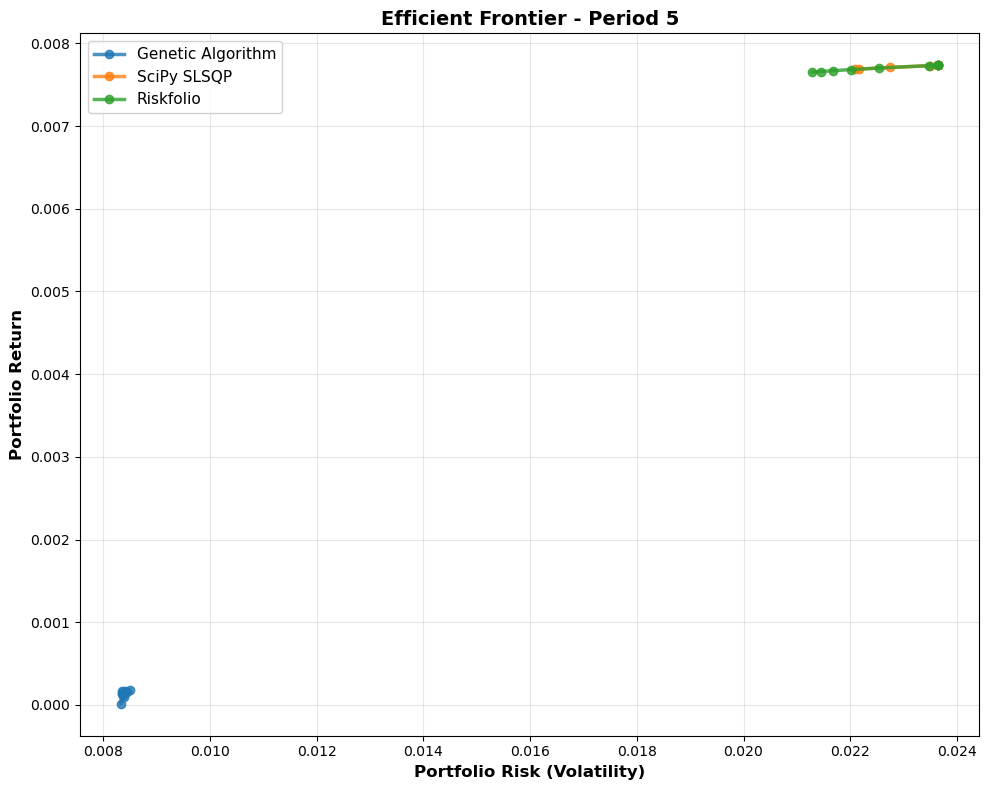

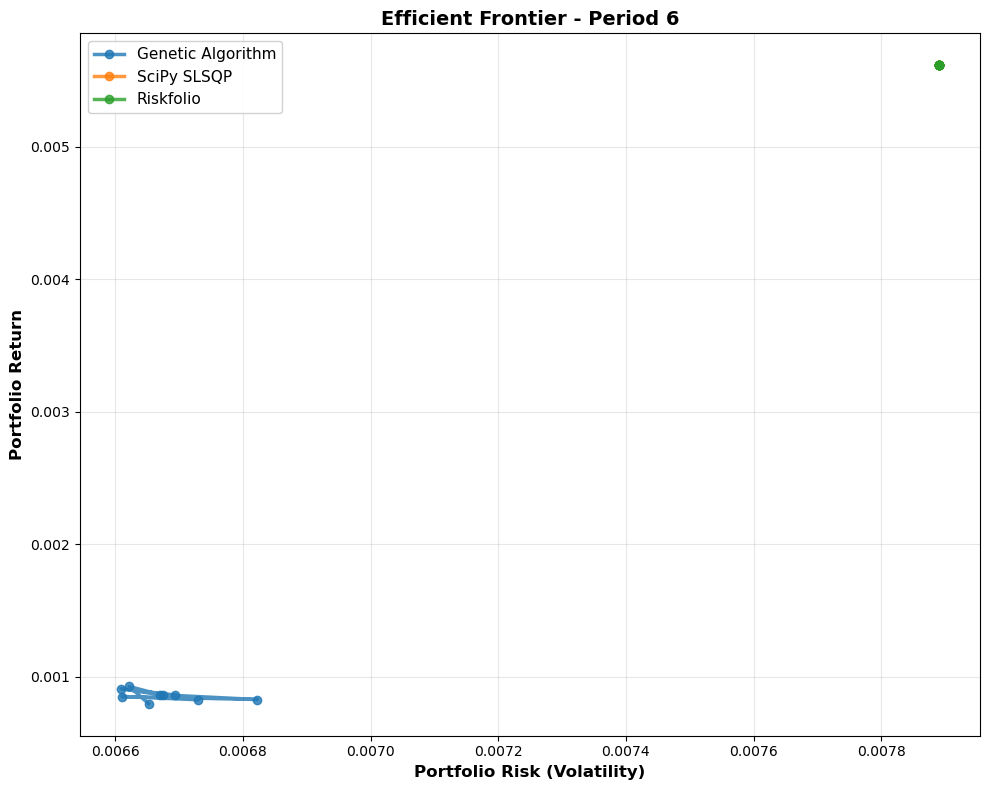

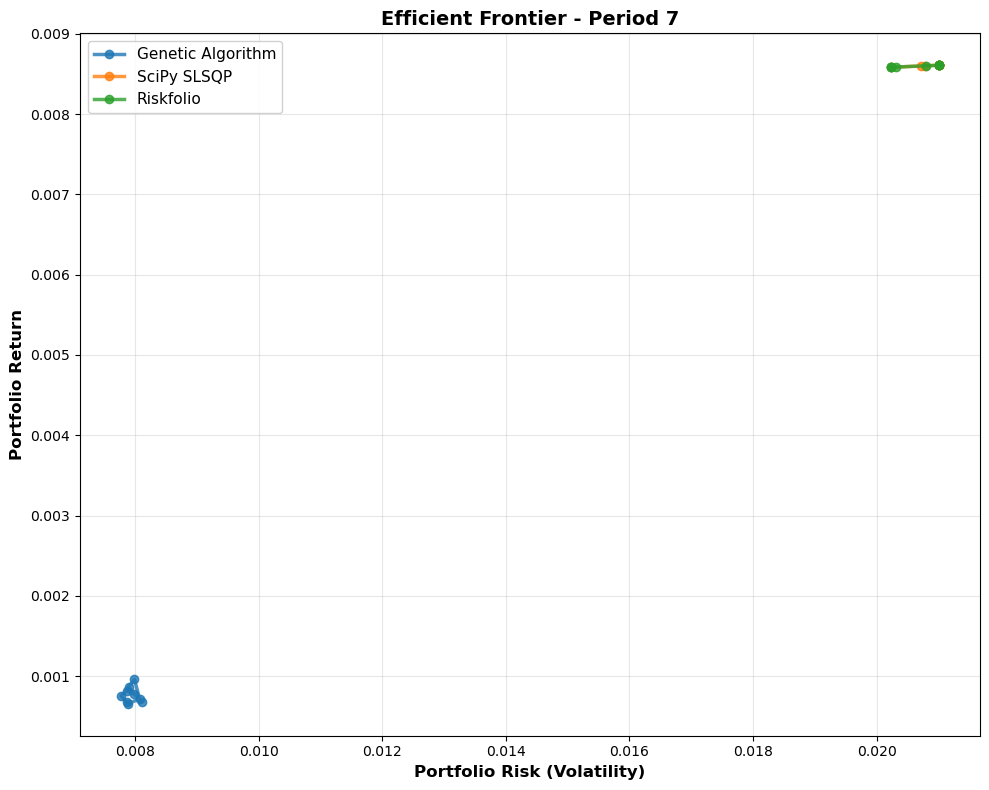

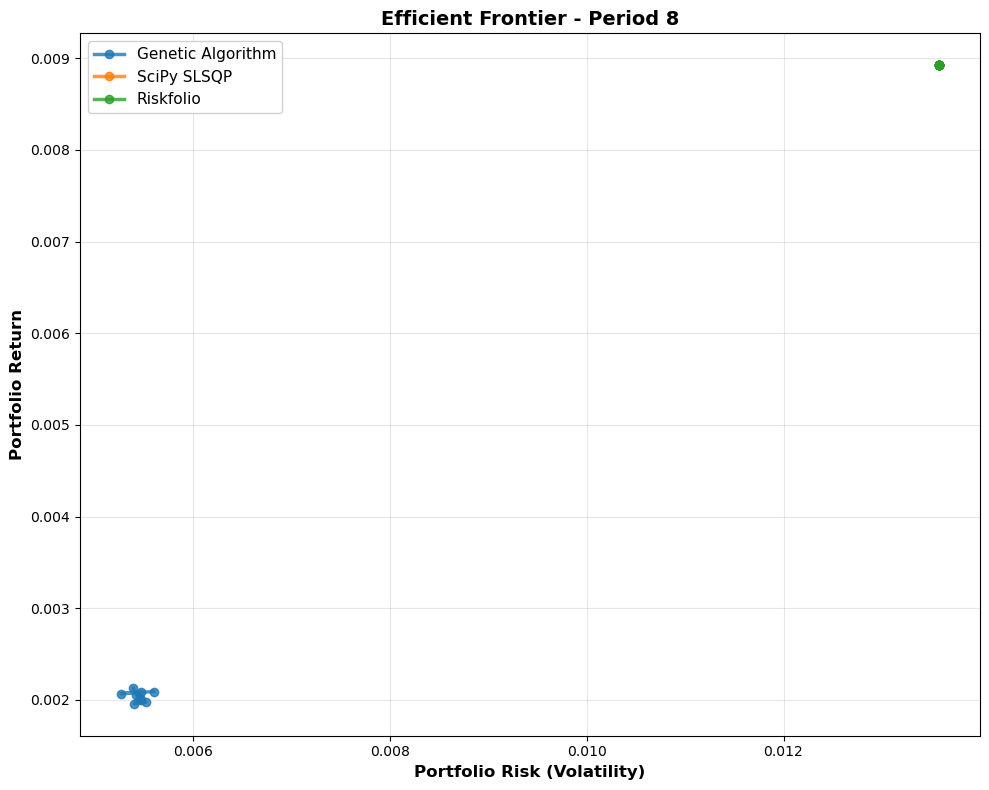

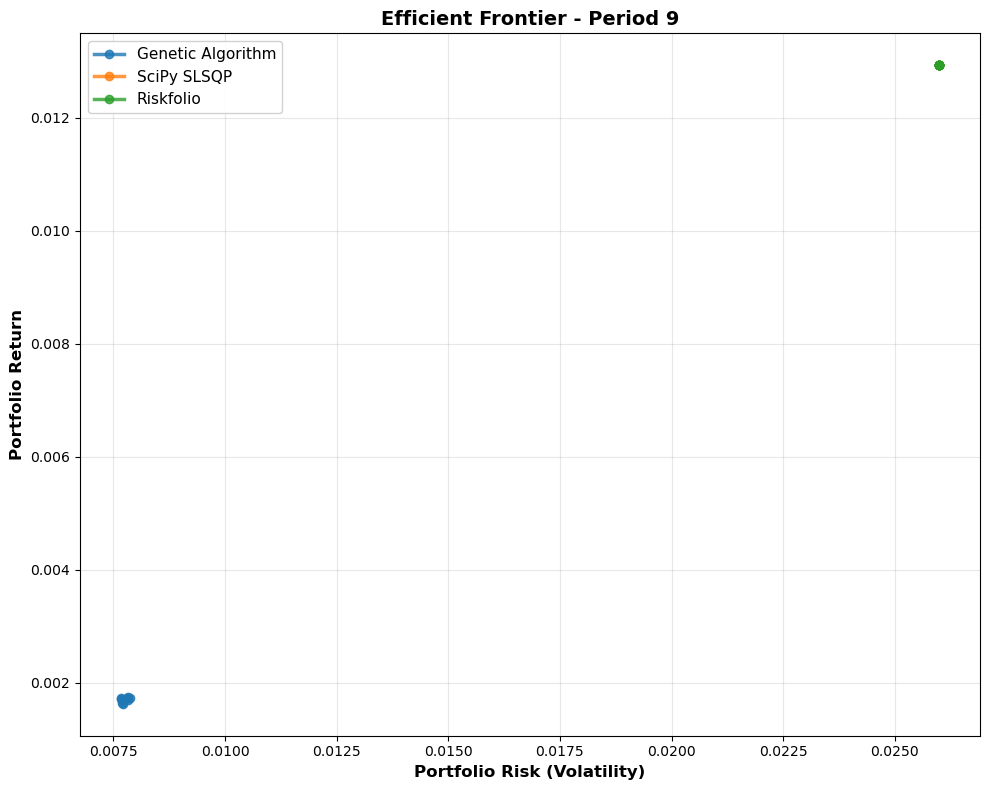


UNNORMALIZED EFFICIENT FRONTIERS
Generated 10 individual plots showing actual efficient frontiers.
These plots show the actual risk-return tradeoffs achieved by each solver
for each period, without normalization.
Note: Lambda values 0.0 and 1.0 are excluded from the plots.


In [20]:
# Plot unnormalized efficient frontiers for each period
# Define colors and labels
colors_map = {
    'genetic_algorithm': '#1f77b4', 
    'scipy_slsqp': '#ff7f0e', 
    'riskfolio': '#2ca02c',
    'dwave_cqm': '#d62728'
}
labels_map = {
    'genetic_algorithm': 'Genetic Algorithm', 
    'scipy_slsqp': 'SciPy SLSQP', 
    'riskfolio': 'Riskfolio',
    'dwave_cqm': 'D-Wave CQM'
}

# Get number of periods
n_periods = parameters['n_periods']

# Create one figure per period showing actual (unnormalized) efficient frontiers
for period_idx in range(n_periods):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Get solvers for this period (exclude dwave_cqm if not present)
    solver_names = [k for k in all_periods_results_wide.keys() if k != 'dwave_cqm' or period_idx in all_periods_results_wide.get(k, {})]
    
    # Plot each solver
    for solver_name in solver_names:
        if period_idx in all_periods_results_wide[solver_name]:
            period_results = all_periods_results_wide[solver_name][period_idx]
            
            returns = []
            risks = []
            
            for risk_level in sorted(period_results.keys()):
                # Skip lambda = 0.0 and lambda = 1.0
                if risk_level in [0.0, 1.0]:
                    continue
                    
                result = period_results[risk_level]
                if result is not None and 'portfolio_return' in result:
                    returns.append(result['portfolio_return'])
                    risks.append(result['portfolio_risk'])
            
            if returns:
                ax.plot(risks, returns, 
                       marker='o', linewidth=2.5, markersize=6,
                       label=labels_map.get(solver_name, solver_name),
                       color=colors_map.get(solver_name, '#666666'),
                       alpha=0.8)
    
    ax.set_xlabel('Portfolio Risk (Volatility)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Portfolio Return', fontsize=12, fontweight='bold')
    
    title = f'Efficient Frontier - Period {period_idx}'
    if period_idx == 0 and 'dwave_cqm' in all_periods_results_wide and 0 in all_periods_results_wide['dwave_cqm']:
        title += ' (with D-Wave CQM)'
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("UNNORMALIZED EFFICIENT FRONTIERS")
print("="*80)
print(f"Generated {n_periods} individual plots showing actual efficient frontiers.")
print("These plots show the actual risk-return tradeoffs achieved by each solver")
print("for each period, without normalization.")
print("Note: Lambda values 0.0 and 1.0 are excluded from the plots.")
print("="*80)


Global normalization ranges:
  Returns: [-0.000069, 0.012932]
  Risks: [0.001263, 0.035164]


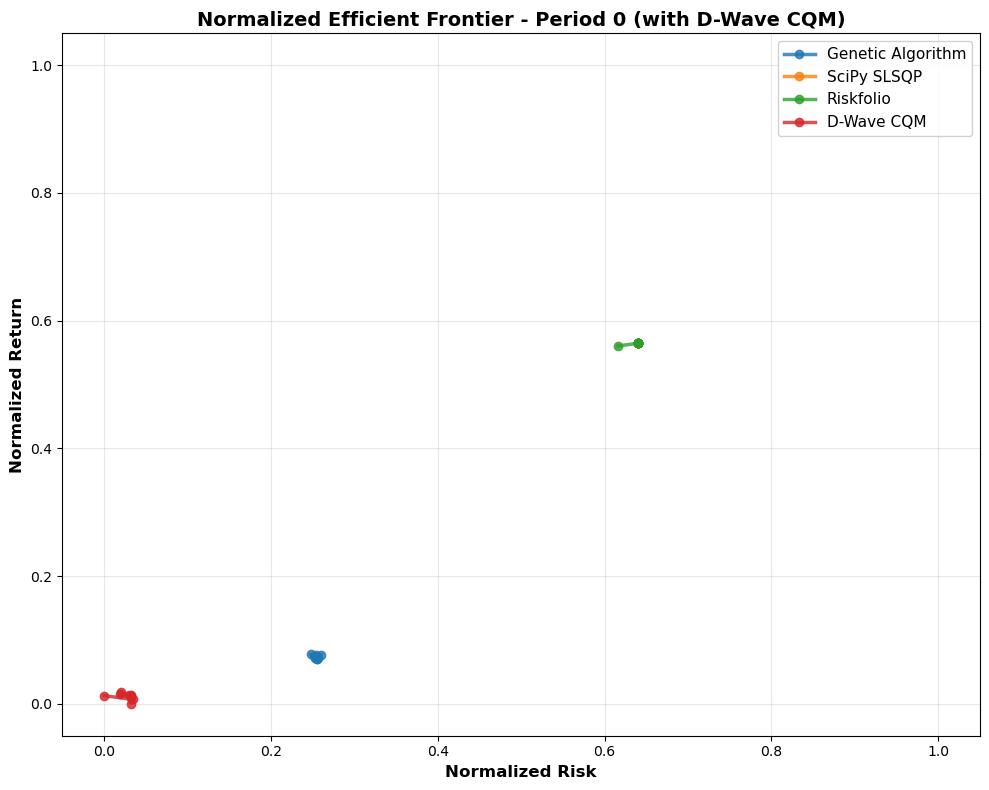

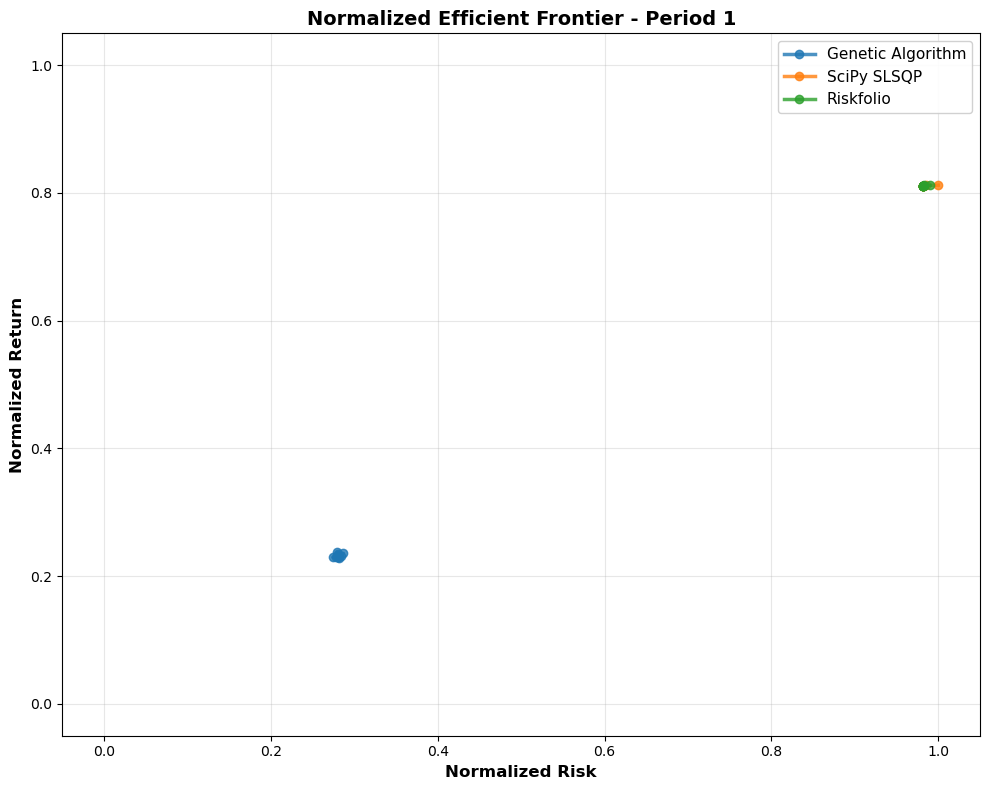

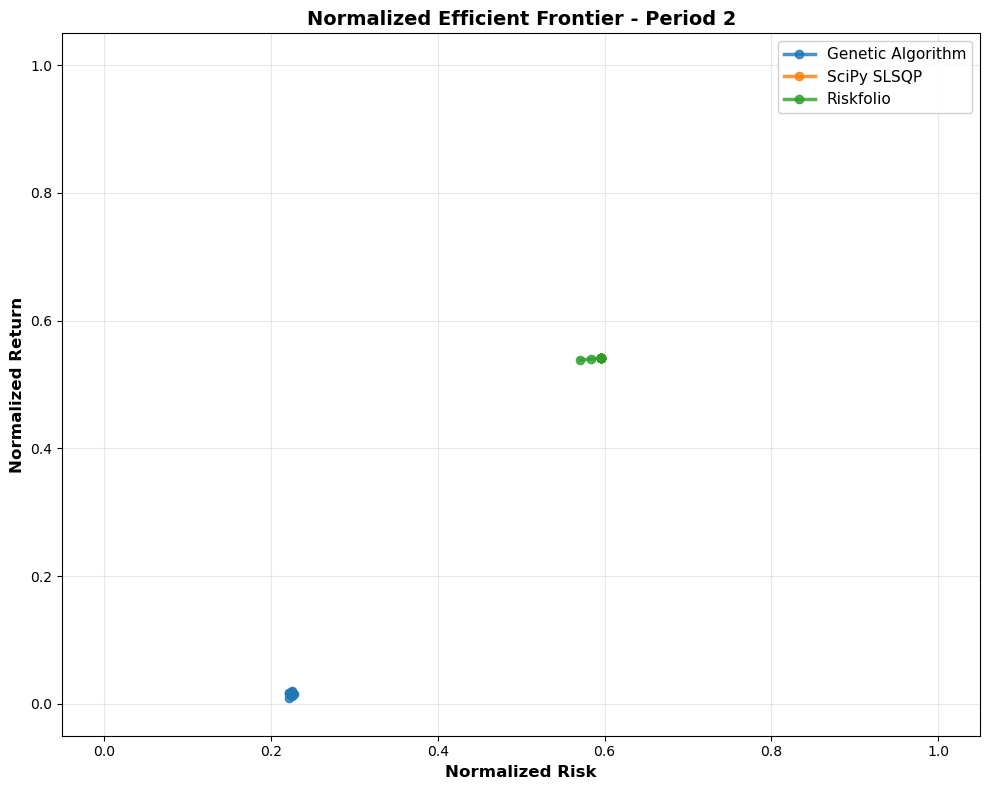

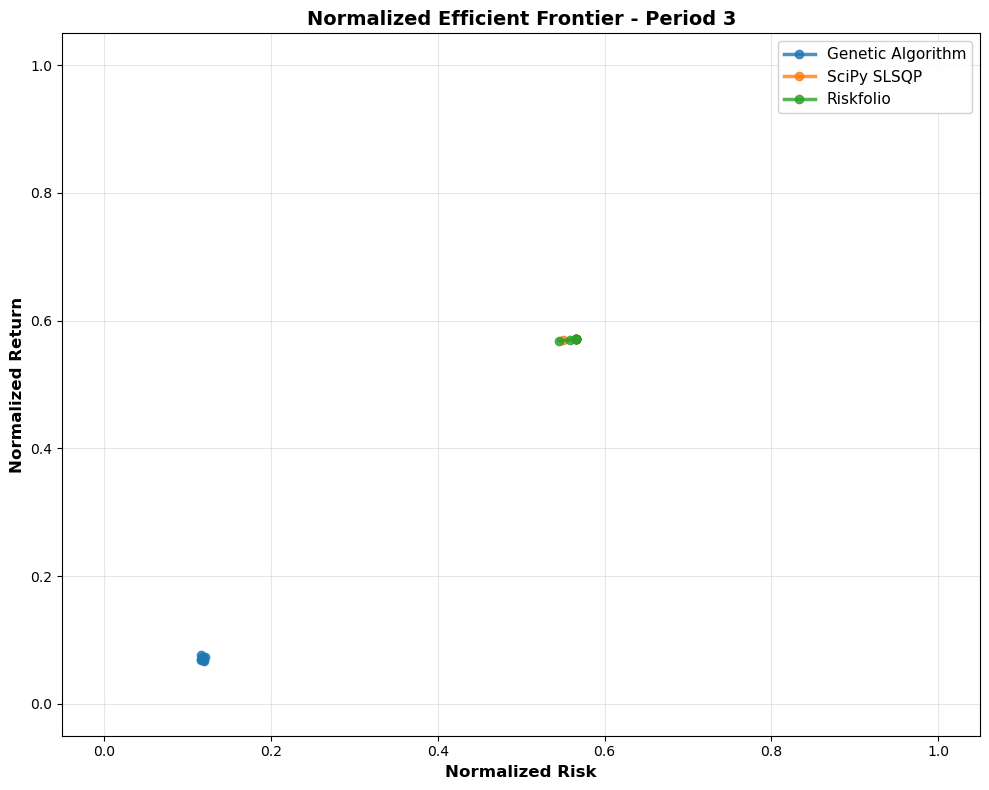

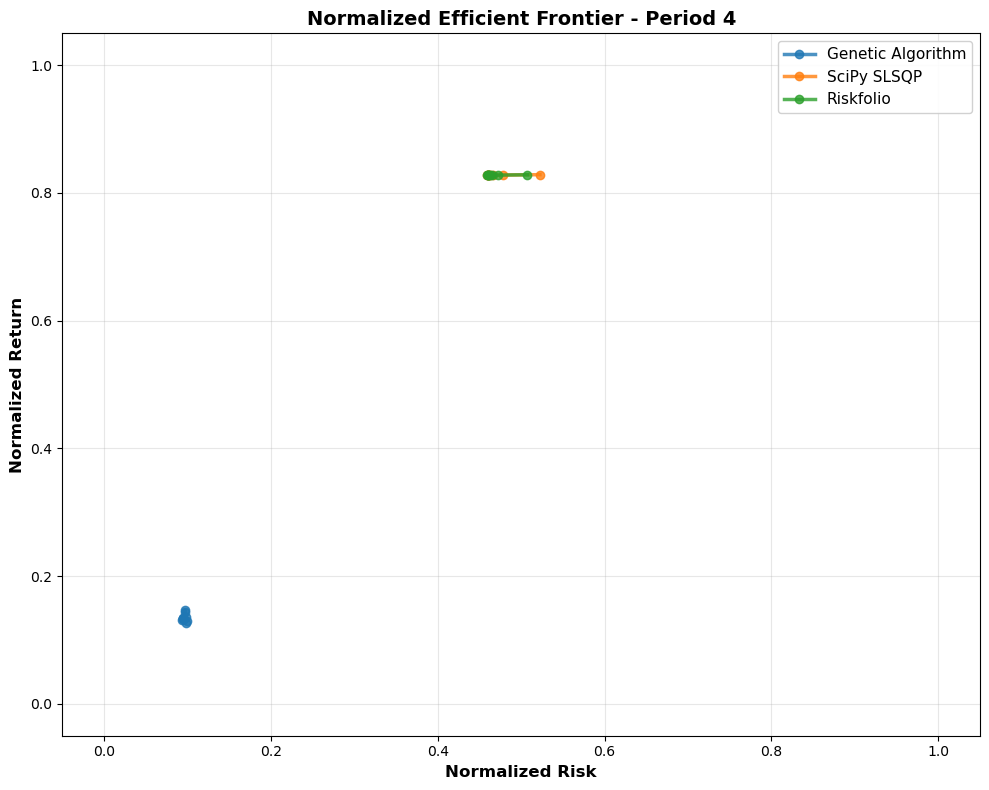

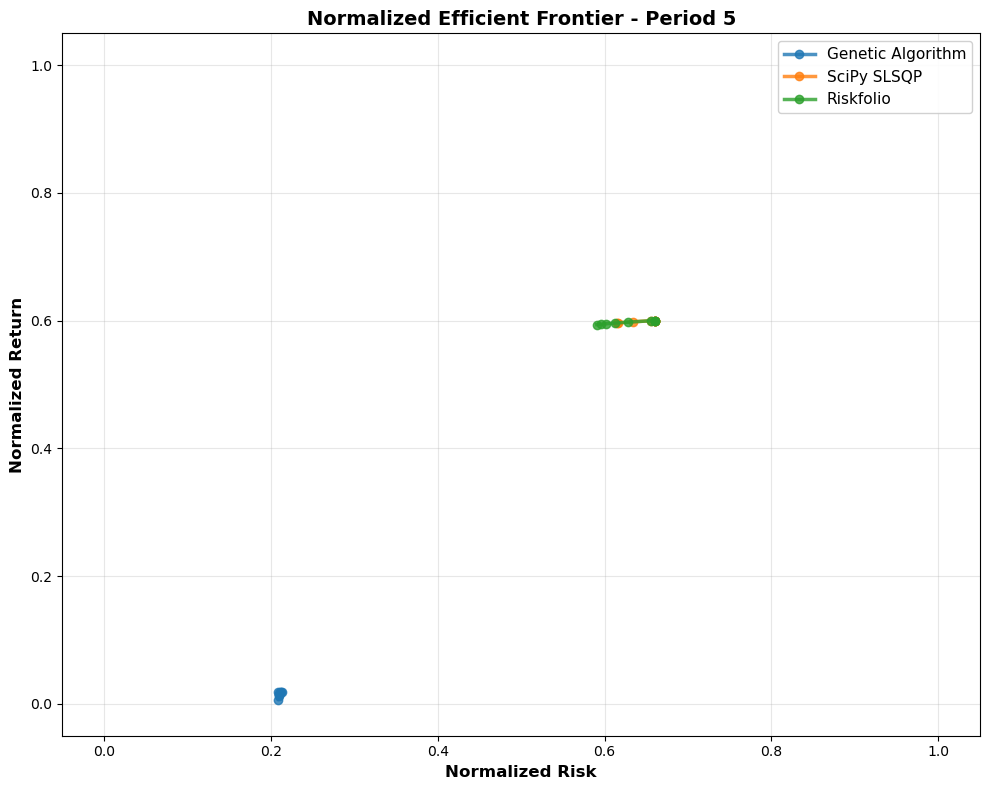

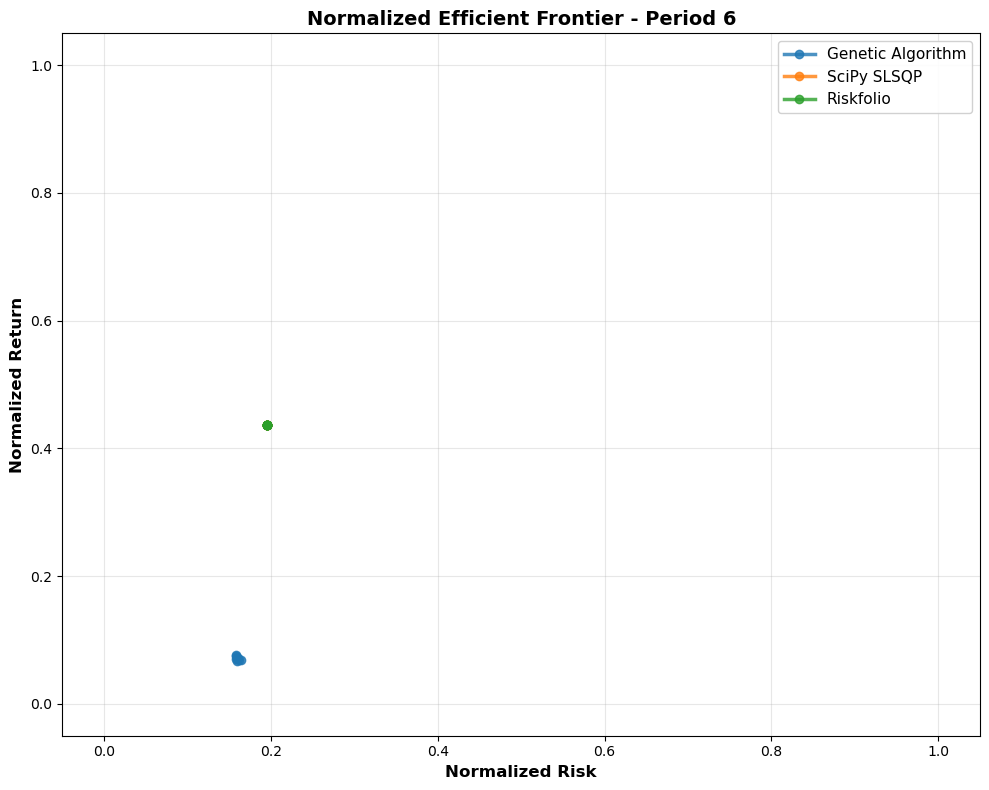

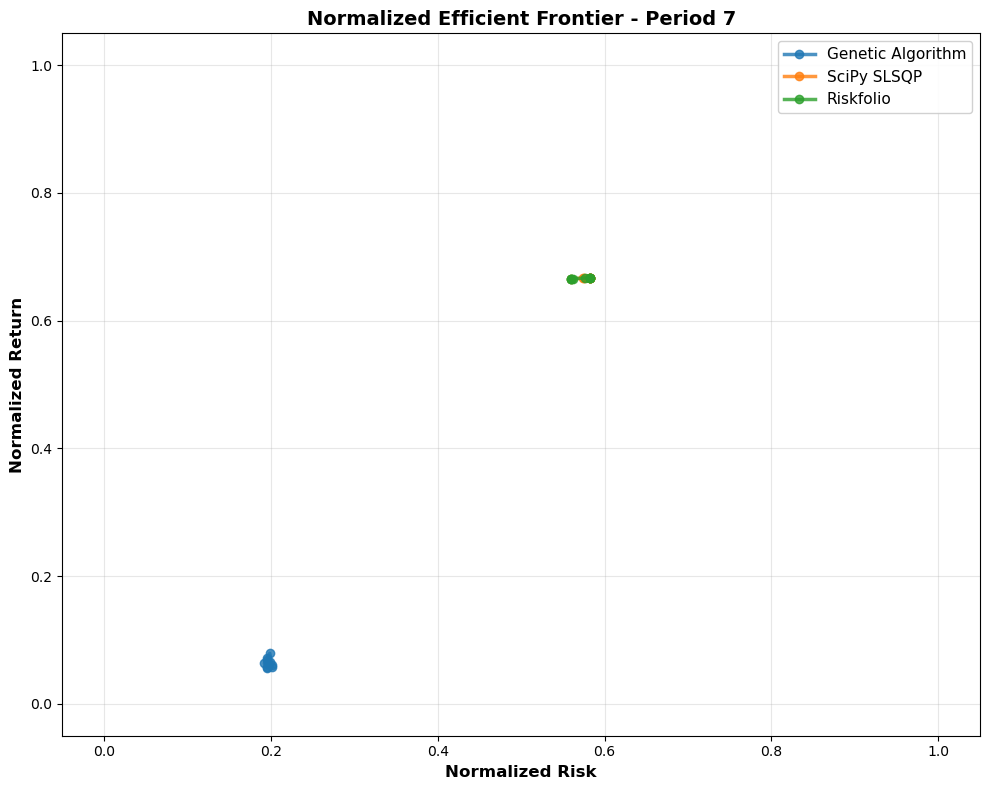

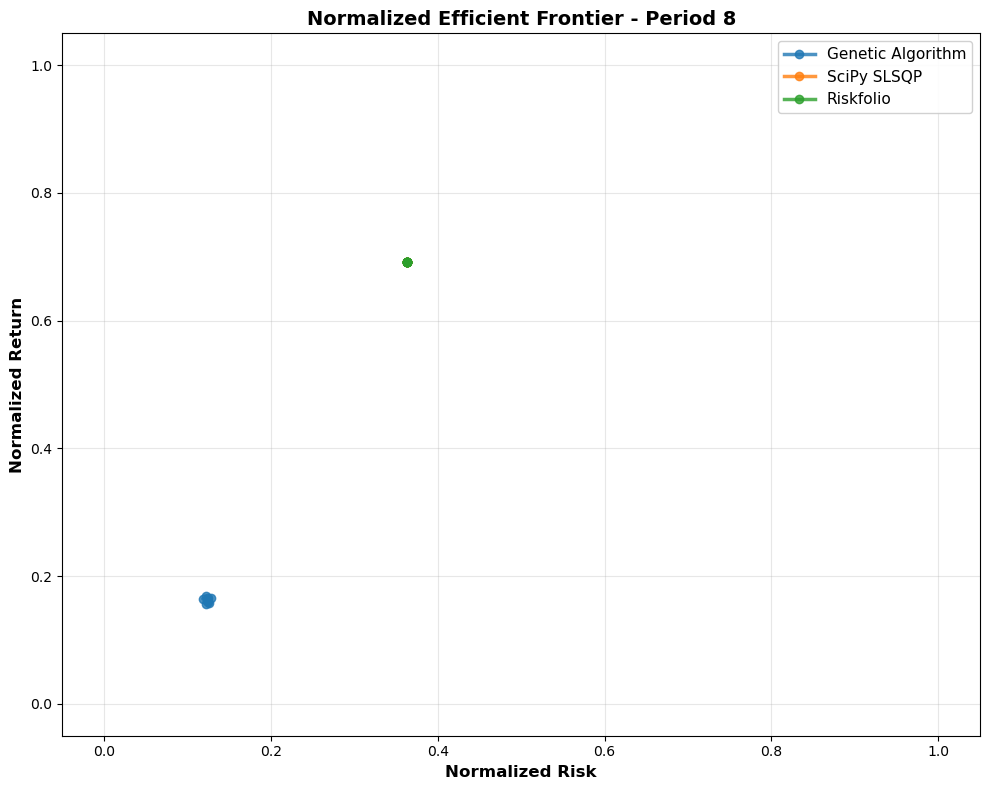

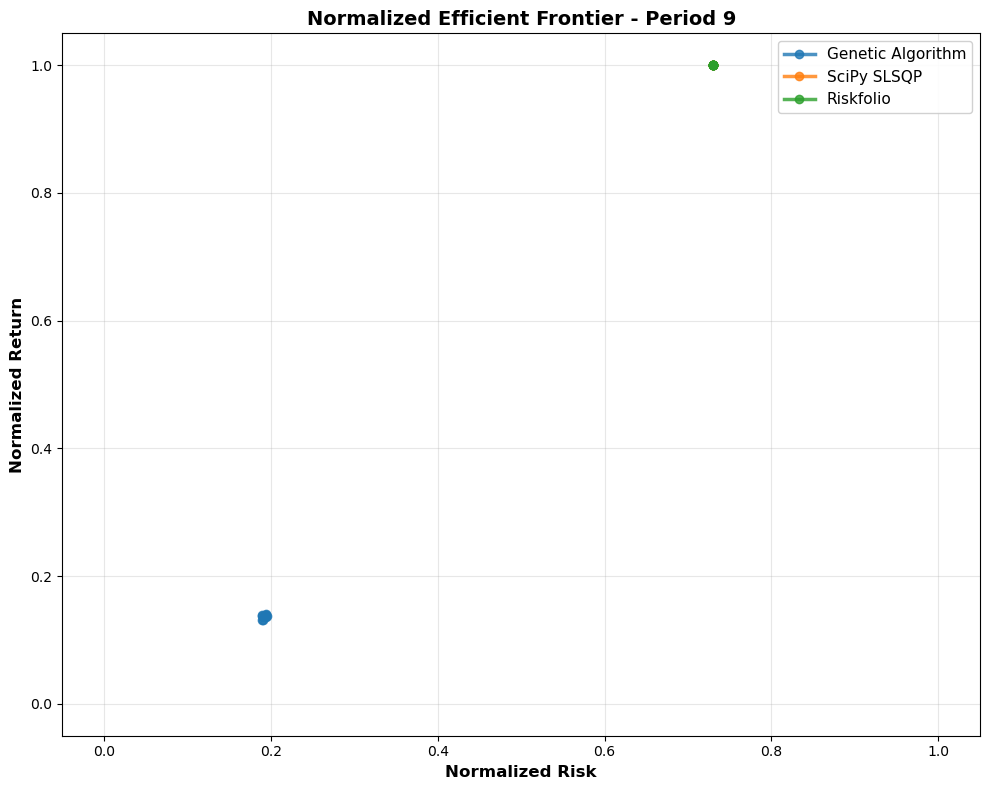


NORMALIZED FRONTIER SHAPE ANALYSIS
Generated 10 individual plots showing normalized efficient frontiers.
All periods are normalized using the SAME global min/max values across all periods,
allowing direct comparison of frontier shapes and positions across different time periods.
The normalized frontiers show the shape of the efficient frontier for each solver,
independent of the absolute return and risk values.
Note: Lambda values 0.0 and 1.0 are excluded from the plots.

Note: D-Wave CQM results are included only for Period 0.


In [21]:
# Compute normalized efficient frontiers for shape comparison
def compute_normalized_frontiers_with_dwave(all_periods_results, include_dwave_period=0, exclude_lambda=[0.0, 1.0]):
    """
    Compute normalized efficient frontiers for all solvers across all periods.
    Normalize ALL returns and risks using global min/max across ALL periods to enable comparison.
    Includes D-Wave results for specified period only.
    
    Args:
        all_periods_results: Dictionary of all results
        include_dwave_period: Period index to include D-Wave results (default 0)
        exclude_lambda: List of lambda values to exclude from plots (default [0.0, 1.0])
    
    Returns:
        Dictionary with normalized frontier data per solver per period
    """
    # Determine periods to process
    first_solver = [k for k in all_periods_results.keys() if k != 'dwave_cqm'][0]
    n_periods = len(all_periods_results[first_solver])
    
    # FIRST PASS: Collect ALL returns and risks across ALL periods and ALL solvers to find global min/max
    global_returns = []
    global_risks = []
    
    for period_idx in range(n_periods):
        # Determine which solvers to include for this period
        if period_idx == include_dwave_period and 'dwave_cqm' in all_periods_results:
            solver_names = list(all_periods_results.keys())
        else:
            solver_names = [k for k in all_periods_results.keys() if k != 'dwave_cqm']
        
        for solver_name in solver_names:
            if period_idx in all_periods_results[solver_name]:
                period_results = all_periods_results[solver_name][period_idx]
                for risk_level, result in period_results.items():
                    # Skip excluded lambda values
                    if risk_level in exclude_lambda:
                        continue
                    if result is not None and 'portfolio_return' in result:
                        global_returns.append(result['portfolio_return'])
                        global_risks.append(result['portfolio_risk'])
    
    if not global_returns:
        return {}
    
    # Find GLOBAL min/max for normalization across ALL periods
    global_min_return = min(global_returns)
    global_max_return = max(global_returns)
    global_min_risk = min(global_risks)
    global_max_risk = max(global_risks)
    
    print(f"\nGlobal normalization ranges:")
    print(f"  Returns: [{global_min_return:.6f}, {global_max_return:.6f}]")
    print(f"  Risks: [{global_min_risk:.6f}, {global_max_risk:.6f}]")
    
    # SECOND PASS: Normalize each solver's frontier for each period using GLOBAL min/max
    normalized_frontiers = {}
    
    for period_idx in range(n_periods):
        # Determine which solvers to include for this period
        if period_idx == include_dwave_period and 'dwave_cqm' in all_periods_results:
            solver_names = list(all_periods_results.keys())
        else:
            solver_names = [k for k in all_periods_results.keys() if k != 'dwave_cqm']
        
        for solver_name in solver_names:
            if solver_name not in normalized_frontiers:
                normalized_frontiers[solver_name] = {}
                
            if period_idx in all_periods_results[solver_name]:
                period_results = all_periods_results[solver_name][period_idx]
                
                normalized_returns = []
                normalized_risks = []
                
                for risk_level in sorted(period_results.keys()):
                    # Skip excluded lambda values
                    if risk_level in exclude_lambda:
                        continue
                        
                    result = period_results[risk_level]
                    if result is not None and 'portfolio_return' in result:
                        # Normalize to [0, 1] using GLOBAL min/max
                        norm_return = (result['portfolio_return'] - global_min_return) / (global_max_return - global_min_return) if global_max_return > global_min_return else 0
                        norm_risk = (result['portfolio_risk'] - global_min_risk) / (global_max_risk - global_min_risk) if global_max_risk > global_min_risk else 0
                        
                        normalized_returns.append(norm_return)
                        normalized_risks.append(norm_risk)
                
                if normalized_returns:  # Only add if we have data
                    normalized_frontiers[solver_name][period_idx] = {
                        'returns': normalized_returns,
                        'risks': normalized_risks
                    }
    
    return normalized_frontiers

# Compute normalized frontiers (excluding lambda = 0.0 and 1.0)
normalized_frontiers = compute_normalized_frontiers_with_dwave(all_periods_results_wide, include_dwave_period=0, exclude_lambda=[0.0, 1.0])

# Define colors and labels
colors_map = {
    'genetic_algorithm': '#1f77b4', 
    'scipy_slsqp': '#ff7f0e', 
    'riskfolio': '#2ca02c',
    'dwave_cqm': '#d62728'
}
labels_map = {
    'genetic_algorithm': 'Genetic Algorithm', 
    'scipy_slsqp': 'SciPy SLSQP', 
    'riskfolio': 'Riskfolio',
    'dwave_cqm': 'D-Wave CQM'
}

# Get number of periods
first_solver = [k for k in all_periods_results_wide.keys() if k != 'dwave_cqm'][0]
n_periods = len(all_periods_results_wide[first_solver])

# Create one figure per period
for period_idx in range(n_periods):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Get solvers for this period
    if period_idx == 0 and 'dwave_cqm' in normalized_frontiers:
        solver_names = [s for s in normalized_frontiers.keys() if period_idx in normalized_frontiers[s]]
    else:
        solver_names = [s for s in normalized_frontiers.keys() if s != 'dwave_cqm' and period_idx in normalized_frontiers[s]]
    
    # Plot each solver
    for solver_name in solver_names:
        if period_idx in normalized_frontiers[solver_name]:
            data = normalized_frontiers[solver_name][period_idx]
            ax.plot(data['risks'], data['returns'], 
                   marker='o', linewidth=2.5, markersize=6,
                   label=labels_map.get(solver_name, solver_name),
                   color=colors_map.get(solver_name, '#666666'),
                   alpha=0.8)
    
    ax.set_xlabel('Normalized Risk', fontsize=12, fontweight='bold')
    ax.set_ylabel('Normalized Return', fontsize=12, fontweight='bold')
    
    title = f'Normalized Efficient Frontier - Period {period_idx}'
    if period_idx == 0 and 'dwave_cqm' in solver_names:
        title += ' (with D-Wave CQM)'
    ax.set_title(title, fontsize=14, fontweight='bold')
    
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.05, 1.05])
    ax.set_ylim([-0.05, 1.05])
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("NORMALIZED FRONTIER SHAPE ANALYSIS")
print("="*80)
print(f"Generated {n_periods} individual plots showing normalized efficient frontiers.")
print("All periods are normalized using the SAME global min/max values across all periods,")
print("allowing direct comparison of frontier shapes and positions across different time periods.")
print("The normalized frontiers show the shape of the efficient frontier for each solver,")
print("independent of the absolute return and risk values.")
print("Note: Lambda values 0.0 and 1.0 are excluded from the plots.")
if 'dwave_cqm' in all_periods_results_wide and 0 in all_periods_results_wide['dwave_cqm']:
    print("\nNote: D-Wave CQM results are included only for Period 0.")
print("="*80)

### SciPy SLSQP vs Riskfolio Comparison

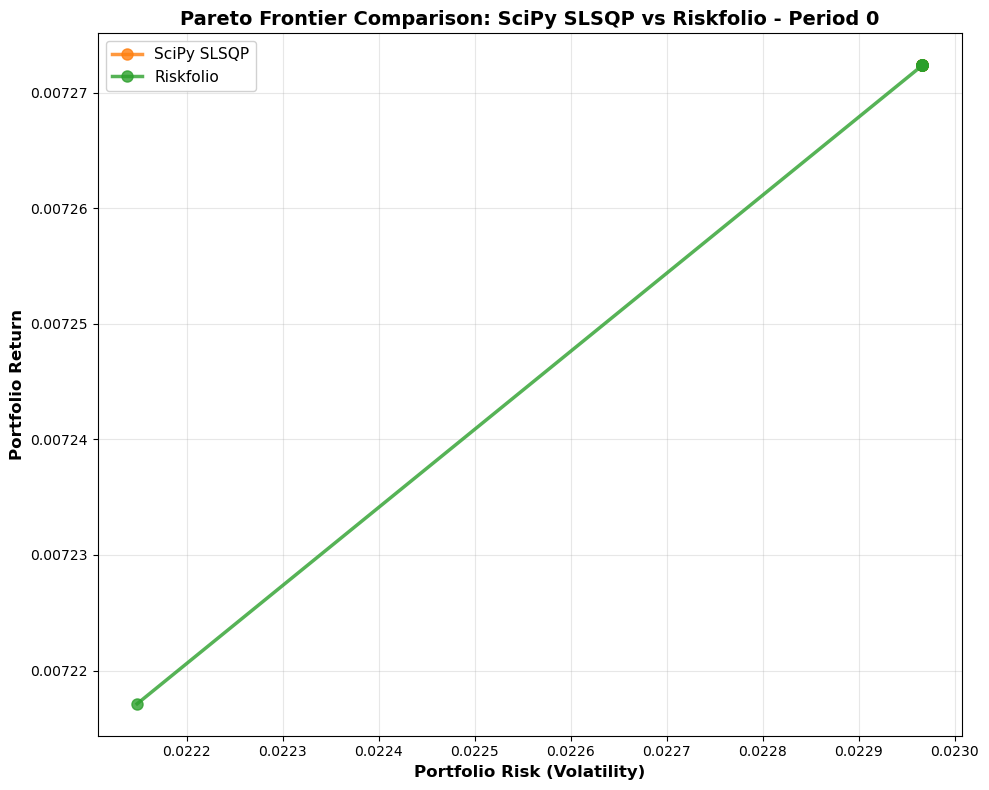

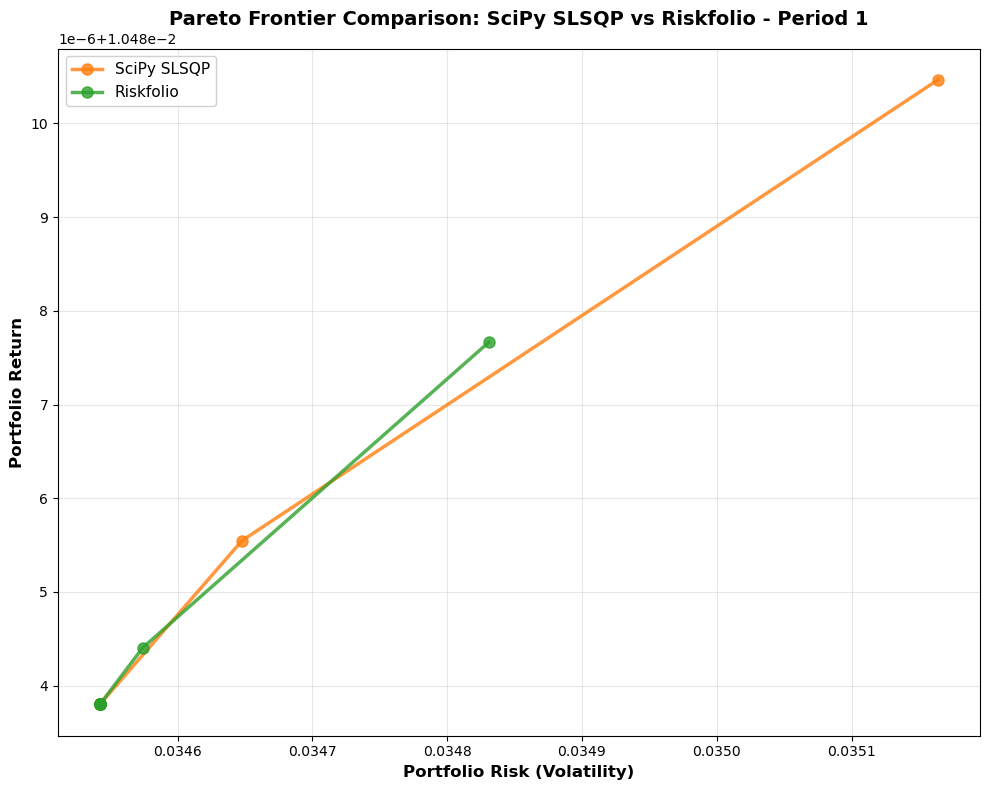

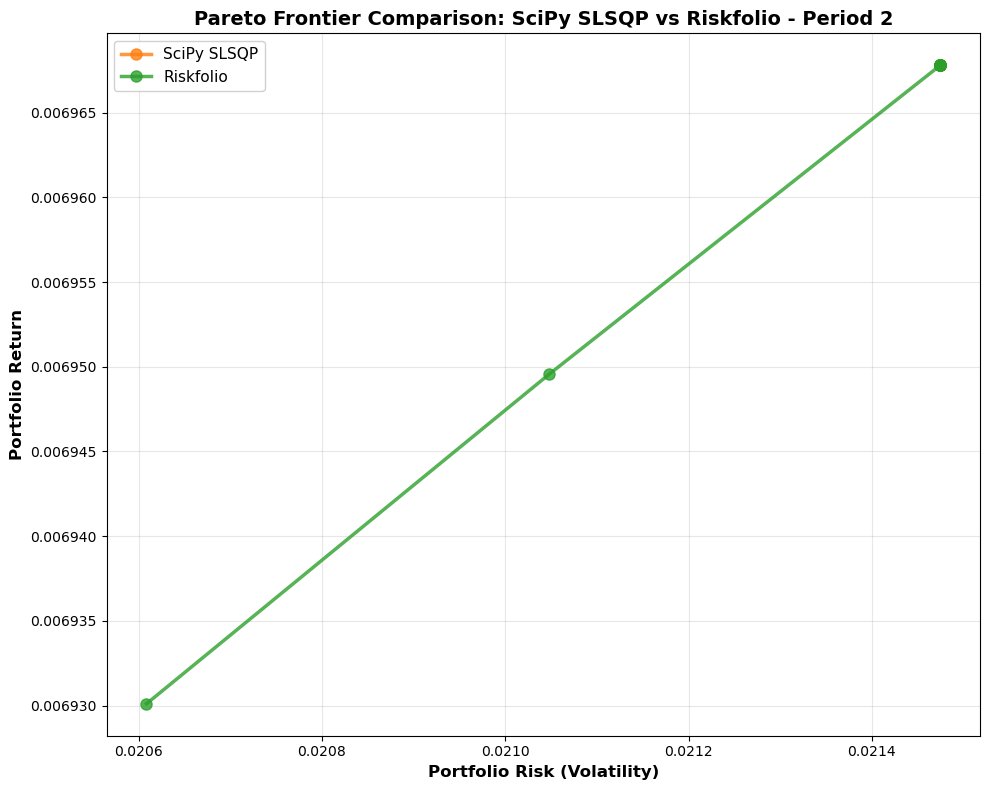

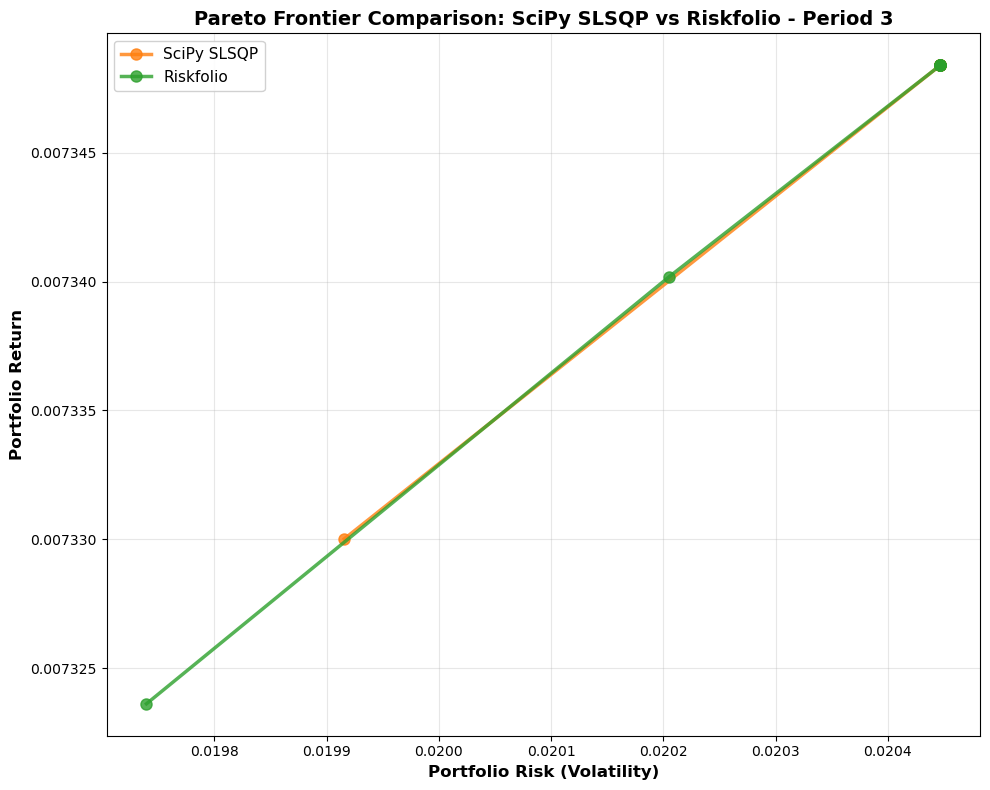

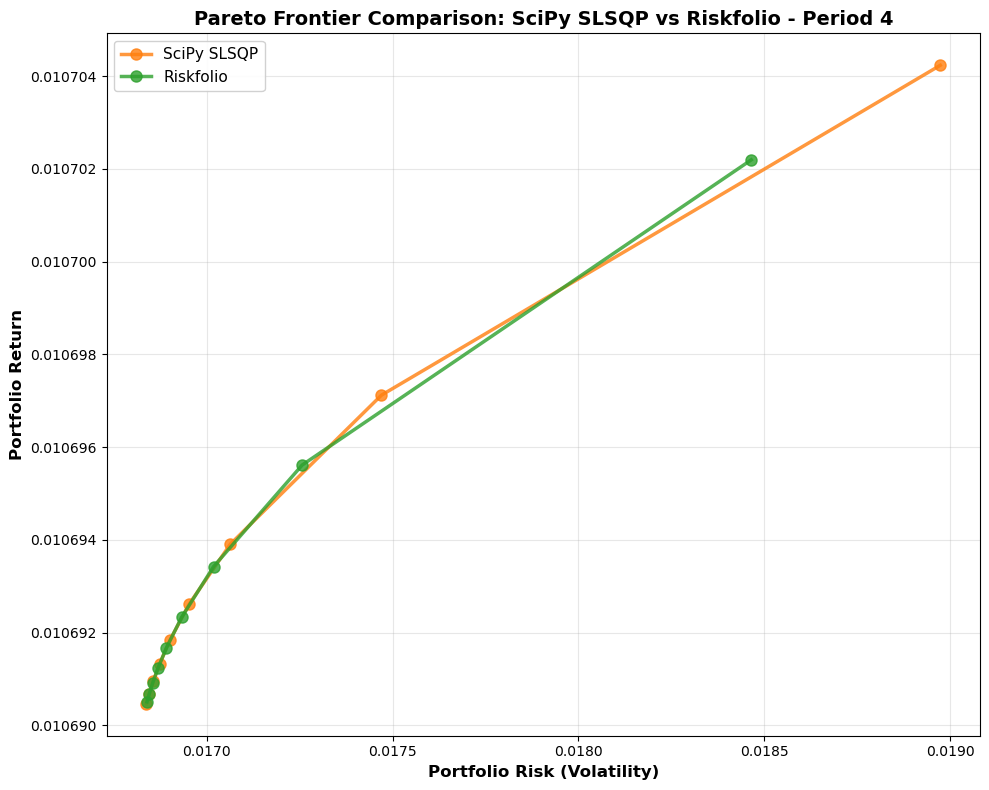

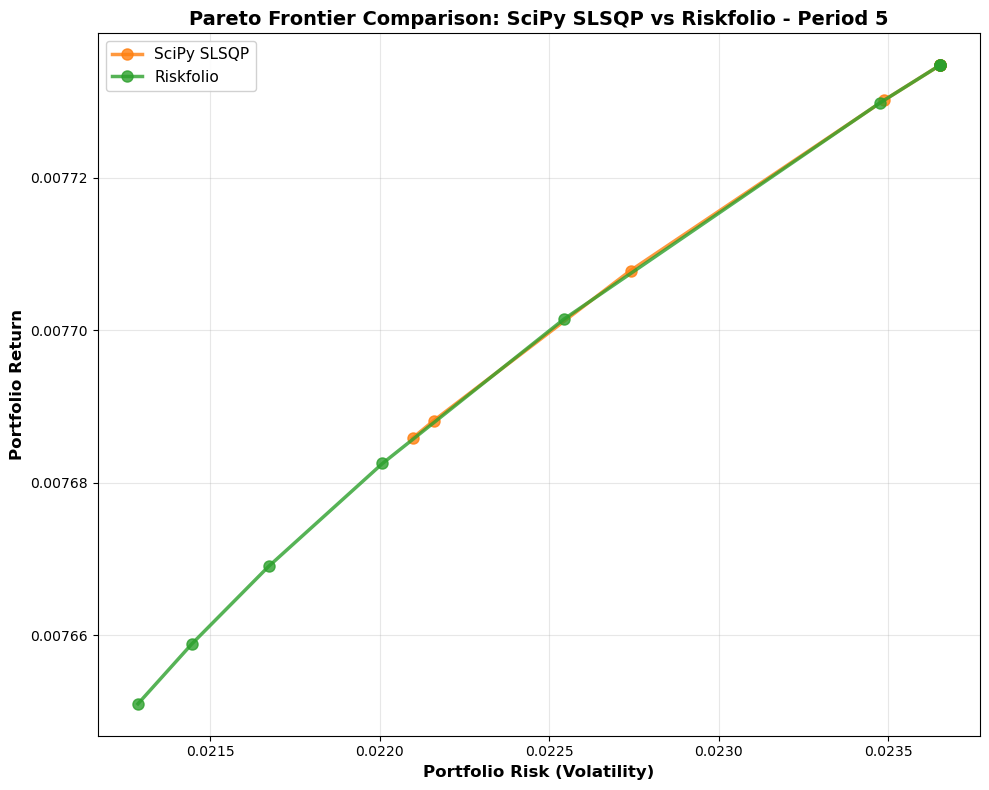

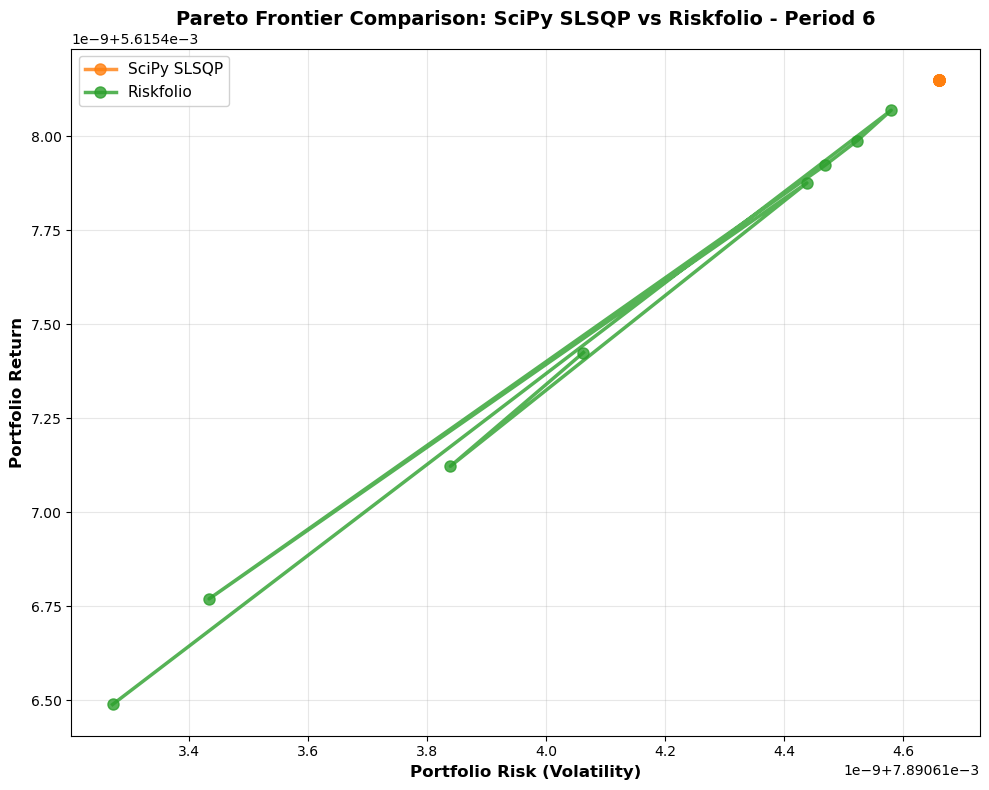

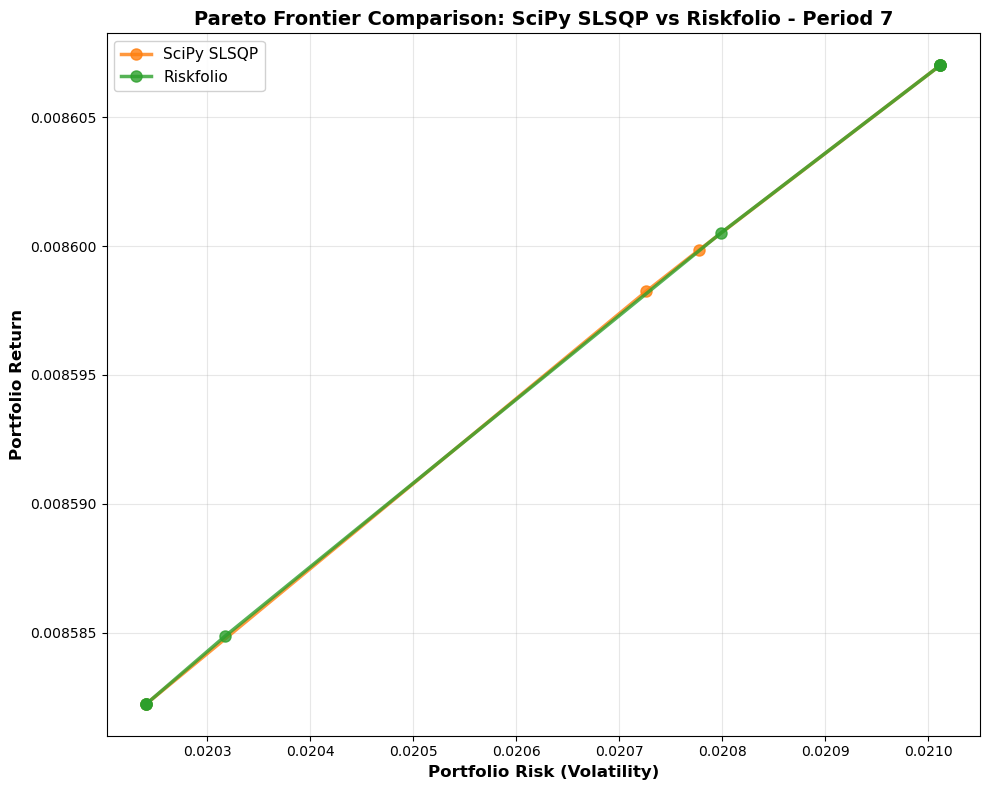

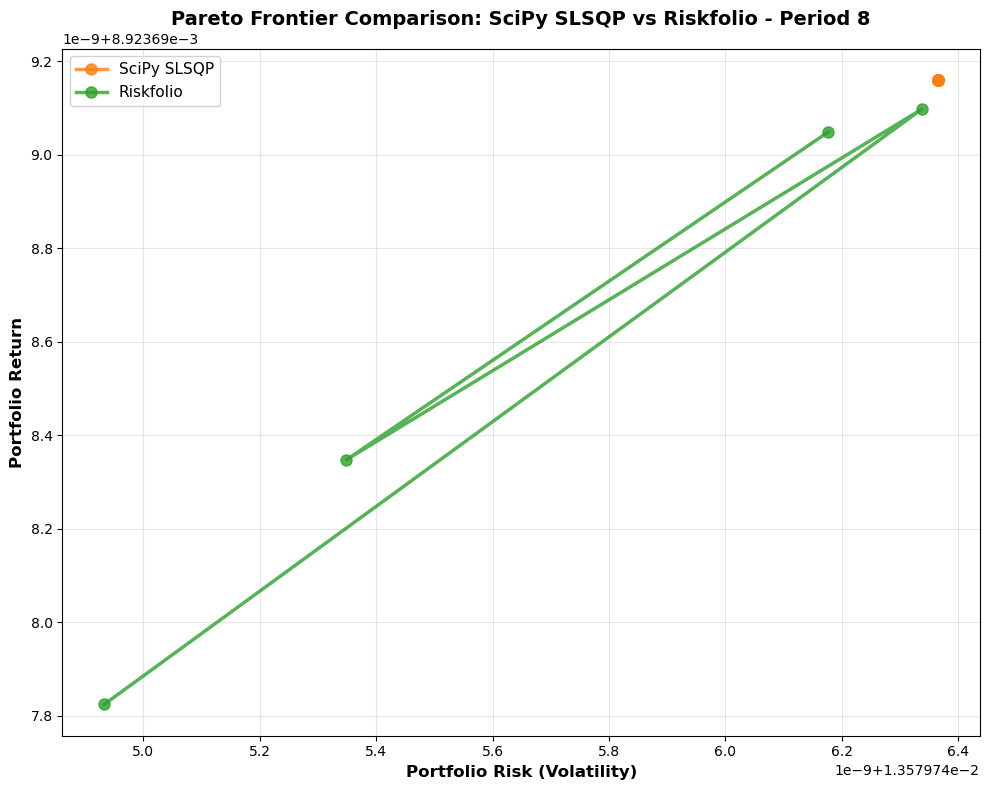

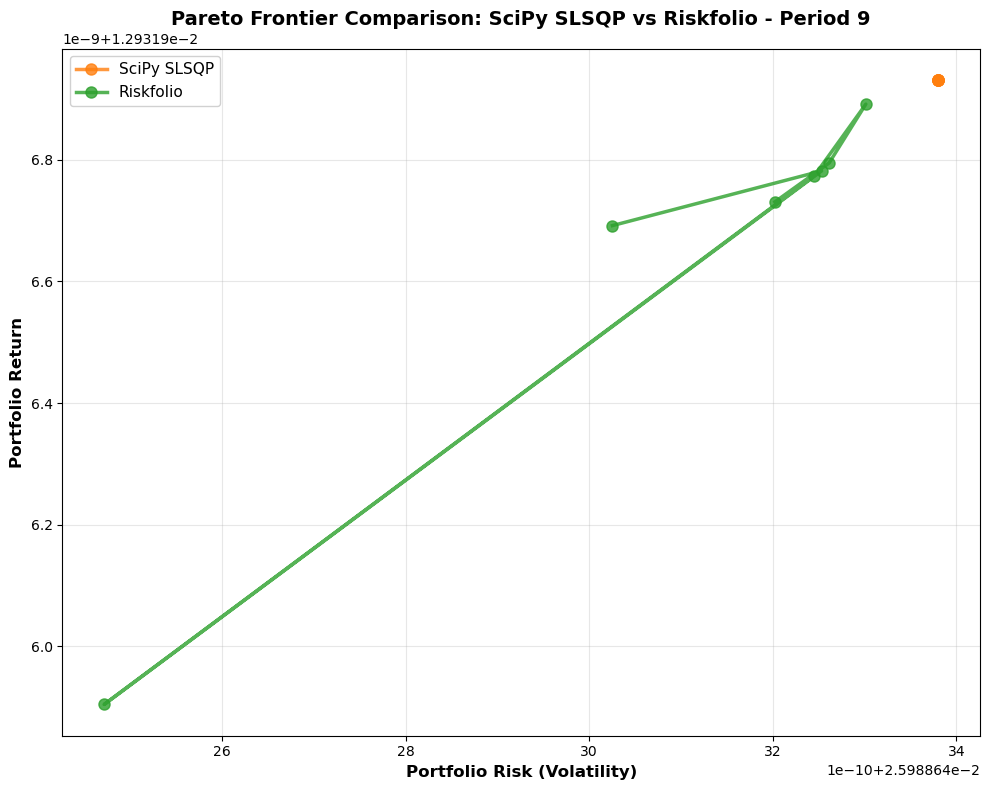


SCIPY SLSQP vs RISKFOLIO PARETO FRONTIER COMPARISON
Generated 10 individual plots comparing SciPy SLSQP and Riskfolio.
These plots show only Pareto-optimal points (non-dominated solutions).
Lambda values 0.0 and 1.0 are excluded from the comparison.


In [22]:
# Compare only SciPy SLSQP and Riskfolio efficient frontiers for all periods
# Show only Pareto-optimal points (not all lambda values)

# Define colors and labels for these two solvers
colors_map_comparison = {
    'scipy_slsqp': '#ff7f0e', 
    'riskfolio': '#2ca02c'
}
labels_map_comparison = {
    'scipy_slsqp': 'SciPy SLSQP', 
    'riskfolio': 'Riskfolio'
}

# Get number of periods
n_periods = parameters['n_periods']

# Create one figure per period comparing only SLSQP and Riskfolio
for period_idx in range(n_periods):
    fig, ax = plt.subplots(1, 1, figsize=(10, 8))
    
    # Plot only SciPy SLSQP and Riskfolio - PARETO POINTS ONLY
    for solver_name in ['scipy_slsqp', 'riskfolio']:
        if period_idx in all_periods_results_wide[solver_name]:
            period_results = all_periods_results_wide[solver_name][period_idx]
            
            # Filter out lambda = 0.0 and 1.0
            filtered_results = {
                k: v for k, v in period_results.items() 
                if k not in [0.0, 1.0] and v is not None and 'portfolio_return' in v
            }
            
            # Extract Pareto frontier points only
            pareto_points = extract_pareto_frontier(filtered_results)
            
            if pareto_points:
                returns = [p['portfolio_return'] for p in pareto_points.values()]
                risks = [p['portfolio_risk'] for p in pareto_points.values()]
                
                ax.plot(risks, returns, 
                       marker='o', linewidth=2.5, markersize=8,
                       label=labels_map_comparison[solver_name],
                       color=colors_map_comparison[solver_name],
                       alpha=0.8)
    
    ax.set_xlabel('Portfolio Risk (Volatility)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Portfolio Return', fontsize=12, fontweight='bold')
    ax.set_title(f'Pareto Frontier Comparison: SciPy SLSQP vs Riskfolio - Period {period_idx}', 
                fontsize=14, fontweight='bold')
    
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=11, framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

print("\n" + "="*80)
print("SCIPY SLSQP vs RISKFOLIO PARETO FRONTIER COMPARISON")
print("="*80)
print(f"Generated {n_periods} individual plots comparing SciPy SLSQP and Riskfolio.")
print("These plots show only Pareto-optimal points (non-dominated solutions).")
print("Lambda values 0.0 and 1.0 are excluded from the comparison.")
print("="*80)